In [47]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import operator
import pathlib

import math
import numpy as np
import matplotlib.colors
import matplotlib.patches
import matplotlib.lines as mlines


plt.style.use('default')
sns.set_palette("husl")

%matplotlib inline

- [x] Charts are too small,
    esp llama2-clip-erasure-unrealted-cs, llama2-clip-erasure-unrealted-bertp

- [x] From remove tokens from the code and upload
- [x] Check openreview account


In [140]:
def translate(cmap, x_min=0.0):
    return lambda x: cmap((x + x_min) / (1 + x_min))

In [171]:
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdPu, norm=plt.Normalize(vmin=0, vmax=10, clip=True))

In [266]:
def calculate_pareto_frontier(points, x_better="lower", y_better="lower"):
    """
    Compute the Pareto frontier assuming x increases left -> right.

    y_better = "lower": keep strictly lower y values as x increases (x_better='lower') or increases (x_better='higher').
    y_better = "higher": keep strictly higher y values as x increases (x_better='lower') or increases (x_better='higher').
    """
    if not points:
        return []

    if y_better not in ("lower", "higher"):
        raise ValueError("y_better must be 'lower' or 'higher'")

    sort_key=(lambda p: p[0]) if x_better == "lower" else (lambda p: -p[0])
    sorted_points = sorted(points, key=sort_key)

    pareto_frontier = []
    best_y = float("inf") if y_better == "lower" else float("-inf")
    op = operator.lt if y_better == "lower" else operator.gt
    
    for x, y in sorted_points:
        if op(y, best_y):
            pareto_frontier.append((x, y))
            best_y = y

    return pareto_frontier


# Define colors and markers for each method
METHOD_STYLES = {
    'casteer': {
        'marker_edge_color': 'red',
        'marker': 'o',
        'legend_label': 'Vanilla steering'
    },
    'leace': {
        'marker_edge_color': 'blue',
        'marker': '^',
        'legend_label': 'LEACE'
    },
    'midsteer': {
        'marker_edge_color': 'green',
        'marker': 'D',
        'legend_label': 'MiDSteer'
    },
    'mean_matching': {
        'marker_edge_color': 'green',
        'marker': 'D',
        'legend_label': 'MiDSteer'
    }
}


def plot_pareto_frontier(
    data: pd.DataFrame,
    x_column: str,
    y_column: str,

    y_better="lower",
    x_better="lower",
    x_label: str | None = None,
    y_label: str | None = None,
    title: str | None = None,

    output_fname: str = None,
    y_goal: float = None,
    figsize=(12, 8),
    erase_mode: bool = False,
):
    data = data.query("strength in [1.0, 2.0, 3.0, 4.0, 5.0]")
    cmap = plt.cm.RdPu
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=data.strength.max()))
    sm.set_array([])
    if x_label is None:
        x_label = x_column

    if y_label is None:
        y_label = y_column


    plt.figure(figsize=figsize)

    legend_handles = {}
    min_x = float('inf')
    for _, row in data.iterrows():
        style = METHOD_STYLES[row.method_name]
        legend_label = style['legend_label']
        if erase_mode and legend_label == 'LEACE':
            legend_label = 'LEACE / MiDSteer'
    
        # strength_norm = (row.strength - data.strength.min()) / (data.strength.max() - data.strength.min())
        color = sm.to_rgba(row.strength)
    
        min_x = min(min_x, row[x_column])
        plt.scatter(
            row[x_column],
            row[y_column],
            marker=style['marker'],
            s=100,
            alpha=1.0,
            facecolors=color,
            # edgecolors=style['marker_edge_color'],
            linewidth=1.5,
        )

        if row.method_name not in legend_handles:
            legend_handles[row.method_name] = mlines.Line2D(
                xdata=[], ydata=[],
                markerfacecolor='white',
                markeredgecolor='black',#style['marker_edge_color'],
                marker=style['marker'],
                linestyle='None',
                label=legend_label,
            )
        
                
        # Add beta value annotations
        plt.annotate(
            f'β={row.strength:.1f}',
            (row[x_column], row[y_column]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            alpha=0.8
        )
    
    
    pareto_points = calculate_pareto_frontier(
        [(row[x_column], row[y_column]) for _, row in data.iterrows()],
        x_better=x_better,
        y_better=y_better,
    )
    
    pareto_x, pareto_y = zip(*pareto_points)
    legend_handles['pareto'], = plt.plot(pareto_x, pareto_y, 'k--', linewidth=2, alpha=0.8, label='Pareto Frontier', zorder=-1)

    if y_goal is not None:
        legend_handles['goal_line'] = plt.axhline(
            y=y_goal, color='black', linewidth=1.5, linestyle=(0, (1, 3)),
            label='Goal line'
        )
        plt.annotate(
            f'y = {y_goal:.1f}',
            (min_x, y_goal),
            xytext=(10, -15),
            textcoords='offset points',
            fontsize=11,
            color='black'
        )

    
    # plt.scatter(pareto_x, pareto_y, s=200, marker='x', 
              # c='black', linewidth=3, alpha=0.8)
    
    if title is not None:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(f'{x_label} ({x_better} is better)', fontsize=12)
    plt.ylabel(f'{y_label} ({y_better} is better)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(handles=legend_handles.values()
    #    loc='upper right'
    )
    
    
    
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('Beta (β)', fontsize=12)
    
    plt.tight_layout()

    if output_fname is not None:
        os.makedirs(os.path.dirname(output_fname), exist_ok=True)
        plt.savefig(fname=output_fname)

In [267]:
def get_strength_or_none(lst):
    return float(lst[1]) if 0 <= 1 < len(lst) else None

def split_last(s: str, delim: str):
    parts = s.split(delim)
    first = delim.join(parts[:-1])
    last = parts[-1]
    return first, last

def split_first(s: str, delim: str):
    parts = s.split(delim)
    first = parts[0]
    last = delim.join(parts[1:])
    return first, last

def parse_llm_erase_experiment(path: str):
    path = pathlib.Path(path)
    consistency_scores = []
    concept_scores = []
    for subdir in os.listdir(path):
        if subdir == '.DS_Store':
            continue
        if os.path.exists(path / subdir / 'alpaca'):
            if os.path.exists(path / subdir / 'alpaca' / 'scores.tsv'):
                df = pd.read_csv(path / subdir / 'alpaca' / 'scores.tsv', sep="\t")
            else:
                df = pd.read_csv(path / subdir / 'alpaca' / 'consistency_scores.tsv', sep="\t")
            df['remove_concept'] = subdir
            df['test_concept'] = None
            df['dataset'] = 'alpaca'
            consistency_scores.append(df)
        if os.path.exists(path / subdir / 'mmlu'):
            if os.path.exists(path / subdir / 'mmlu' / 'scores.tsv'):
                df = pd.read_csv(path / subdir / 'mmlu' / 'scores.tsv', sep="\t")
            else:
                df = pd.read_csv(path / subdir / 'mmlu' / 'consistency_scores.tsv', sep="\t")
            df['remove_concept'] = subdir
            df['test_concept'] = None
            df['dataset'] = 'mmlu'
            consistency_scores.append(df)
        if os.path.exists(path / subdir / 'eval'):
            if os.path.exists(path / subdir / 'eval' / 'scores.tsv'):
                df = pd.read_csv(path / subdir / 'eval' / 'scores.tsv', sep="\t")
            else:
                df = pd.read_csv(path / subdir / 'eval' / 'concept_scores.tsv', sep="\t")
            remove_concept, test_concept = split_first(subdir, '_')
            df['remove_concept'] = remove_concept
            df['test_concept'] = test_concept
            concept_scores.append(df)


            if os.path.exists(path / subdir / 'eval' / 'consistency_scores.tsv'):
                df = pd.read_csv(path / subdir / 'eval' / 'consistency_scores.tsv', sep="\t")
                df['remove_concept'] = remove_concept
                df['test_concept'] = test_concept
                df['dataset'] = 'eval'
                consistency_scores.append(df)
            
    consistency_scores = pd.concat(consistency_scores, axis=0)
    concept_scores = pd.concat(concept_scores, axis=0)

    
    consistency_scores['method_name'] = consistency_scores.apply(lambda x: split_last(x.file[:-5], '_')[0], axis=1)
    consistency_scores['strength'] = consistency_scores.apply(lambda x: float(split_last(x.file[:-5], '_')[1]), axis=1)
    consistency_scores = consistency_scores.drop(['file'], axis=1)

    
    concept_scores['method_name'] = concept_scores.apply(lambda x: split_last(x.file[:-5], '_')[0], axis=1)
    concept_scores['strength'] = concept_scores.apply(lambda x: float(split_last(x.file[:-5], '_')[1]), axis=1)
    concept_scores = concept_scores.drop(['file'], axis=1)

    concept_scores.loc[concept_scores['method_name'] == 'None', 'strength'] = None
    concept_scores.loc[concept_scores['method_name'] == 'None', 'method_name'] = 'orig'
    
    return consistency_scores, concept_scores


def parse_llm_flip_experiment(path: str):
    path = pathlib.Path(path)
    consistency_scores = []
    concept_scores = []
    for subdir in os.listdir(path):
        if subdir == '.DS_Store':
            continue
        if os.path.exists(path / subdir / 'alpaca'):
            if os.path.exists(path / subdir / 'alpaca' / 'scores.tsv'):
                df = pd.read_csv(path / subdir / 'alpaca' / 'scores.tsv', sep="\t")
            else:
                df = pd.read_csv(path / subdir / 'alpaca' / 'consistency_scores.tsv', sep="\t")
            source_concept, target_concept = split_first(subdir, '_to_')
            df['source_concept'] = source_concept
            df['target_concept'] = target_concept
            df['test_concept'] = None
            df['dataset'] = 'alpaca'
            consistency_scores.append(df)
        if os.path.exists(path / subdir / 'mmlu'):
            if os.path.exists(path / subdir / 'mmlu' / 'scores.tsv'):
                df = pd.read_csv(path / subdir / 'mmlu' / 'scores.tsv', sep="\t")
            else:
                df = pd.read_csv(path / subdir / 'mmlu' / 'consistency_scores.tsv', sep="\t")
            source_concept, target_concept = split_first(subdir, '_to_')
            df['source_concept'] = source_concept
            df['target_concept'] = target_concept
            df['test_concept'] = None
            df['dataset'] = 'mmlu'
            consistency_scores.append(df)
        if os.path.exists(path / subdir / 'eval'):
            if os.path.exists(path / subdir / 'eval' / 'scores.tsv'):
                df = pd.read_csv(path / subdir / 'eval' / 'scores.tsv', sep="\t")
            else:
                df = pd.read_csv(path / subdir / 'eval' / 'concept_scores.tsv', sep="\t")
            if '__' in subdir:
                # New version of the directory names
                other, test_concept = split_last(subdir, '__')
                source_concept, target_concept = split_first(other, '_to_')
            else:
                source_concept, target_concept = split_first(subdir, '_to_')
                test_concept = source_concept
            df['source_concept'] = source_concept
            df['target_concept'] = target_concept
            df['test_concept'] = test_concept
            concept_scores.append(df)

            
            if os.path.exists(path / subdir / 'eval' / 'consistency_scores.tsv'):
                df = pd.read_csv(path / subdir / 'eval' / 'consistency_scores.tsv', sep="\t")
                df['source_concept'] = source_concept
                df['target_concept'] = target_concept
                df['test_concept'] = test_concept
                df['dataset'] = 'eval'
                consistency_scores.append(df)
                
    consistency_scores = pd.concat(consistency_scores, axis=0)
    concept_scores = pd.concat(concept_scores, axis=0)

    
    consistency_scores['method_name'] = consistency_scores.apply(lambda x: split_last(x.file[:-5], '_')[0], axis=1)
    consistency_scores['strength'] = consistency_scores.apply(lambda x: float(split_last(x.file[:-5], '_')[1]), axis=1)
    consistency_scores = consistency_scores.drop(['file'], axis=1)

    
    concept_scores['method_name'] = concept_scores.apply(lambda x: split_last(x.file[:-5], '_')[0], axis=1)
    concept_scores['strength'] = concept_scores.apply(lambda x: float(split_last(x.file[:-5], '_')[1]), axis=1)
    concept_scores = concept_scores.drop(['file'], axis=1)

    concept_scores.loc[concept_scores['method_name'] == 'None', 'strength'] = None
    concept_scores.loc[concept_scores['method_name'] == 'None', 'method_name'] = 'orig'
    
    return consistency_scores, concept_scores





In [268]:
IMPLICIT_CONCEPTS = [
    "domesticated_canine", "man_s_best_friend",
    "knight_s_riding_mammal", "large_equine",
    "Walt Disney's most famous character",
    "mouse from a Disneyland",
    "large equine",
    "knight's riding mammal",
]

AXES = {
    'one_minus_mmlu_bert_p': {
        'label': '1 - BERT Precision @ MMLU',
        'better': 'lower',
    },
    'one_minus_unrelated_bert_p': {
        'label': '1 - BERT Precision @ Unrelated concepts',
        'better': 'lower',
    },
    'erased_concept_score': {
        'label': 'Erased concept score',
        'better': 'lower',
    },
    'unrelated_concept_score': {
        'label': 'Unrelated concept score',
        'better': 'higher',
    },
    'delta_concept_score': {
        'label': 'Δ concept score',
        'better': 'higher',
    },
    'source_concept_score': {
        'label': 'Source concept score',
        'better': 'lower',
    },
    'target_concept_score': {
        'label': 'Target concept score',
        'better': 'higher',
    },
    'erased_concept_clip_score': {
        'label': 'Erased concept CS',
        'better': 'lower',
    },
    'unrelated_concept_fid': {
        'label': 'FID for unrelated concepts',
        'better': 'lower',
    },
    'unrelated_concept_clip_score': {
        'label': 'CS for unrelated concepts',
        'better': 'higher',
    },
    'delta_clip_score': {
        'label': 'Δ CS',
        'better': 'higher',
    },
    'source_clip_score': {
        'label': 'Source CS',
        'better': 'lower',
    },
    'target_clip_score': {
        'label': 'Target CS',
        'better': 'higher',
    },
    'unrelated_clip_score': {
        'label': 'Unrelated concept CS',
        'better': 'higher',
    }
}

# LLM exps

## LLM erasure

In [272]:
def produce_llm_erase_pareto_plot(
    experiment_name: str,
    x_axis: str,
    y_axis: str,
    output_filename: str | None = None,
    figsize=(12, 8)
):
    consistency_scores, concept_scores = parse_llm_erase_experiment(
        experiment_name
    )
    
    data = (
        (
            consistency_scores
            .query("dataset == 'mmlu'")
            .groupby(['method_name', 'strength'])
            .agg({'bert_precision': 'mean'})
            .assign(one_minus_mmlu_bert_p=lambda x: 1 - x.bert_precision)
        ).join(
            concept_scores
            .query("(concept == remove_concept) & (concept == test_concept)")
            .groupby(['method_name', 'strength'])
            .agg({'avg_score': 'mean'})
            .rename({'avg_score': 'erased_concept_score'}, axis=1)
        ).join(
            concept_scores
            .query("(test_concept != remove_concept) & (concept == test_concept)")
            .query("test_concept not in @IMPLICIT_CONCEPTS")
            .groupby(['method_name', 'strength'])
            .agg({'avg_score': 'mean'})
            .rename({'avg_score': 'unrelated_concept_score'}, axis=1)
        ).join(
            consistency_scores
            .query('dataset == "eval"')
            .query("test_concept != remove_concept")
            .query("test_concept not in @IMPLICIT_CONCEPTS")
            .groupby(['method_name', 'strength'])
            .agg({'bert_precision': 'mean'})
            .rename({'bert_precision': 'unrelated_bert_p'}, axis=1)
            .assign(one_minus_unrelated_bert_p=lambda x: 1 - x.unrelated_bert_p)
        )
        .query('method_name != "midsteer" & method_name != "mean_matching"')
        .reset_index()
    )
    
    plot_pareto_frontier(
        data=data,
        x_column=x_axis,
        y_column=y_axis,
    
        x_label=AXES[x_axis]['label'],
        y_label=AXES[y_axis]['label'],
        x_better=AXES[x_axis]['better'],
        y_better=AXES[y_axis]['better'],
        title='',
        output_fname=output_filename,
        y_goal=0,
        figsize=figsize,
        erase_mode=True,
    )

In [273]:
X_AXES_MAPPING_LLM = {
    'one_minus_mmlu_bert_p': 'mmlu-bertp',
    'unrelated_concept_score': 'unrelated-cs',
    'one_minus_unrelated_bert_p': 'unrelated-bertp',
}

def generate_erase_plots_with_different_axes(
    experiment_name: str,
    output_filename_template: str,
    x_axes_mapping: dict[str, str],
    figsize=(12, 8),
):
    for x_axis, name in x_axes_mapping.items():
        produce_llm_erase_pareto_plot(
            experiment_name=experiment_name,
            y_axis='erased_concept_score',
            x_axis=x_axis,
            output_filename=output_filename_template.format(name),
            figsize=figsize,
        )

### Qwen 14B

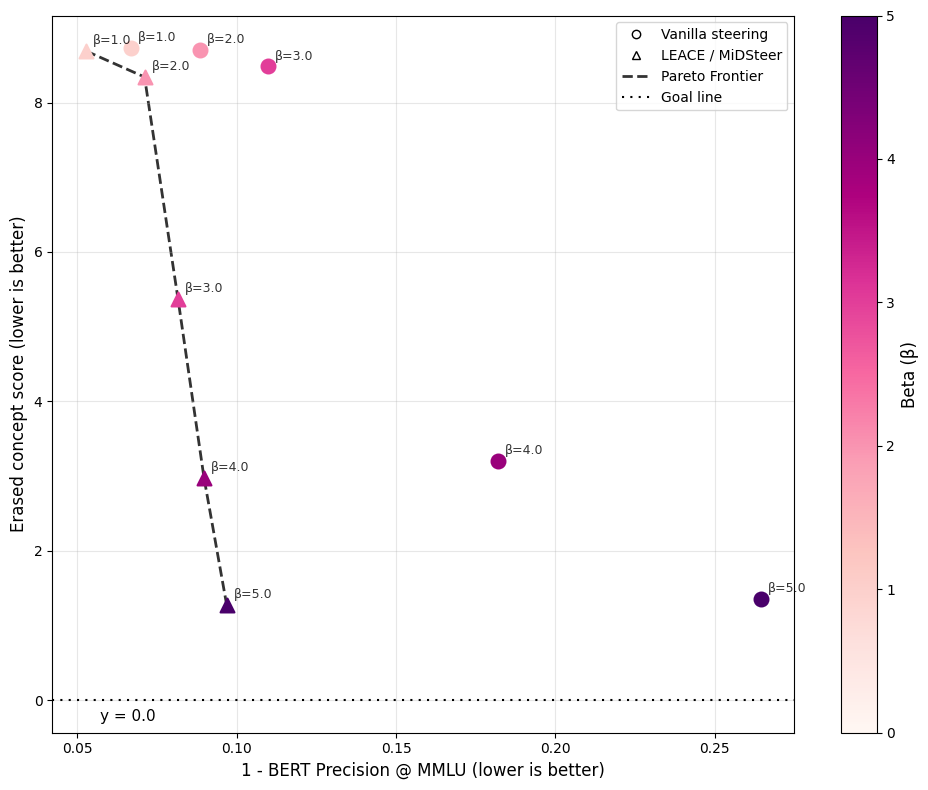

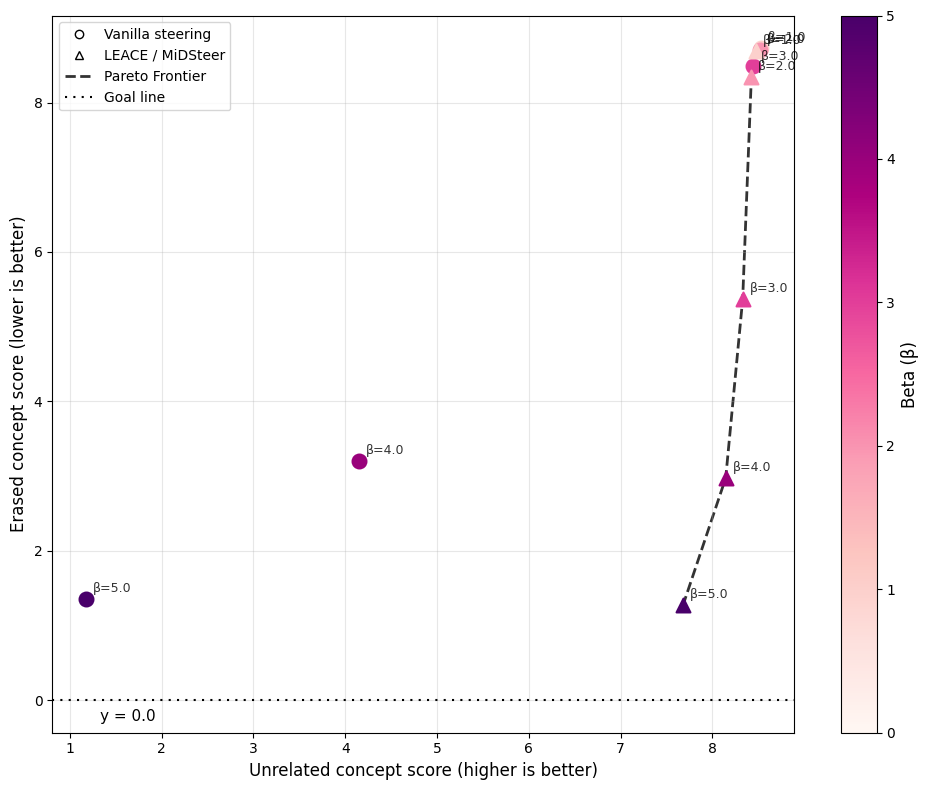

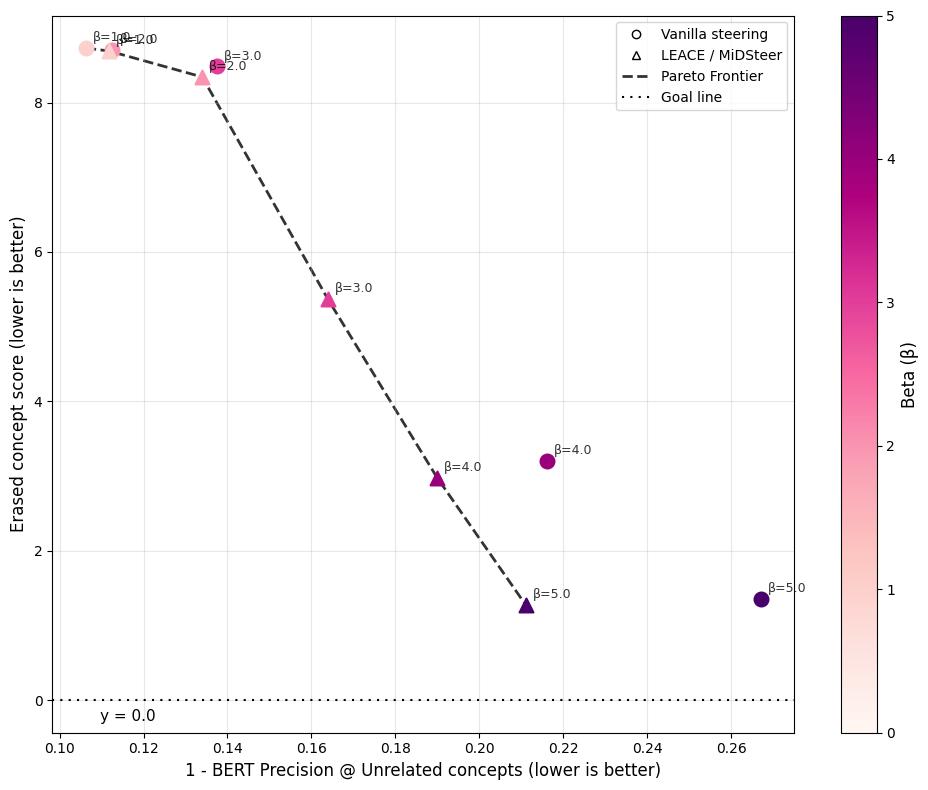

In [306]:
generate_erase_plots_with_different_axes(
    experiment_name='../exp/results/Qwen-Qwen2.5-14B-Instruct/erasure_qwen_14b_50k/evaluation/',
    output_filename_template='../artefacts/pareto/qwen-14b-erasure-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(10, 8),
)

### Qwen 7B

#### No clip

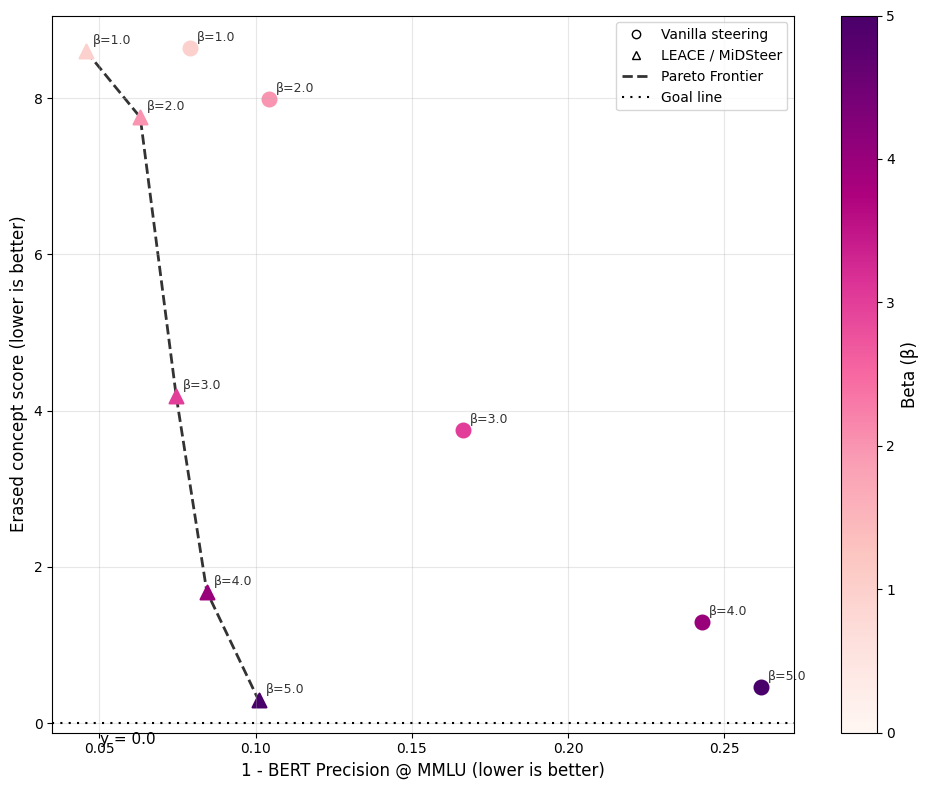

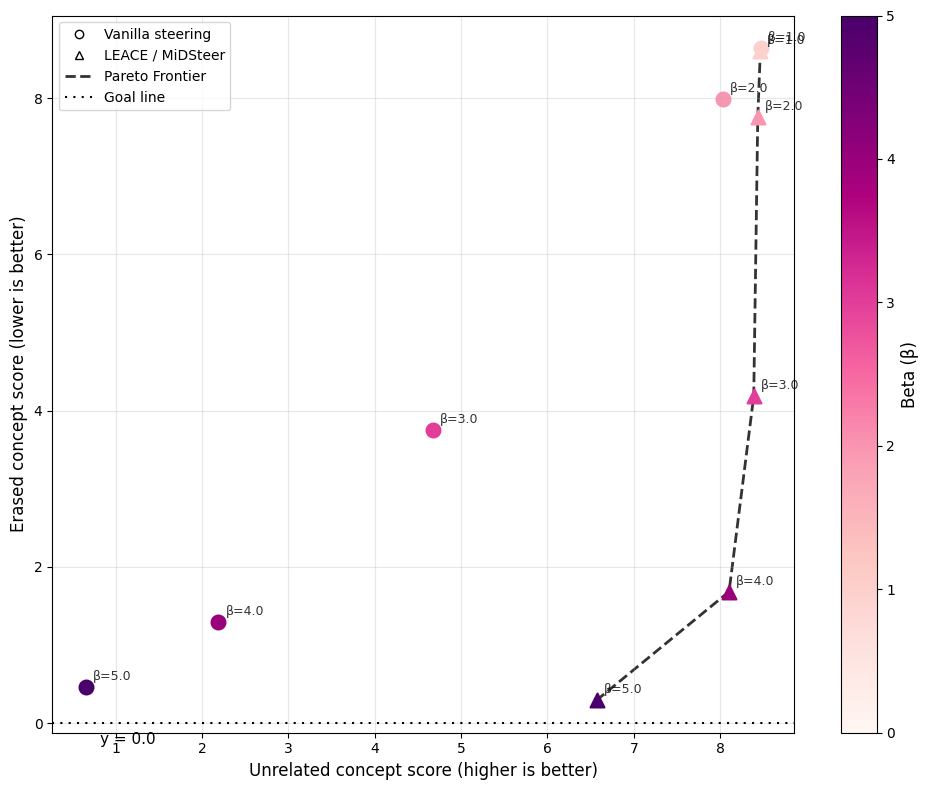

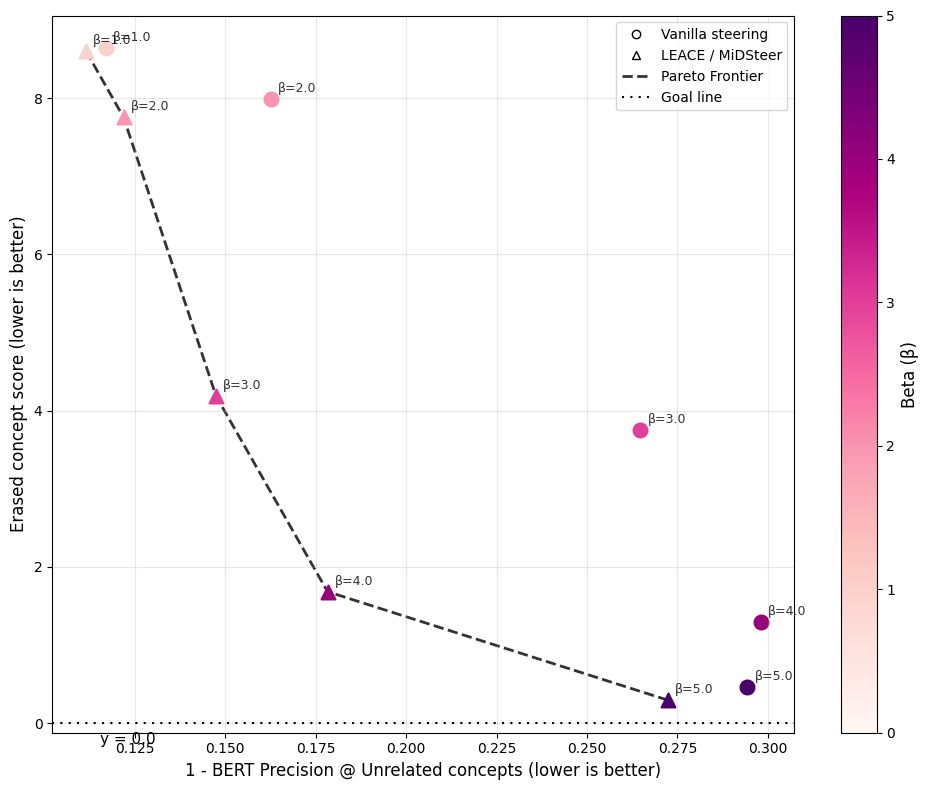

In [307]:
generate_erase_plots_with_different_axes(
    experiment_name='../exp/results/Qwen-Qwen2.5-7B-Instruct/erasure_qwen_7b_50k/evaluation/',
    output_filename_template='../artefacts/pareto/qwen-7b-erasure-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(10, 8),
)

#### Clip

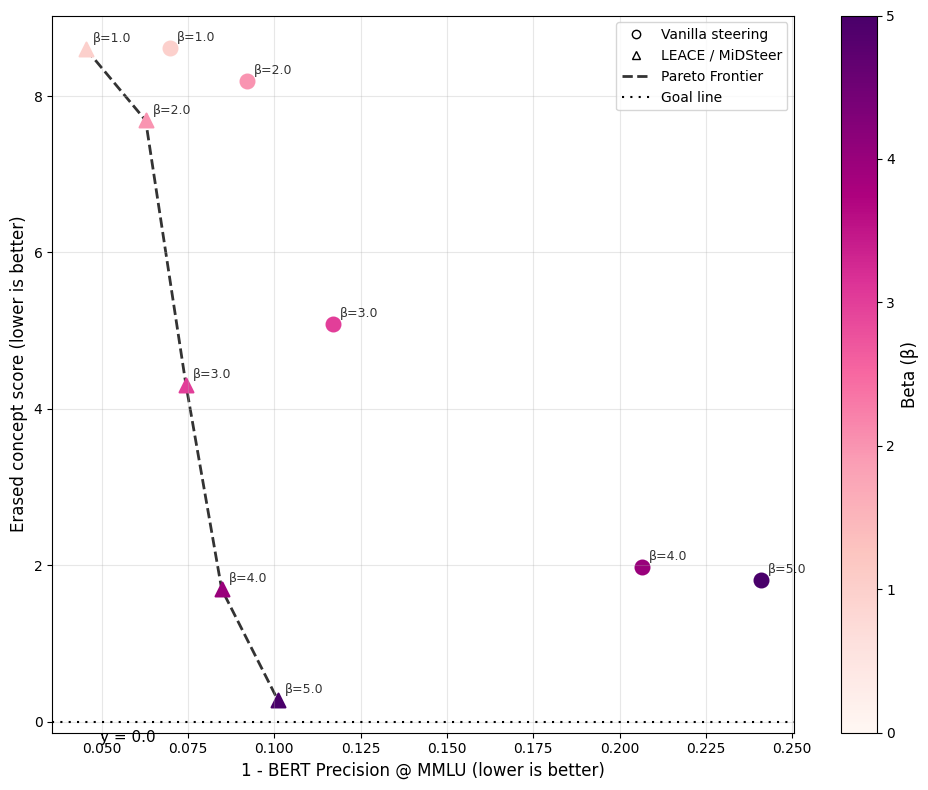

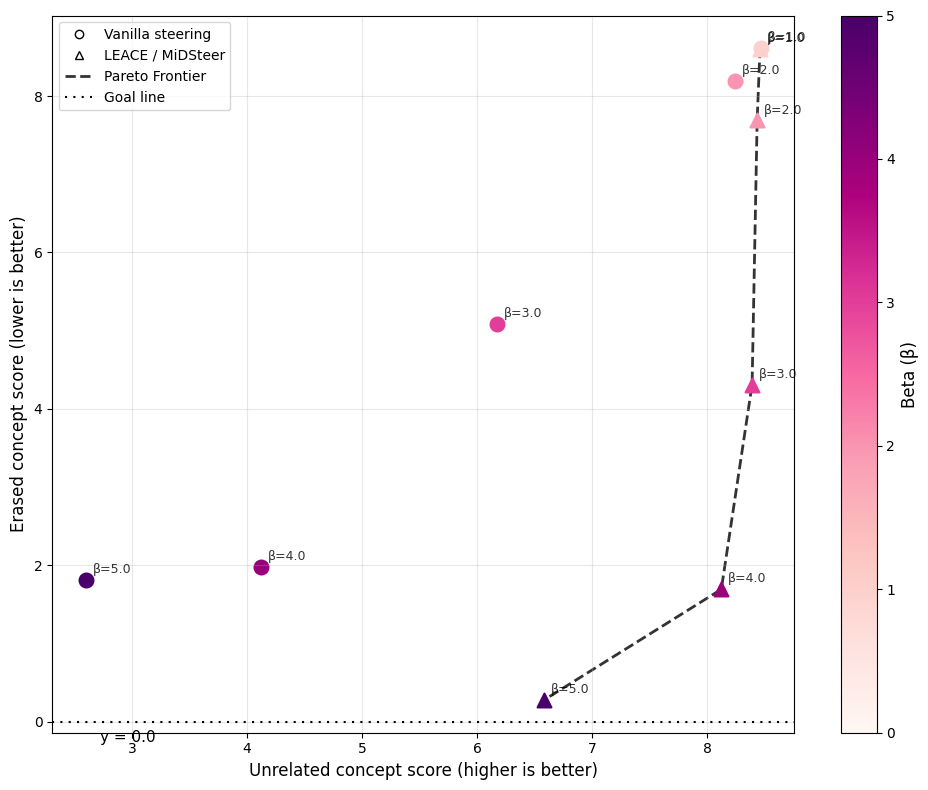

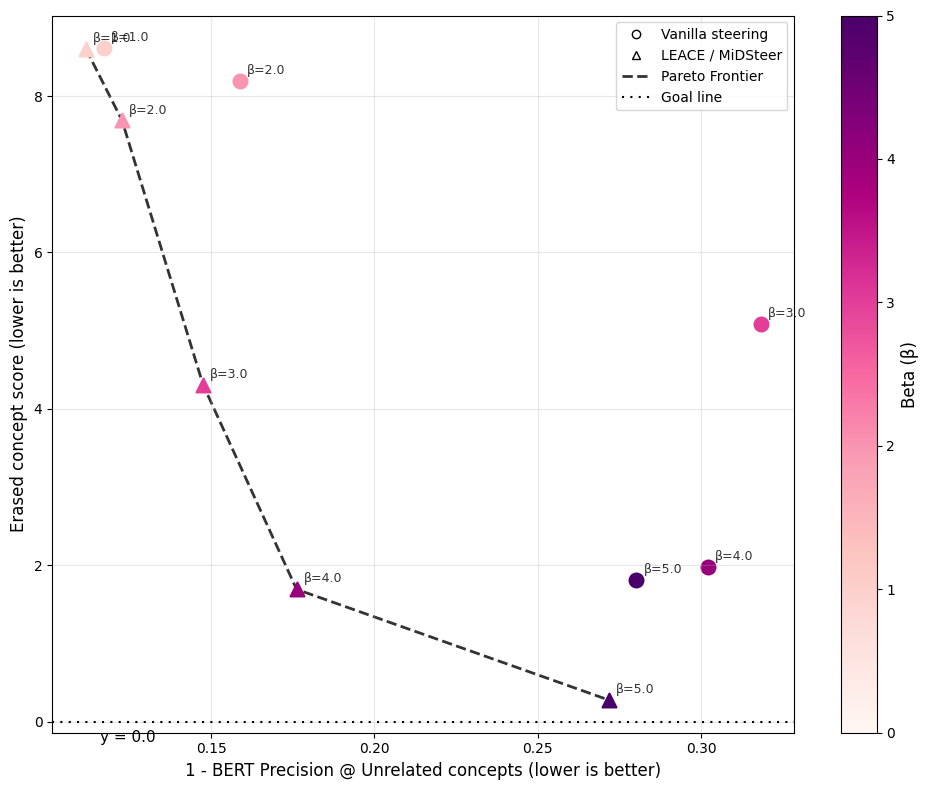

In [308]:
generate_erase_plots_with_different_axes(
    experiment_name='../exp/results/Qwen-Qwen2.5-7B-Instruct/erasure_qwen_7b_50k_clip/evaluation/',
    output_filename_template='../artefacts/pareto/qwen-7b-erasure-clip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(10, 8),
)

### Llama 2 7B

#### No clip

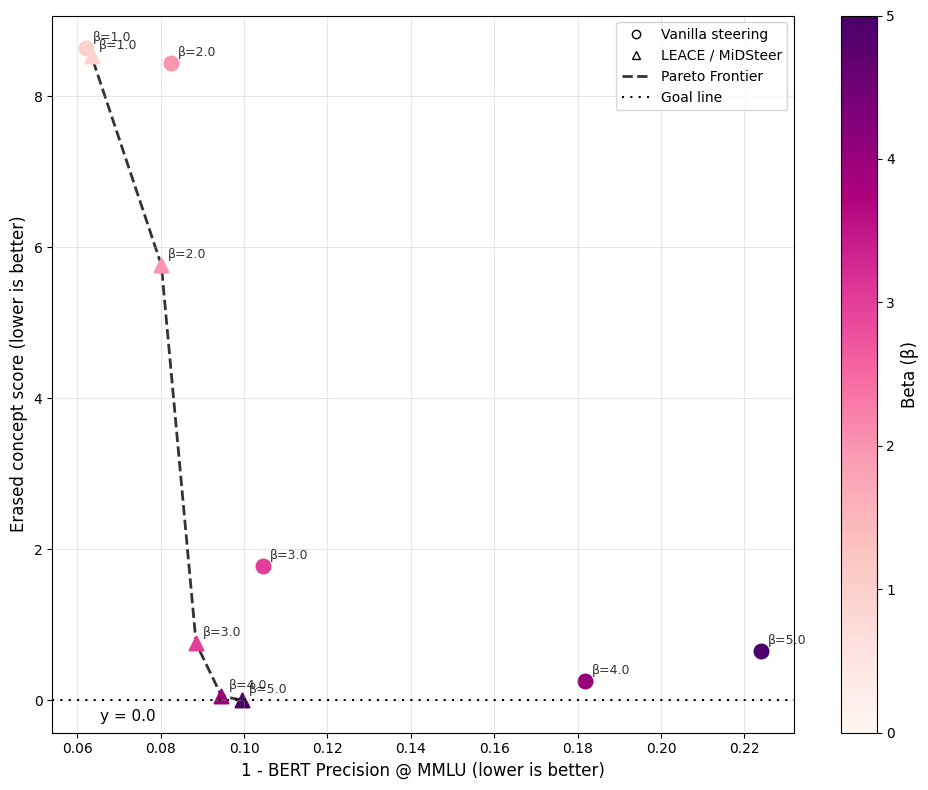

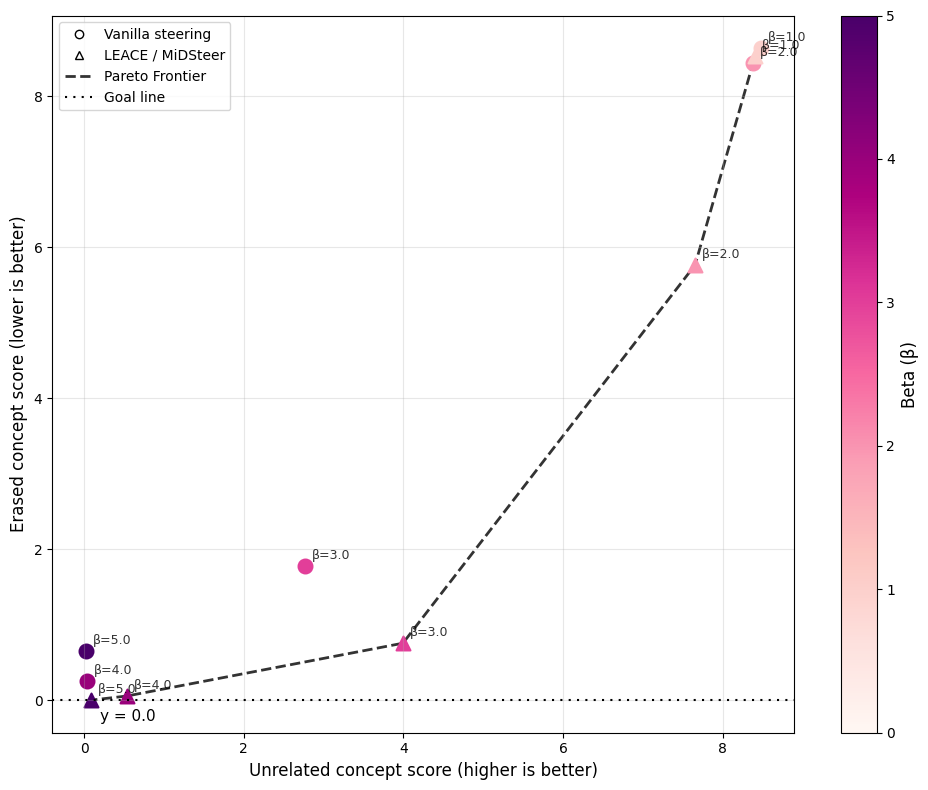

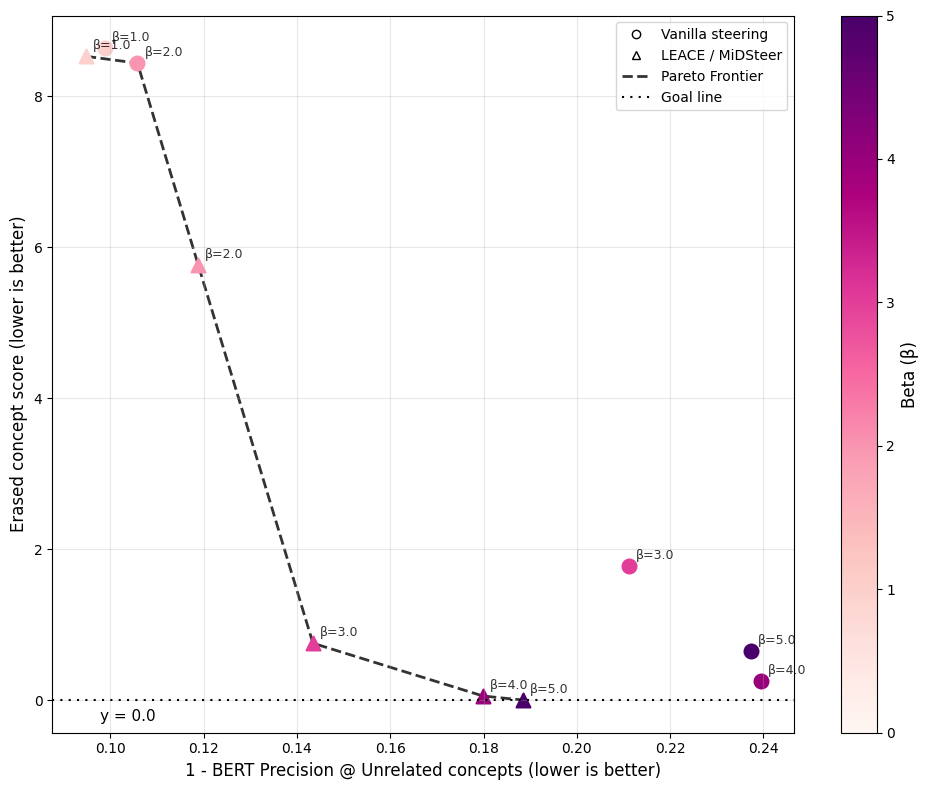

In [309]:
generate_erase_plots_with_different_axes(
    experiment_name='../exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_erasure_llama2/evaluation/',
    output_filename_template='../artefacts/pareto/llama2-7b-erasure-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(10, 8),
)

##### Main paper

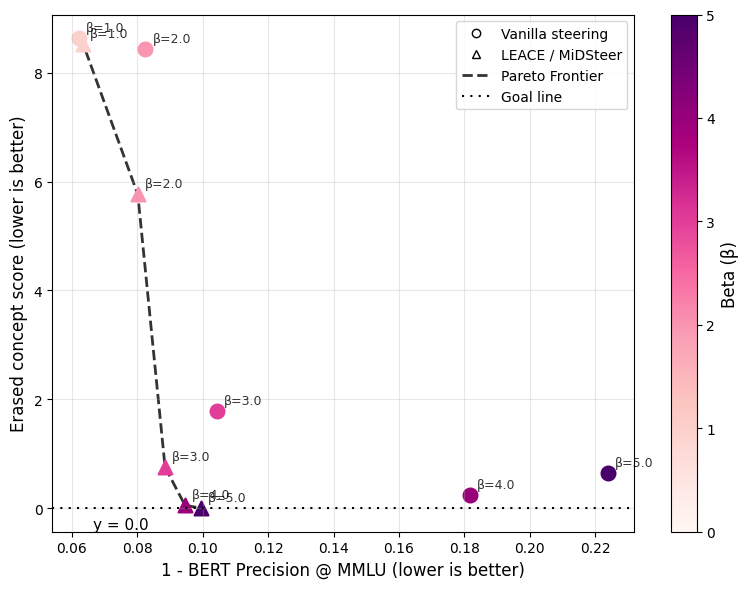

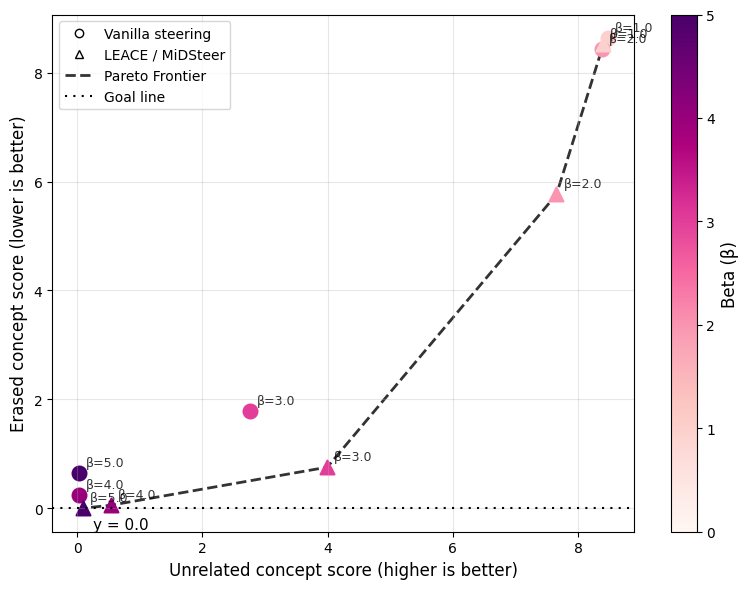

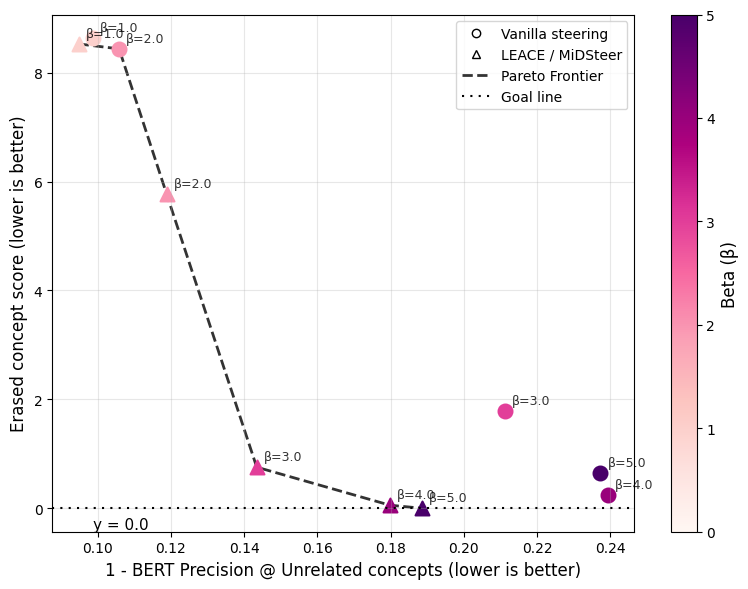

In [393]:
generate_erase_plots_with_different_axes(
    experiment_name='../exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_erasure_llama2/evaluation/',
    output_filename_template='../artefacts/main/llama2-7b-erasure-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(8, 6),
)

#### Clip

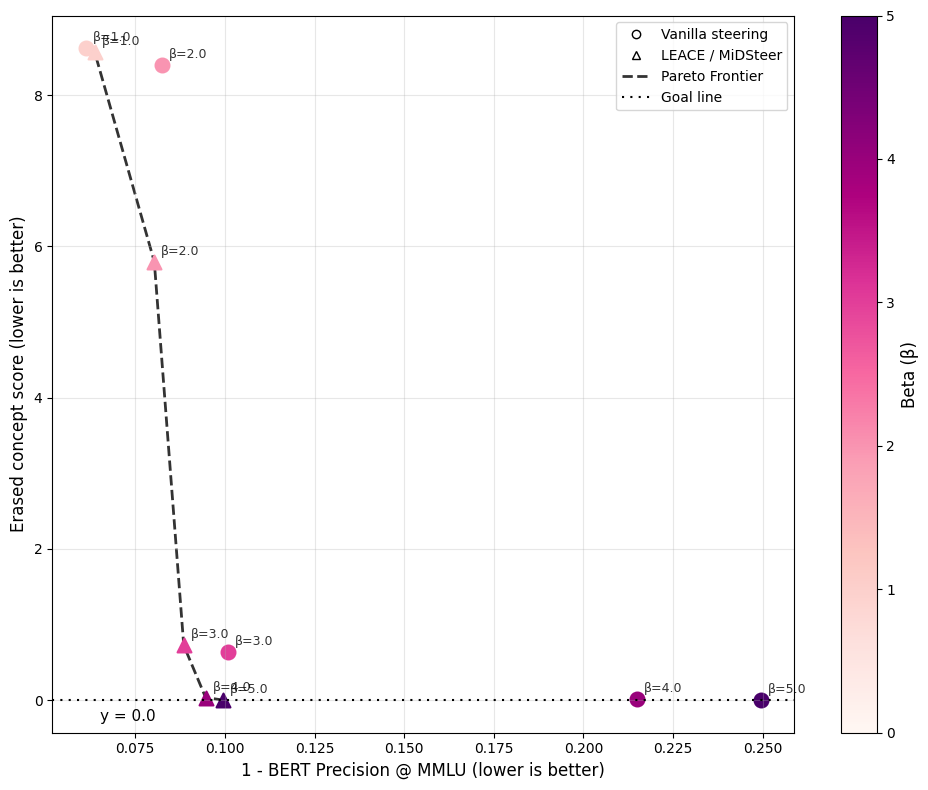

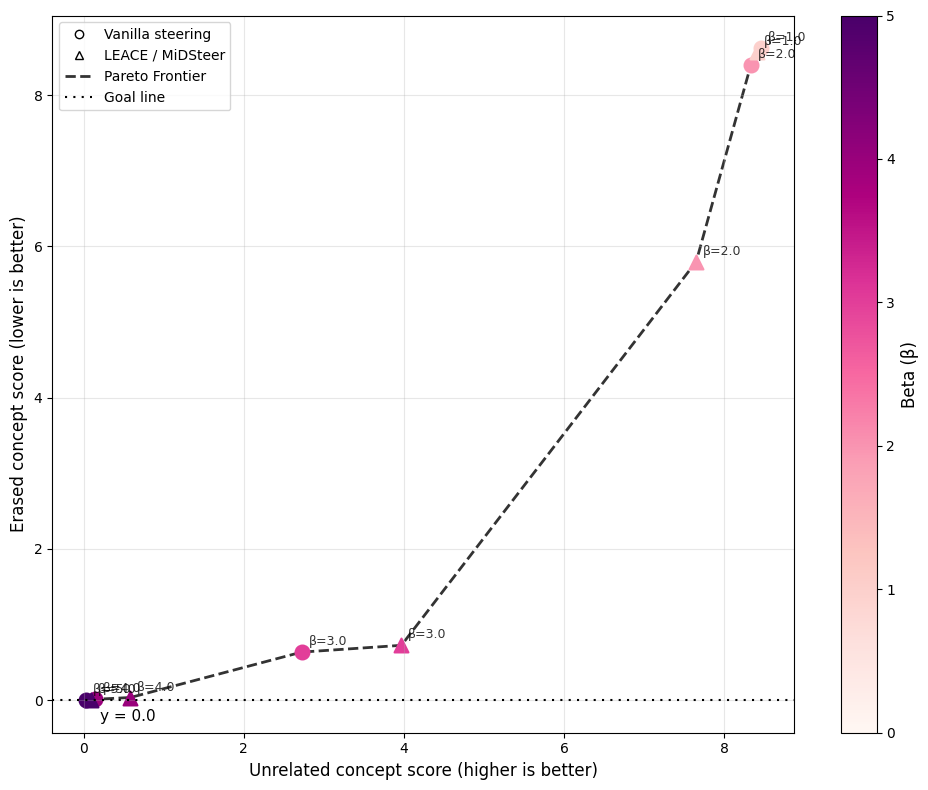

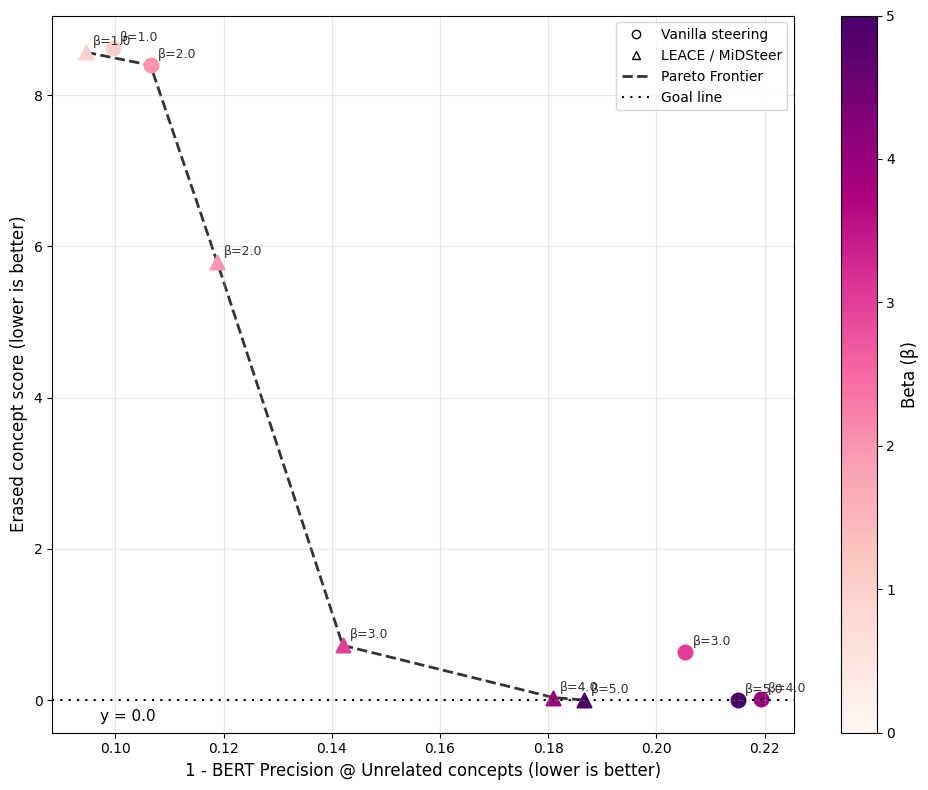

In [311]:
generate_erase_plots_with_different_axes(
    experiment_name='../exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_erasure_llama2_clip/evaluation/',
    output_filename_template='../artefacts/pareto/llama2-7b-erasure-clip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,    
    figsize=(10, 8),
)

## LLM flip

In [397]:
def produce_llm_flip_pareto_plot(
    experiment_name: str,
    x_axis: str,
    y_axis: str,
    output_filename: str | None = None,
    figsize=(12, 8),
):
    consistency_scores, concept_scores = parse_llm_flip_experiment(
        experiment_name
    )

    tcs = (concept_scores
            .query("method_name == 'orig'")
            .query("test_concept == target_concept & concept == target_concept")
            .agg({'avg_score': 'mean'}))
    scs = (concept_scores
            .query("method_name == 'orig'")
            .query("test_concept == target_concept & concept == source_concept")
            .agg({'avg_score': 'mean'}))

    if y_axis == 'delta_concept_score':
        goal = (tcs - scs)[0]
    elif y_axis == 'source_concept_score':
        goal = scs[0]
    elif y_axis == 'target_concept_score':
        goal = tcs[0]
    data = (
        (
            consistency_scores
            .query("dataset == 'mmlu'")
            .groupby(['method_name', 'strength'])
            .agg({'bert_precision': 'mean'})
            .assign(one_minus_mmlu_bert_p=lambda x: 1 - x.bert_precision)
        ).join(
            concept_scores
            .query("(concept == target_concept) & (source_concept == test_concept)")
            .groupby(['method_name', 'strength'])
            .agg({'avg_score': 'mean'})
            .rename({'avg_score': 'target_concept_score'}, axis=1)
        ).join(
            concept_scores
            .query("(concept == source_concept) & (source_concept == test_concept)")
            .groupby(['method_name', 'strength'])
            .agg({'avg_score': 'mean'})
            .rename({'avg_score': 'source_concept_score'}, axis=1)
        ).join(
            concept_scores
            .query("(concept == test_concept) & (source_concept != test_concept)")
            .query("test_concept not in @IMPLICIT_CONCEPTS")
            .groupby(['method_name', 'strength'])
            .agg({'avg_score': 'mean'})
            .rename({'avg_score': 'unrelated_concept_score'}, axis=1)
        ).join(
            consistency_scores
            .query('dataset == "eval"')
            .query("test_concept != source_concept")
            .query("test_concept not in @IMPLICIT_CONCEPTS")
            .groupby(['method_name', 'strength'])
            .agg({'bert_precision': 'mean'})
            .rename({'bert_precision': 'unrelated_bert_p'}, axis=1)
            .assign(one_minus_unrelated_bert_p=lambda x: 1 - x.unrelated_bert_p)
        )
        .reset_index()
        .assign(delta_concept_score=lambda x: x.target_concept_score - x.source_concept_score)
    )

    plot_pareto_frontier(
        data=data,
        x_column=x_axis,
        y_column=y_axis,
    
        x_label=AXES[x_axis]['label'],
        y_label=AXES[y_axis]['label'],
        x_better=AXES[x_axis]['better'],
        y_better=AXES[y_axis]['better'],
        title='',
        output_fname=output_filename,
        y_goal=goal,
        figsize=figsize,
    )

In [399]:
def generate_flip_plots_with_different_axes(
    experiment_name: str,
    output_filename_template: str,
    x_axes_mapping: dict[str, str],
    figsize=(12, 8),
):
    for x_axis, name in x_axes_mapping.items():
        produce_llm_flip_pareto_plot(
            experiment_name=experiment_name,
            y_axis='delta_concept_score',
            x_axis=x_axis,
            output_filename=output_filename_template.format(name),
            figsize=figsize,
        )
        produce_llm_flip_pareto_plot(
            experiment_name=experiment_name,
            y_axis='source_concept_score',
            x_axis=x_axis,
            output_filename=output_filename_template.format(name + '-scs'),
            figsize=figsize,
        )
        produce_llm_flip_pareto_plot(
            experiment_name=experiment_name,
            y_axis='target_concept_score',
            x_axis=x_axis,
            output_filename=output_filename_template.format(name + '-tcs'),
            figsize=figsize,
        )

### Qwen 14B

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

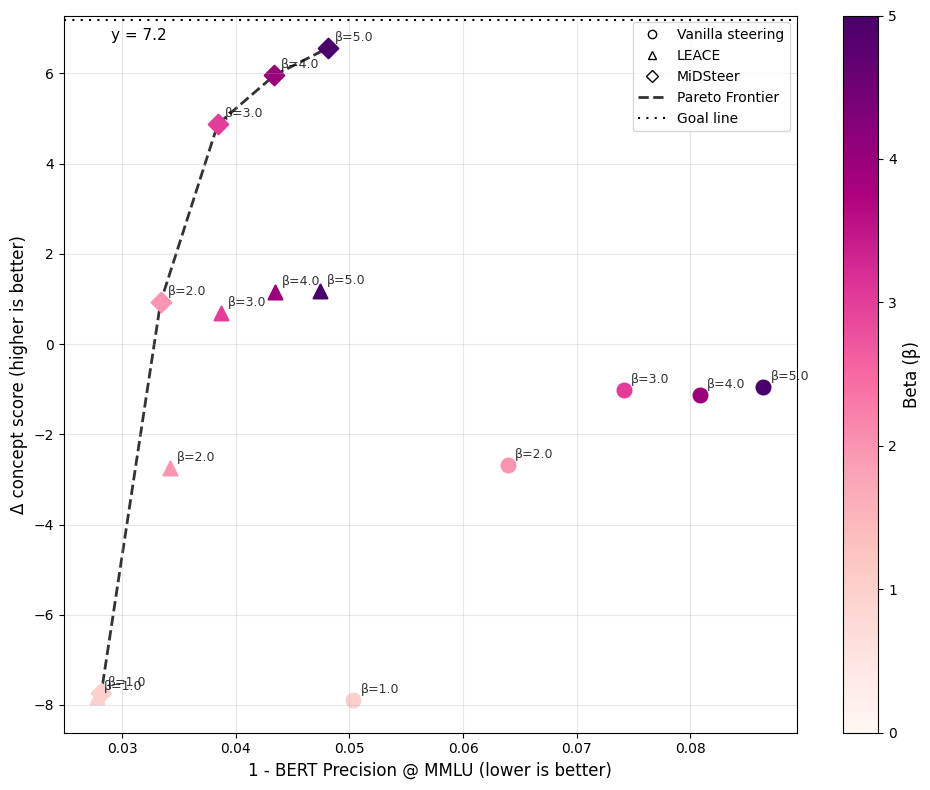

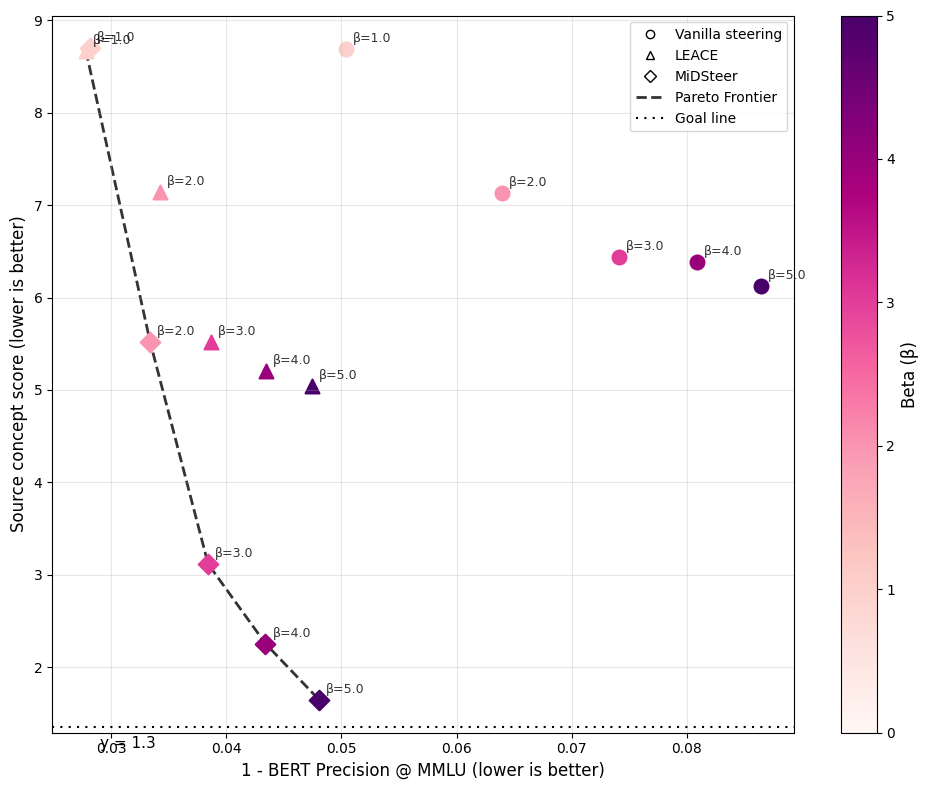

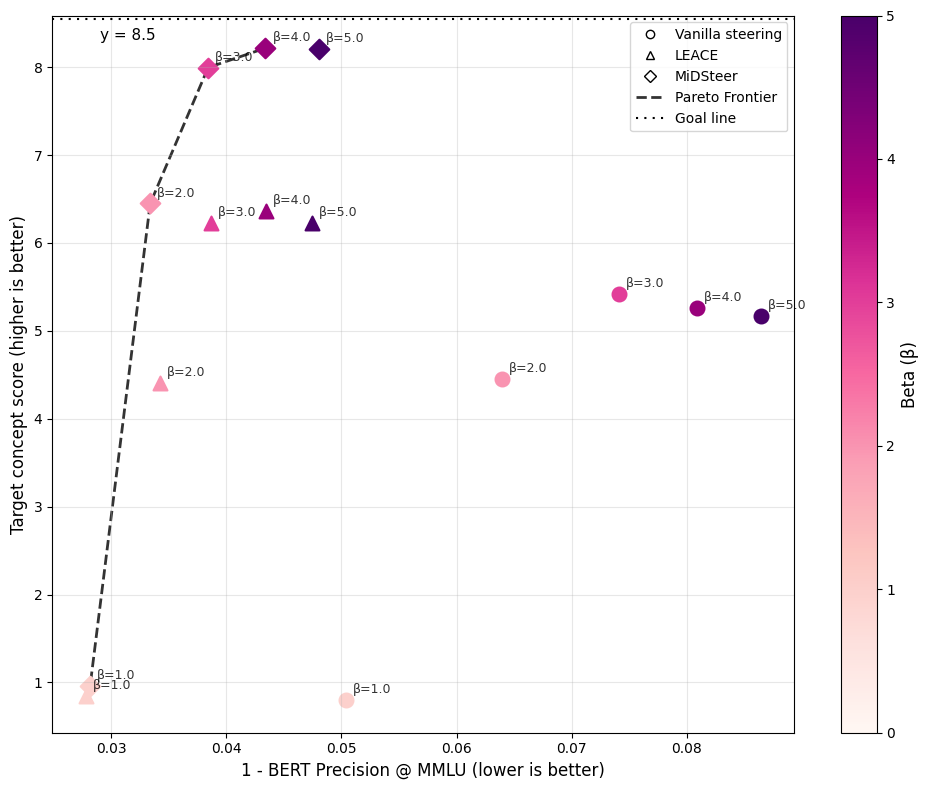

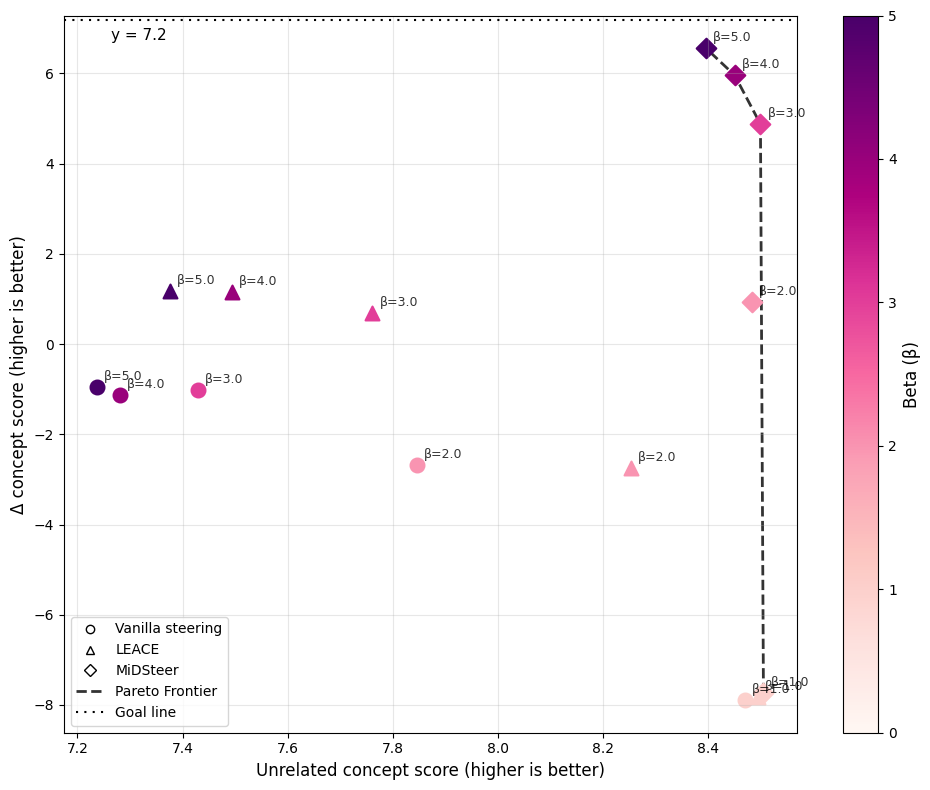

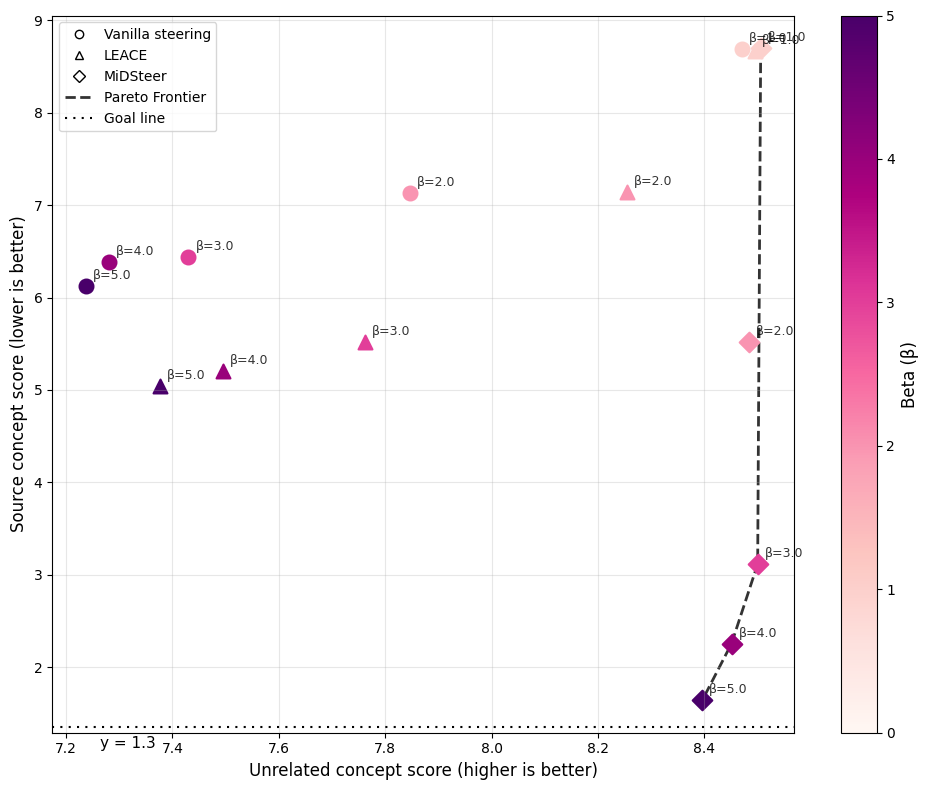

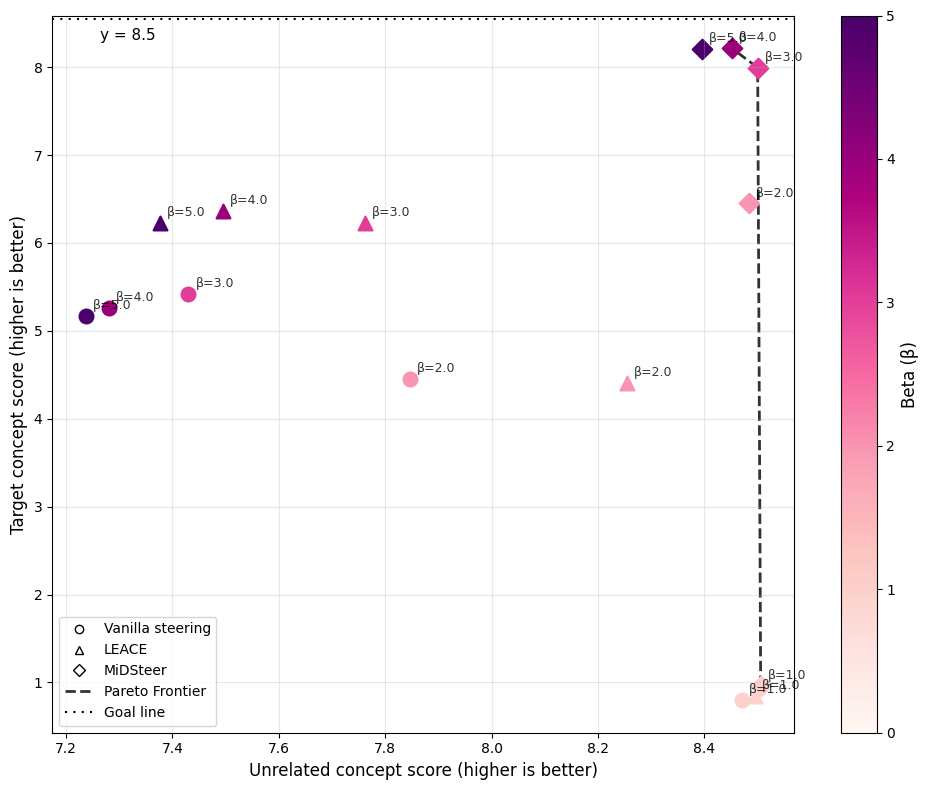

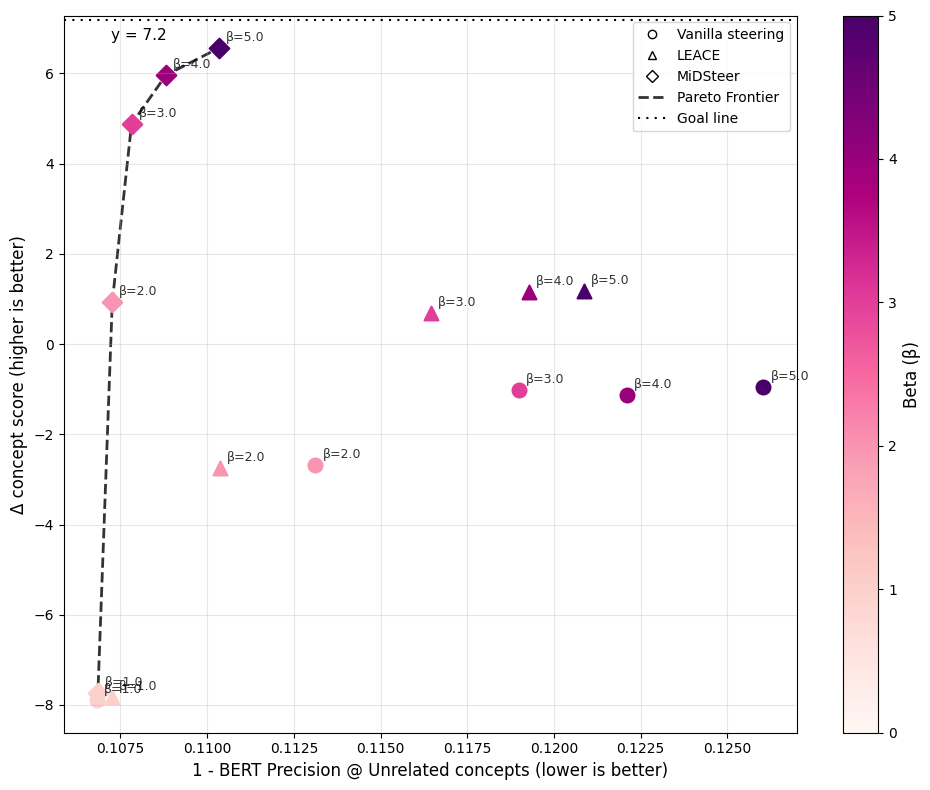

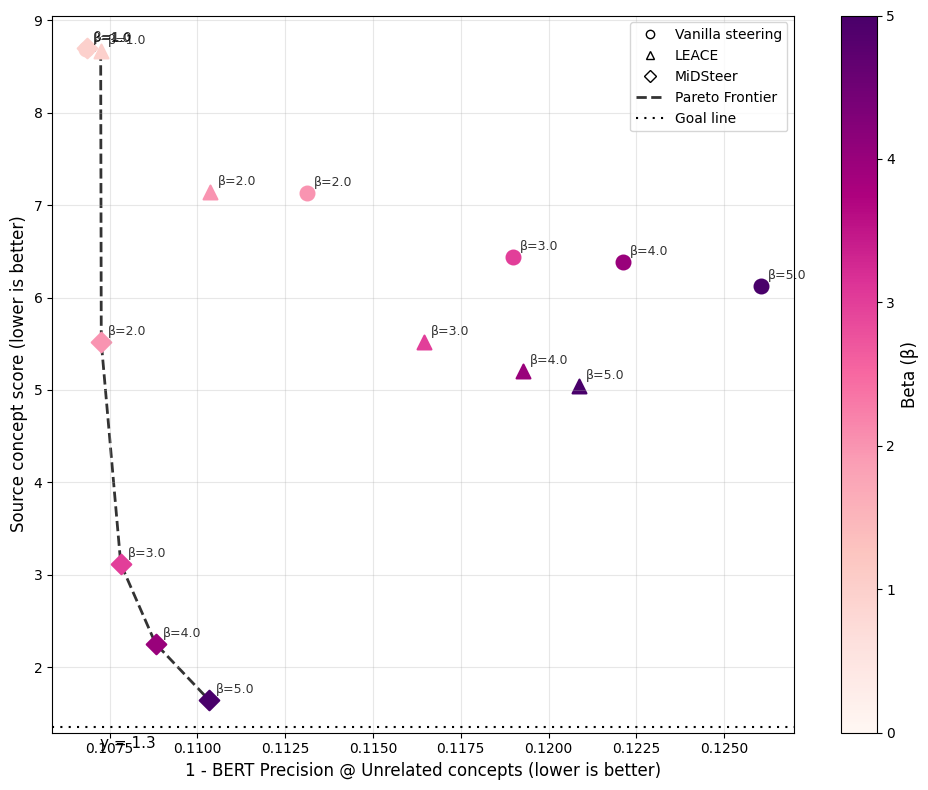

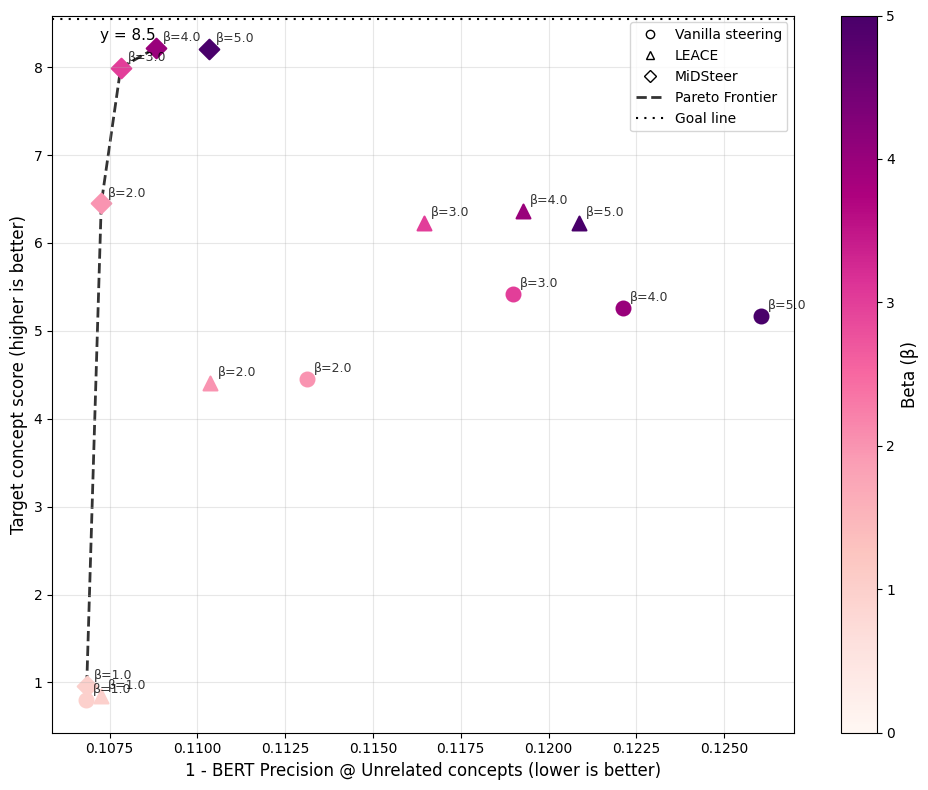

In [400]:
generate_flip_plots_with_different_axes(
    experiment_name='../exp/results/Qwen-Qwen2.5-14B-Instruct/llm_flipping_midsteer_qwen_14b_50k/evaluation/',
    output_filename_template='../artefacts/pareto/qwen-14b-flip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(10, 8),
)

### Qwen 7B

#### No clip

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

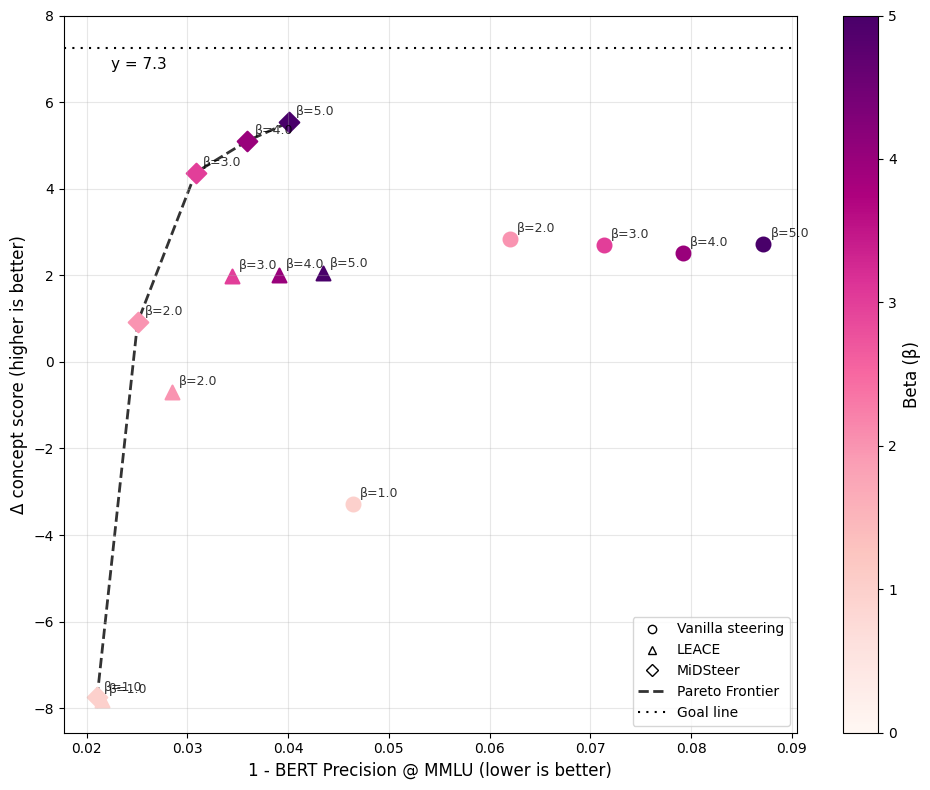

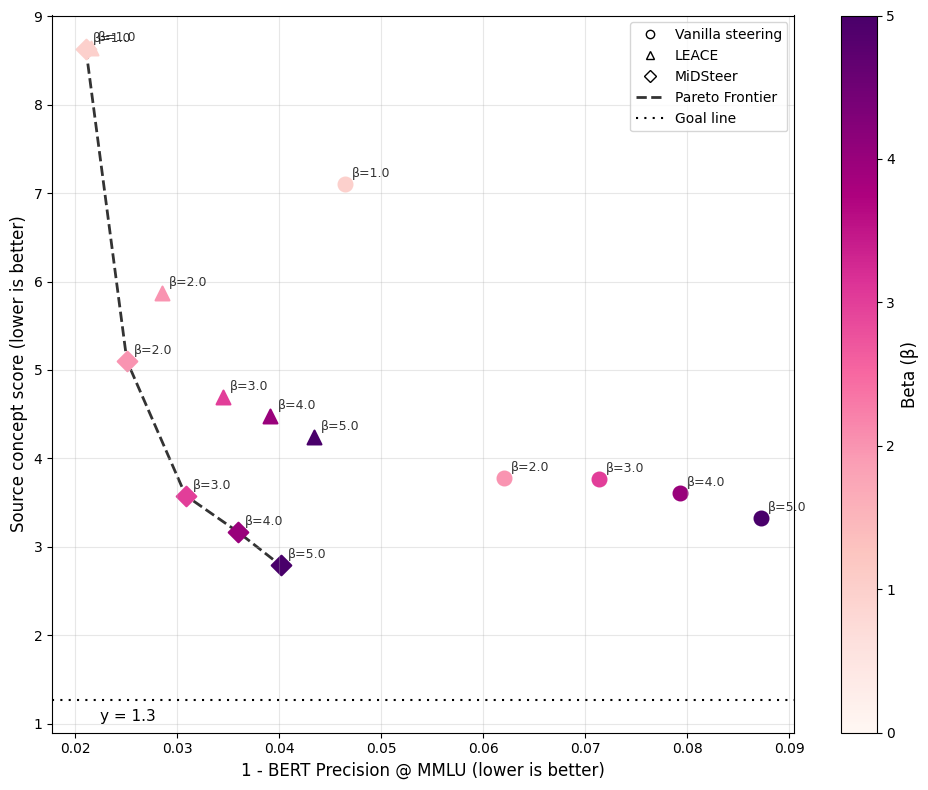

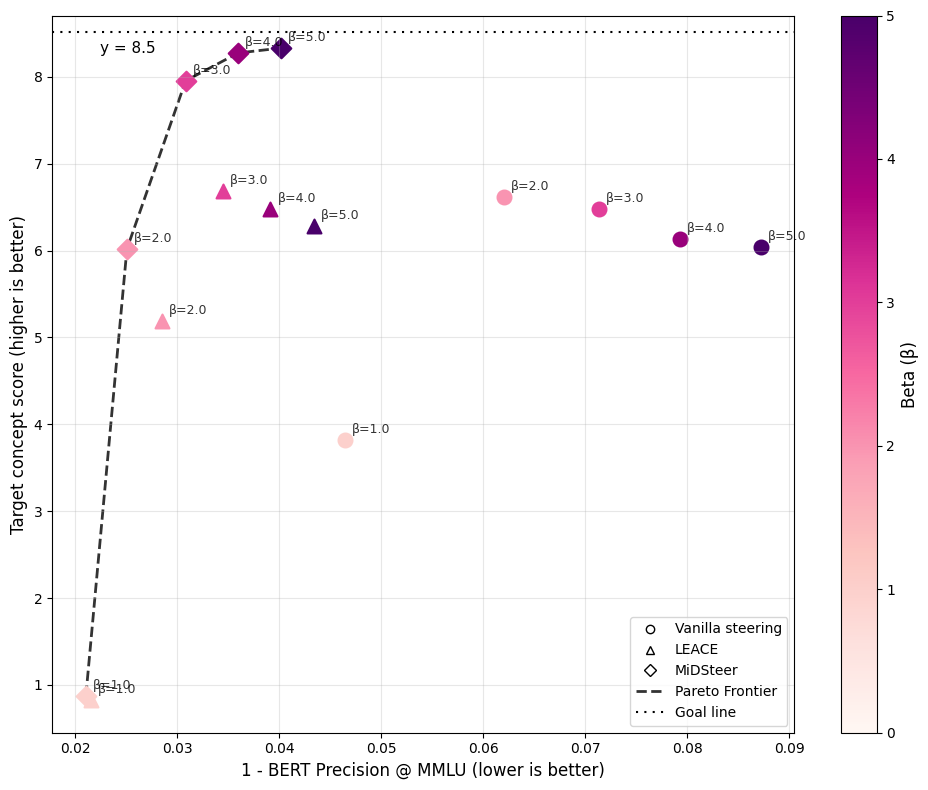

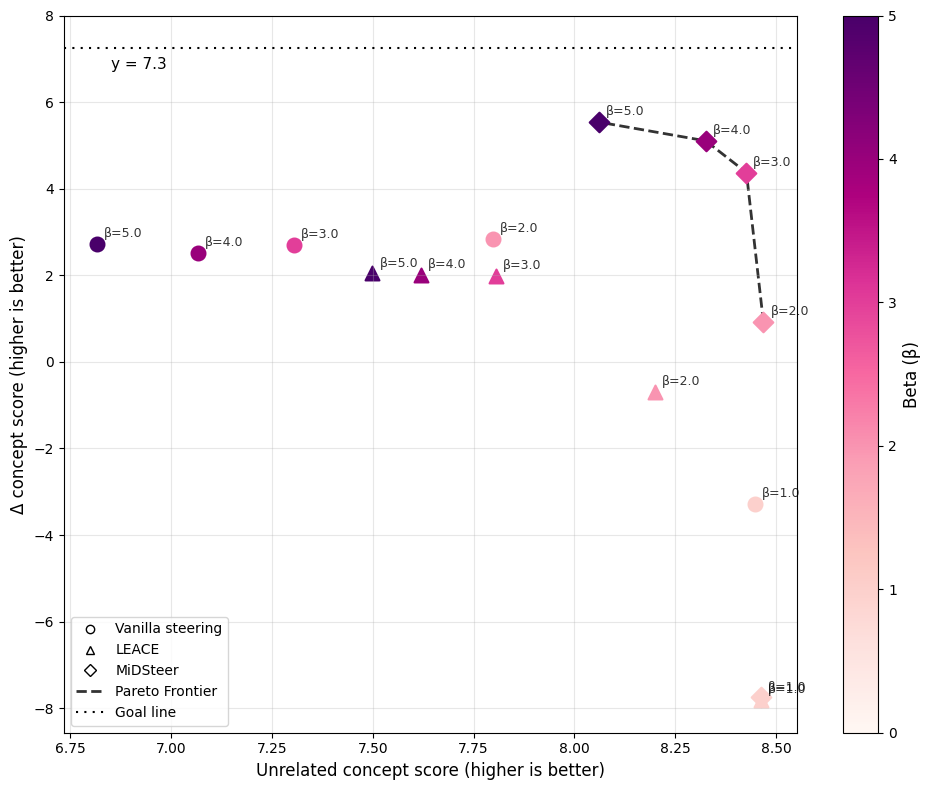

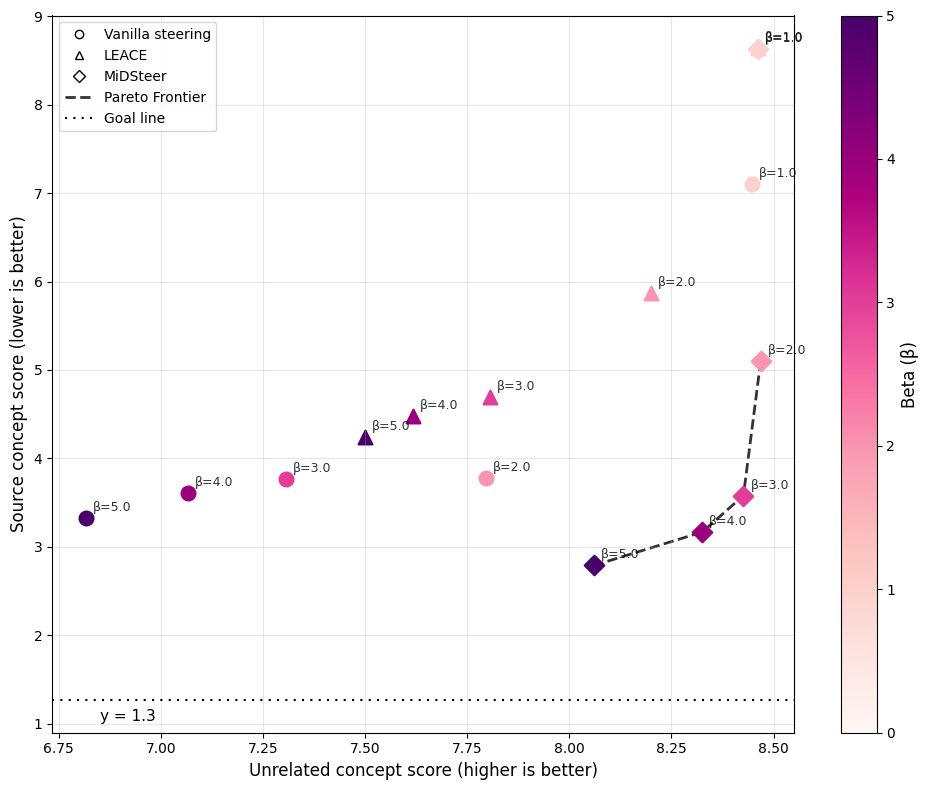

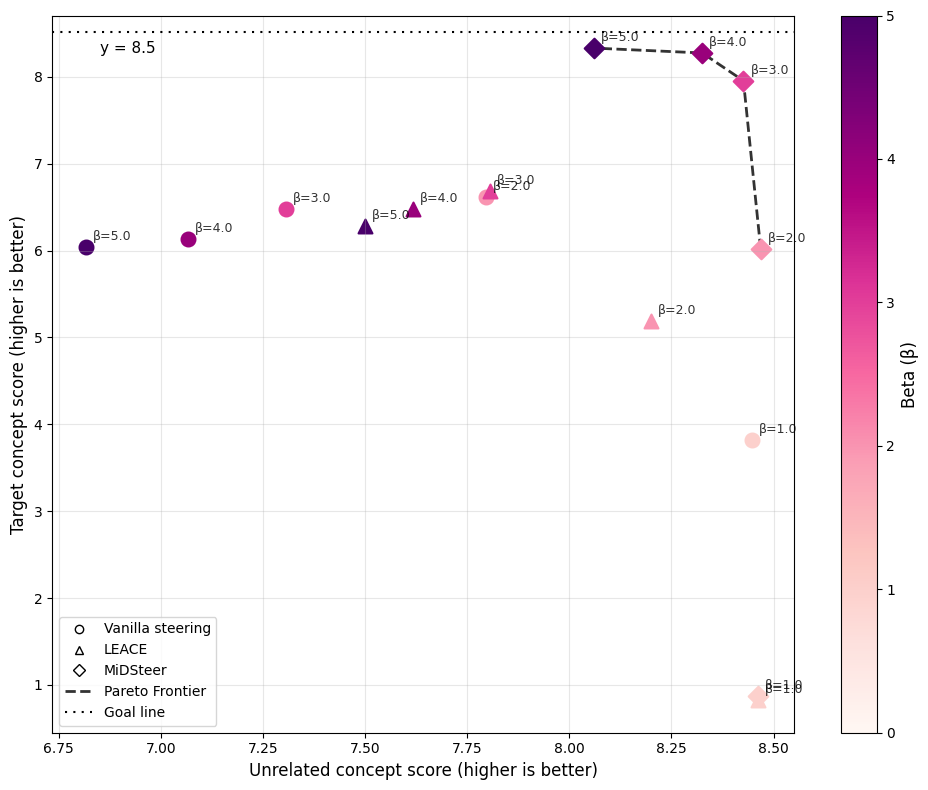

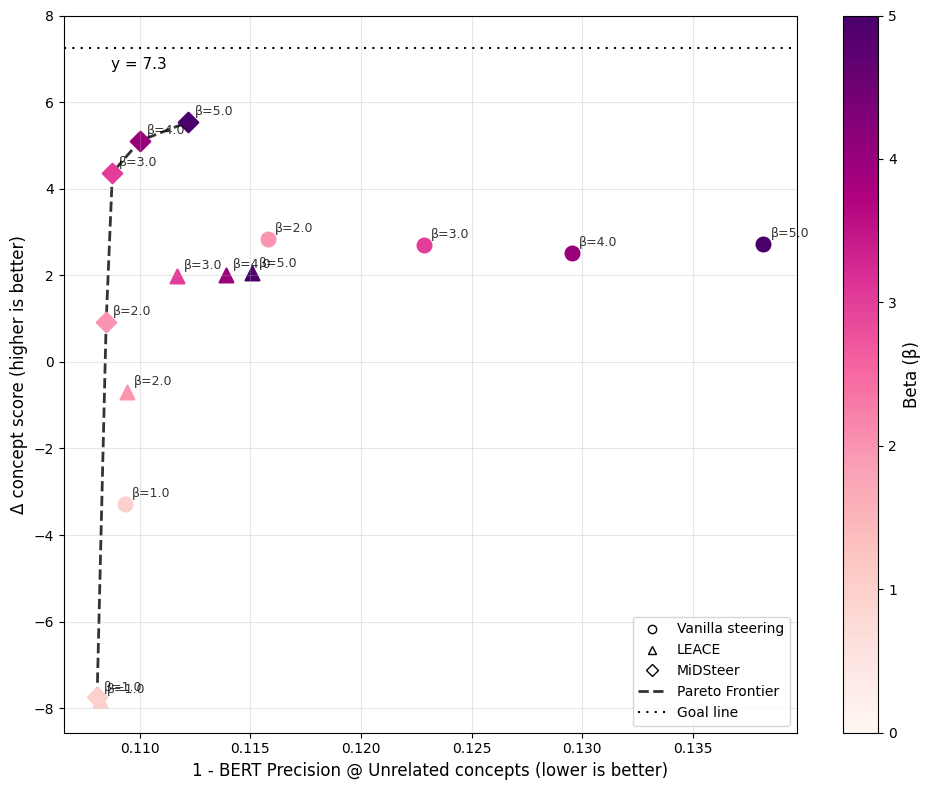

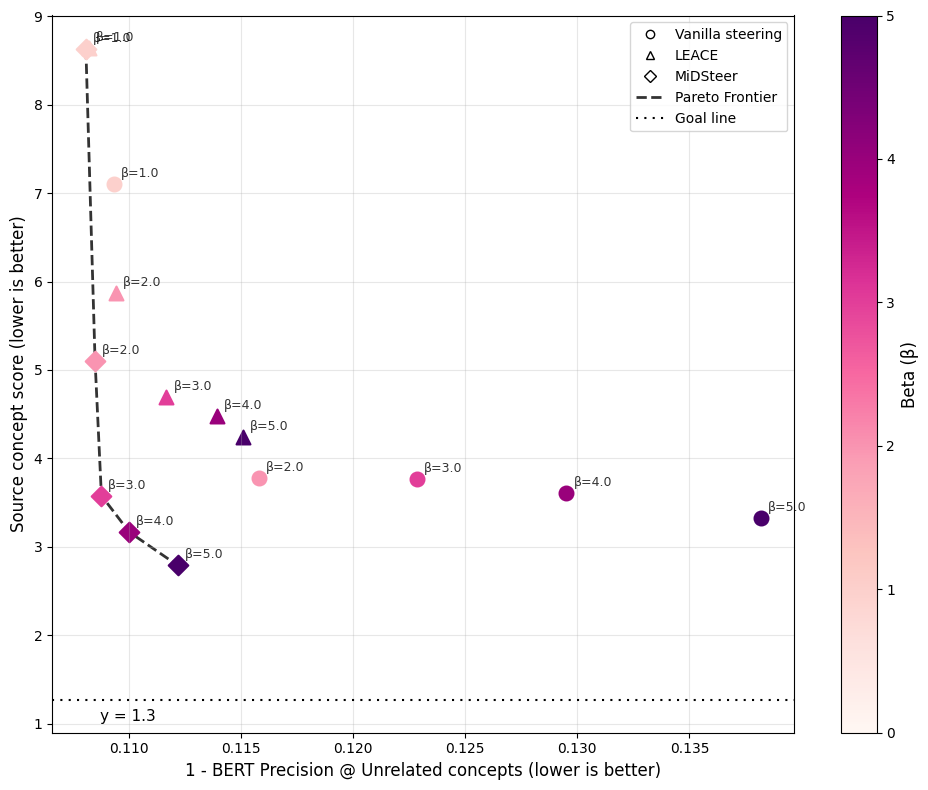

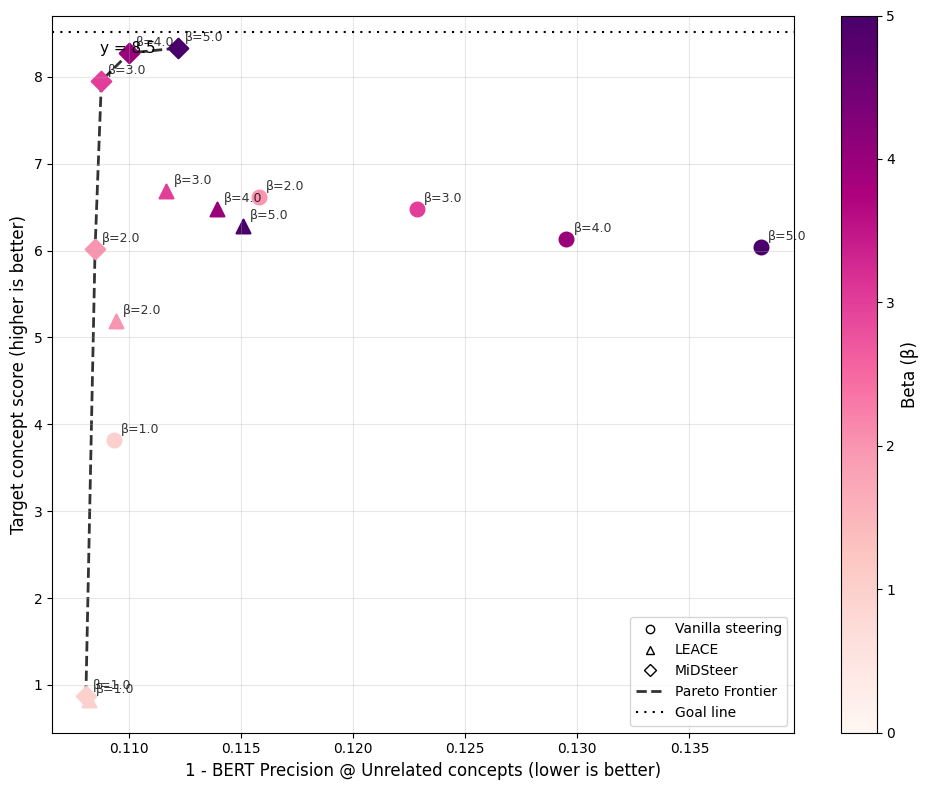

In [401]:
generate_flip_plots_with_different_axes(
    experiment_name='../exp/results/Qwen-Qwen2.5-7B-Instruct/llm_flipping_midsteer_qwen_50k/evaluation/',
    output_filename_template='../artefacts/pareto/qwen-7b-flip-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(10, 8),
)

#### Clip

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

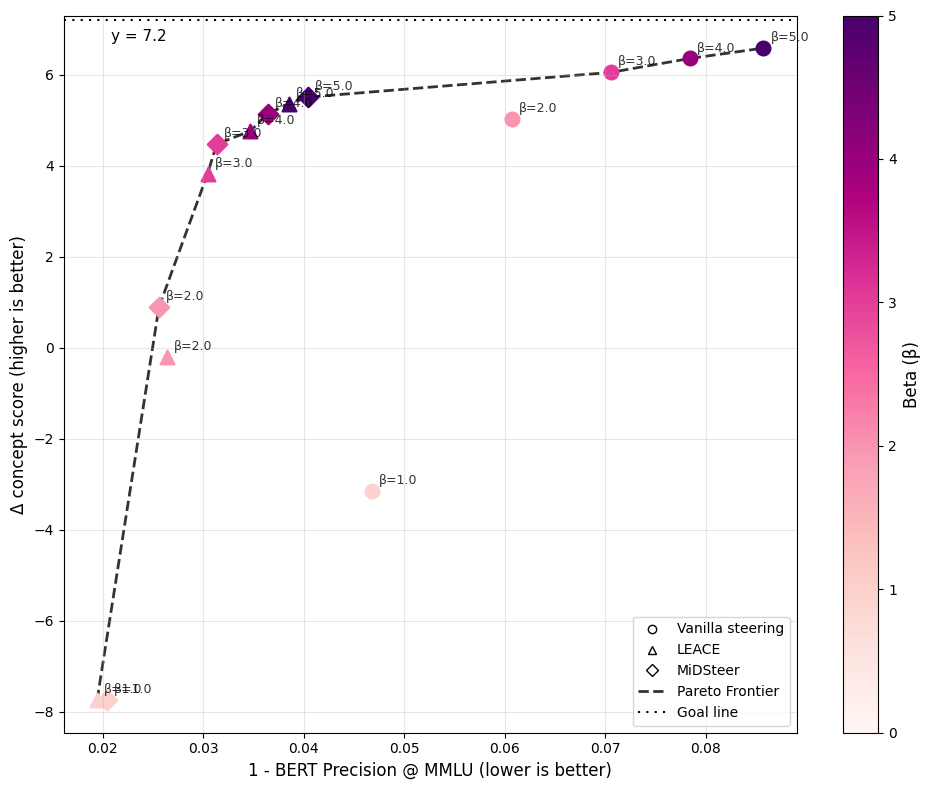

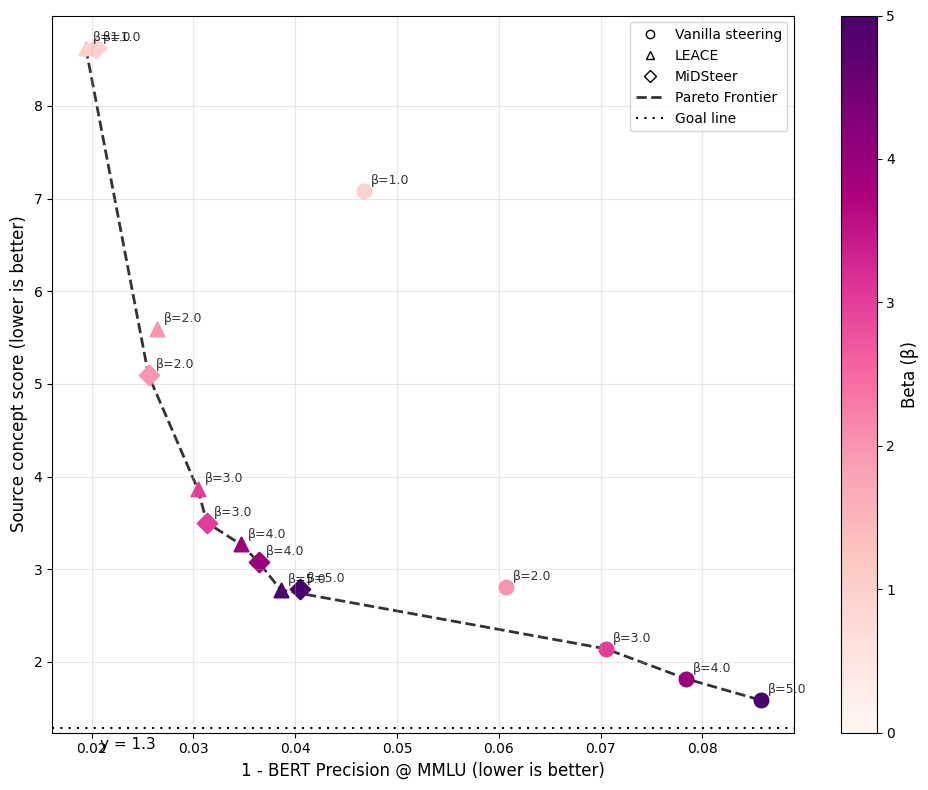

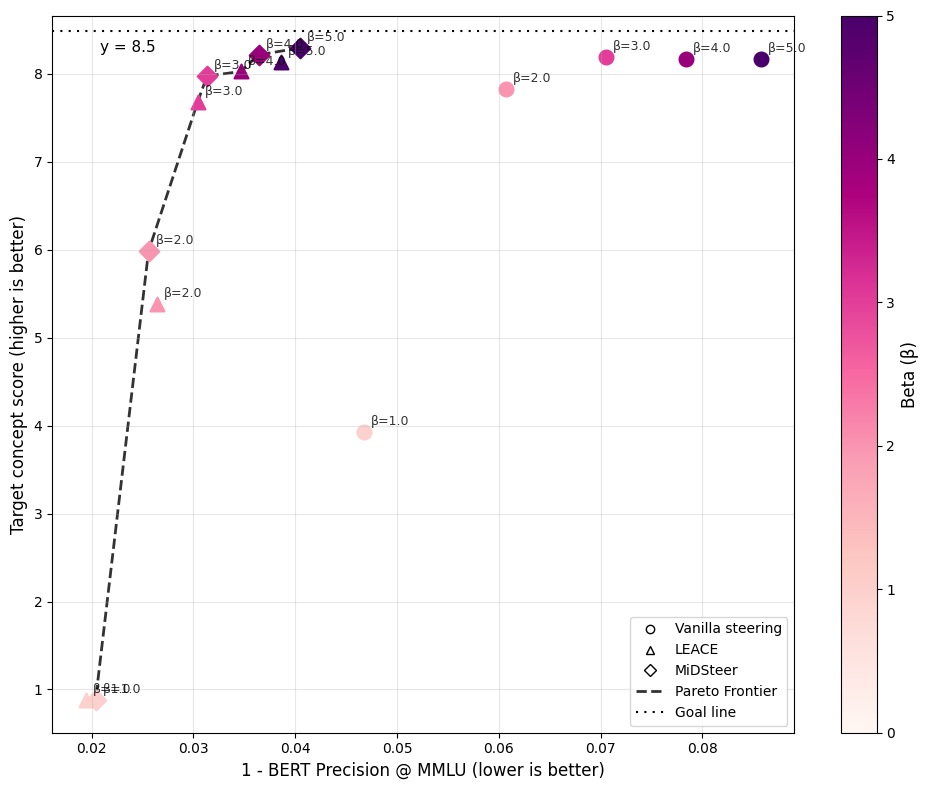

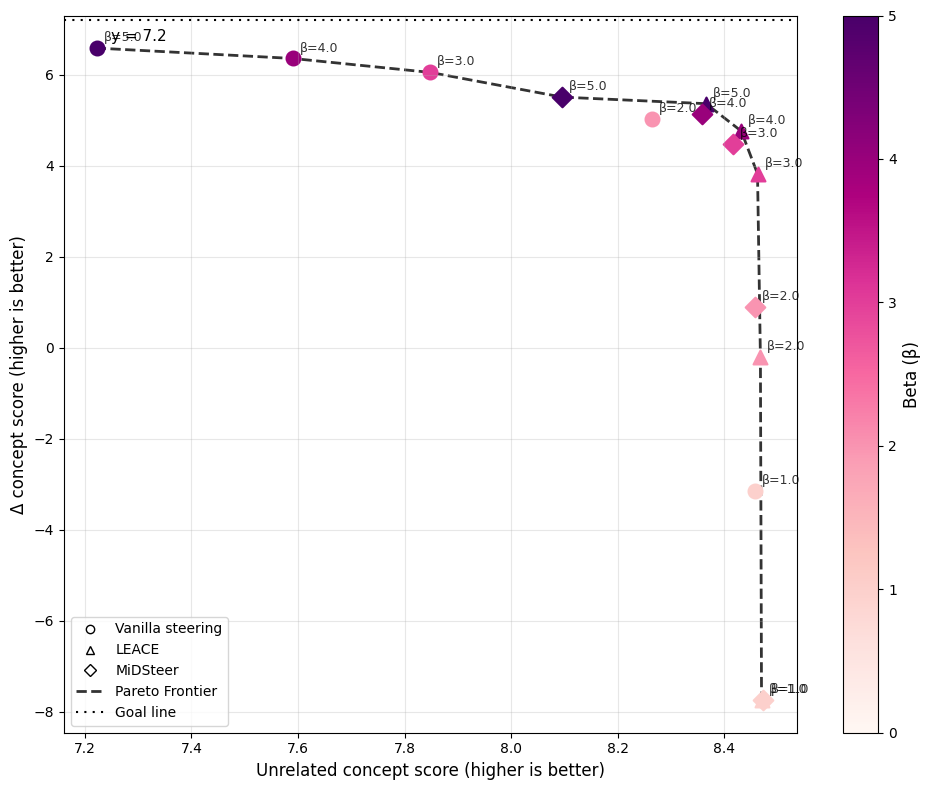

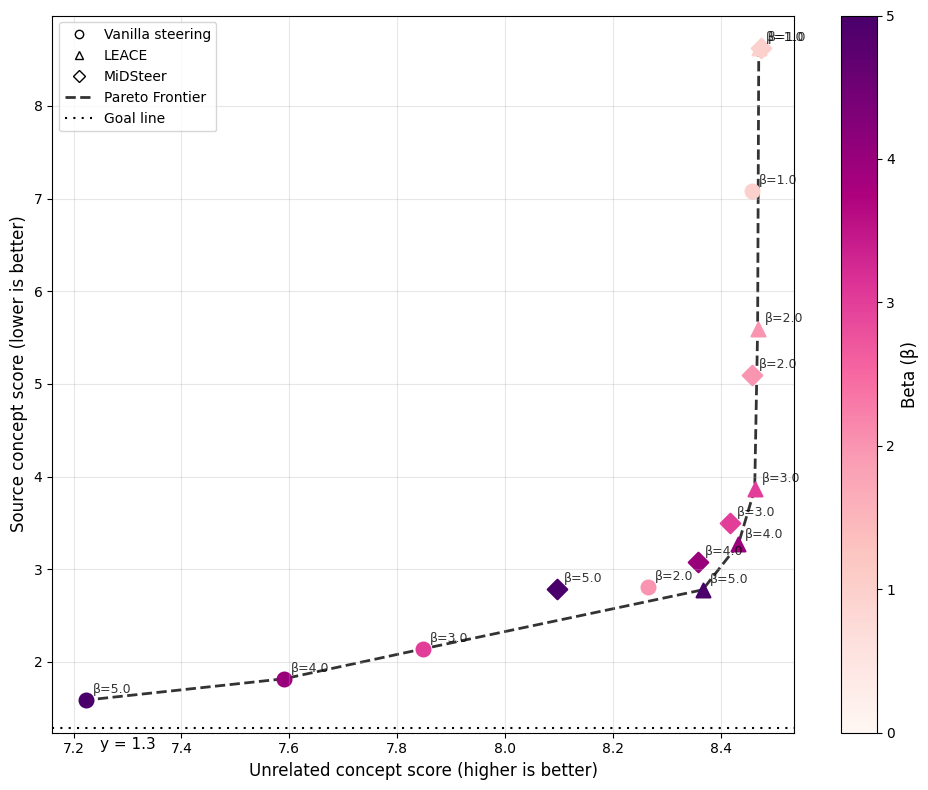

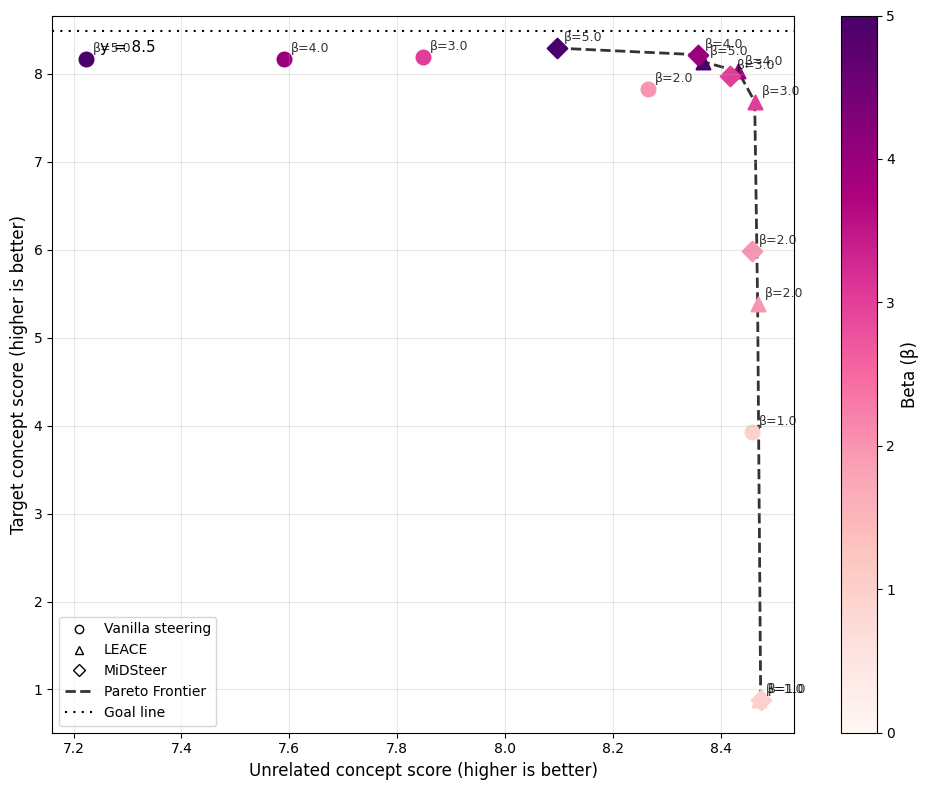

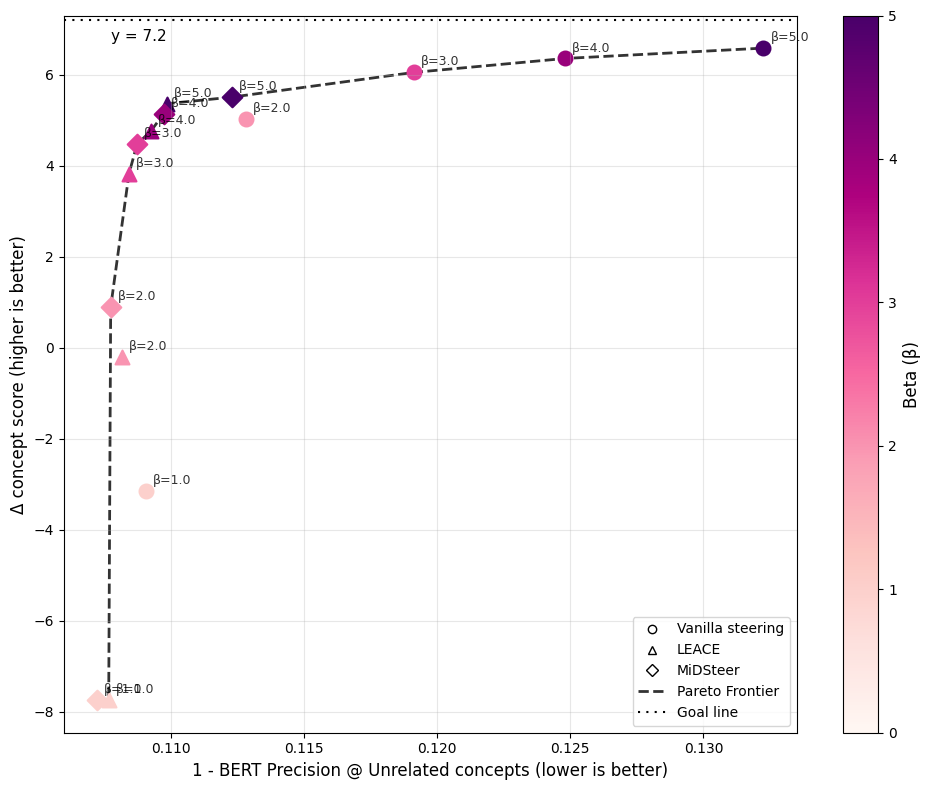

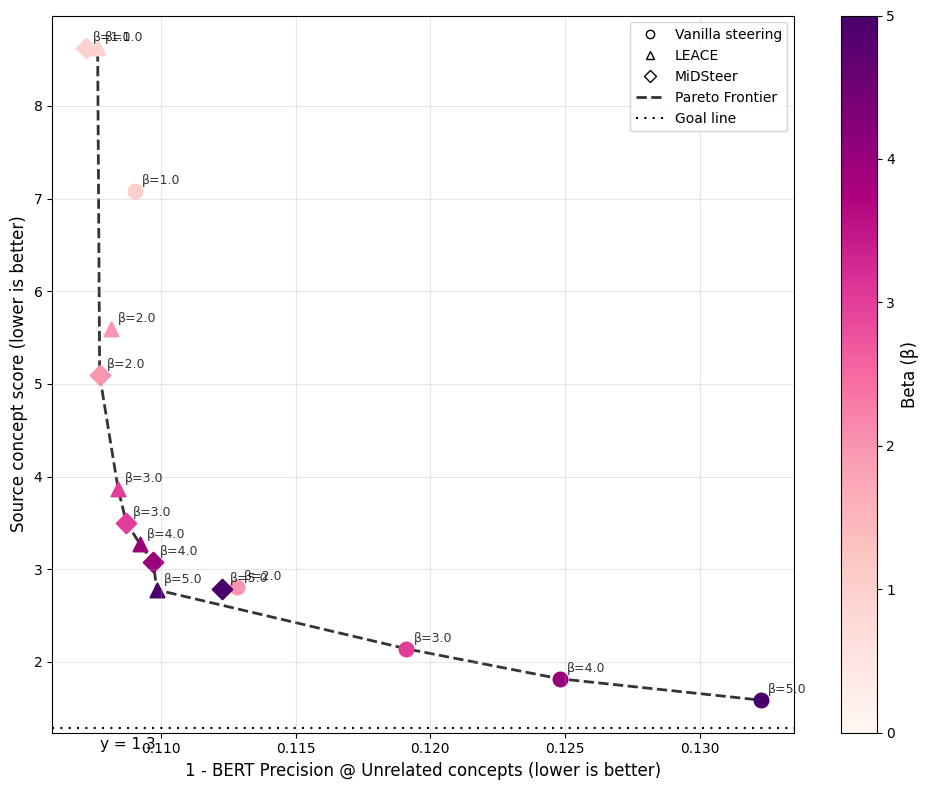

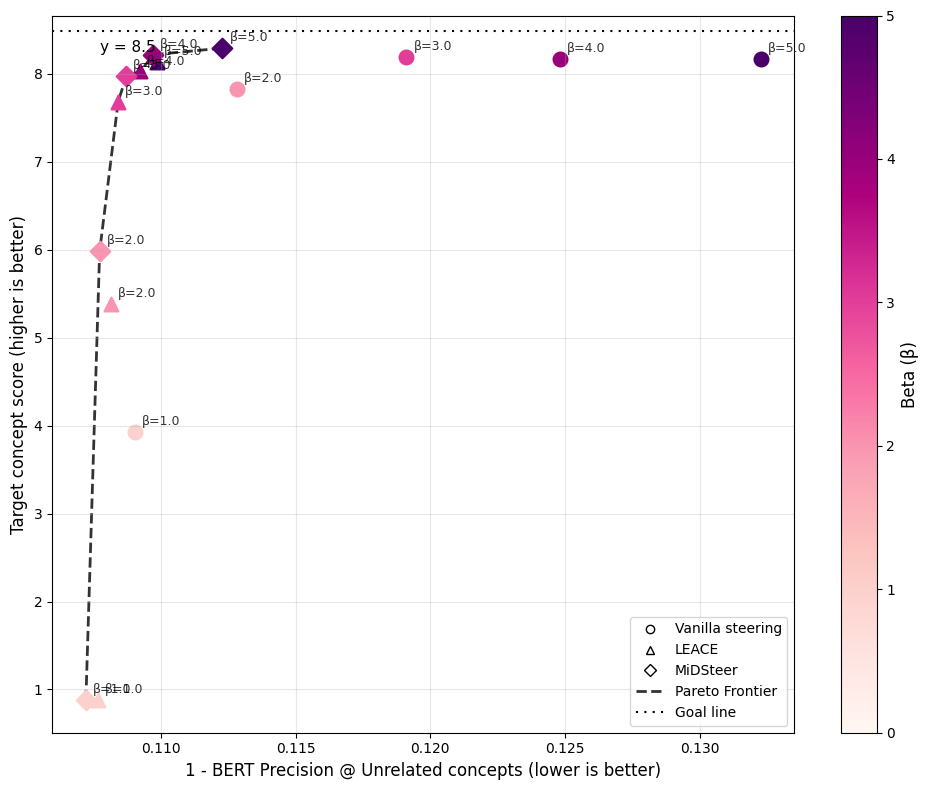

In [402]:
generate_flip_plots_with_different_axes(
    experiment_name='../exp/results/Qwen-Qwen2.5-7B-Instruct/llm_flipping_midsteer_qwen_50k_clip/evaluation/',
    output_filename_template='../artefacts/pareto/qwen-7b-flip-clip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(10, 8),
)

### LLama2 7B

#### No clip

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

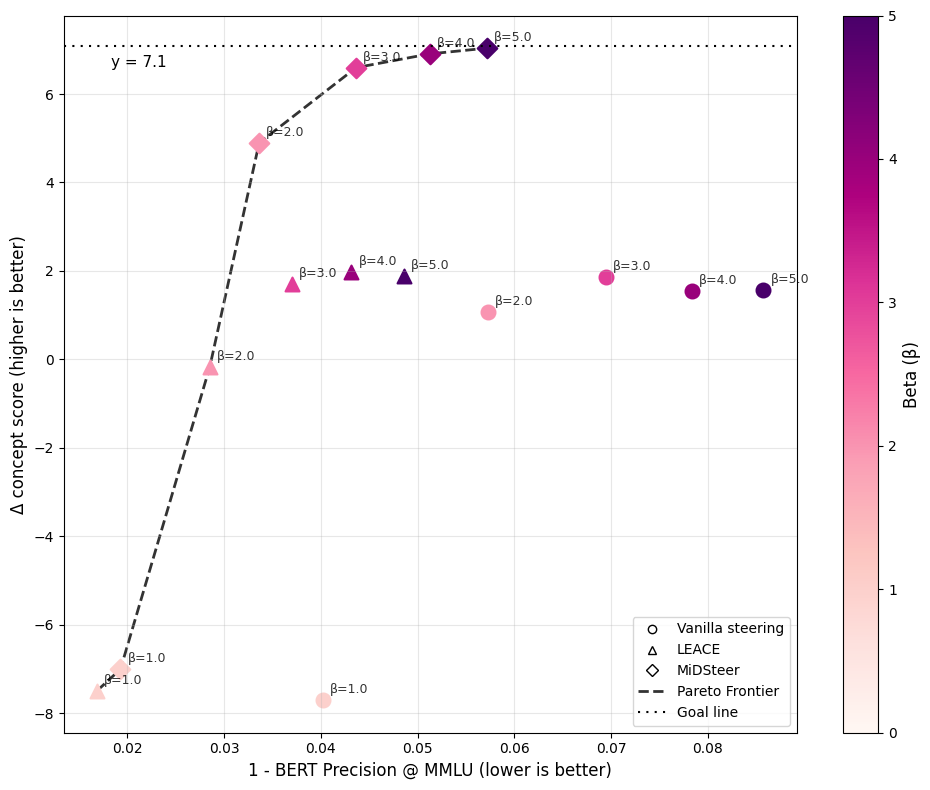

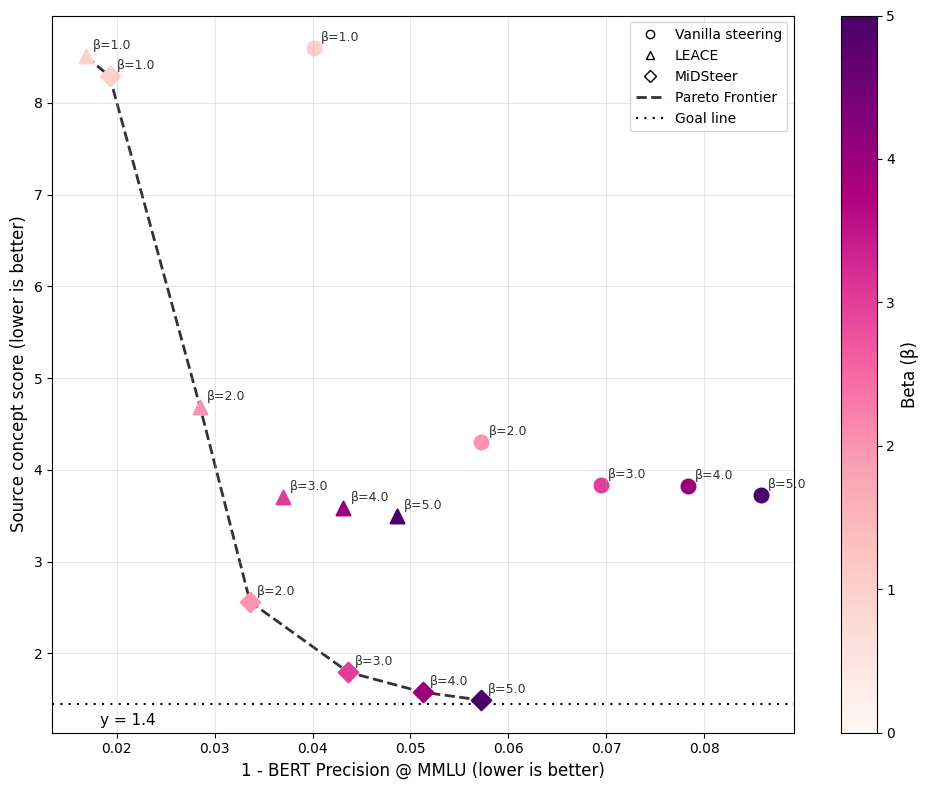

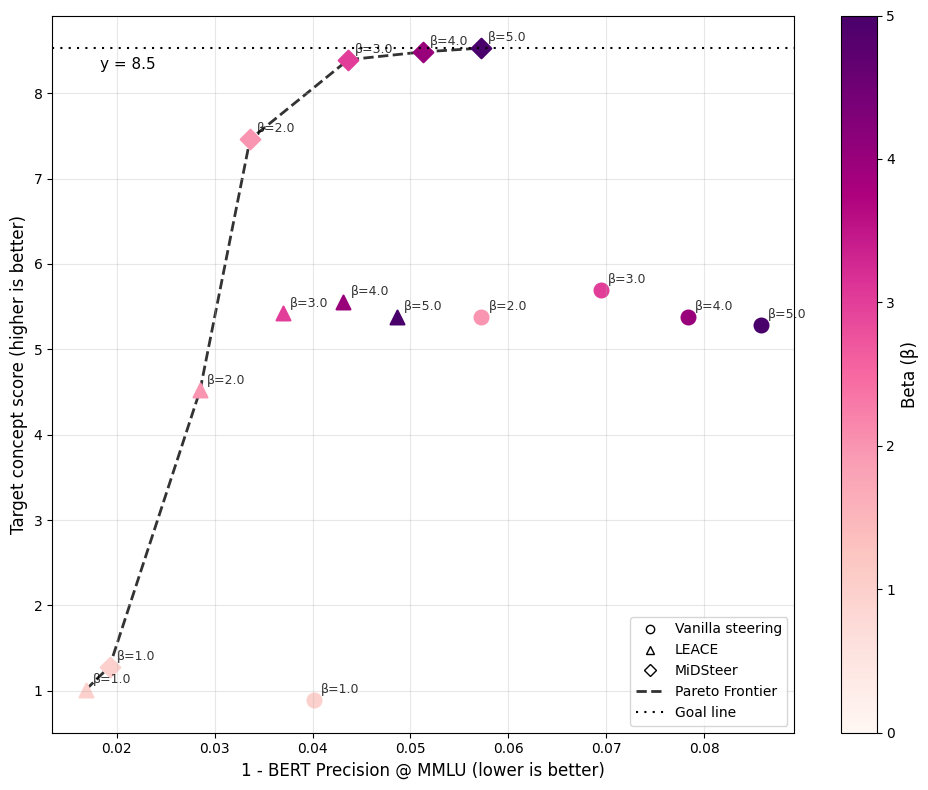

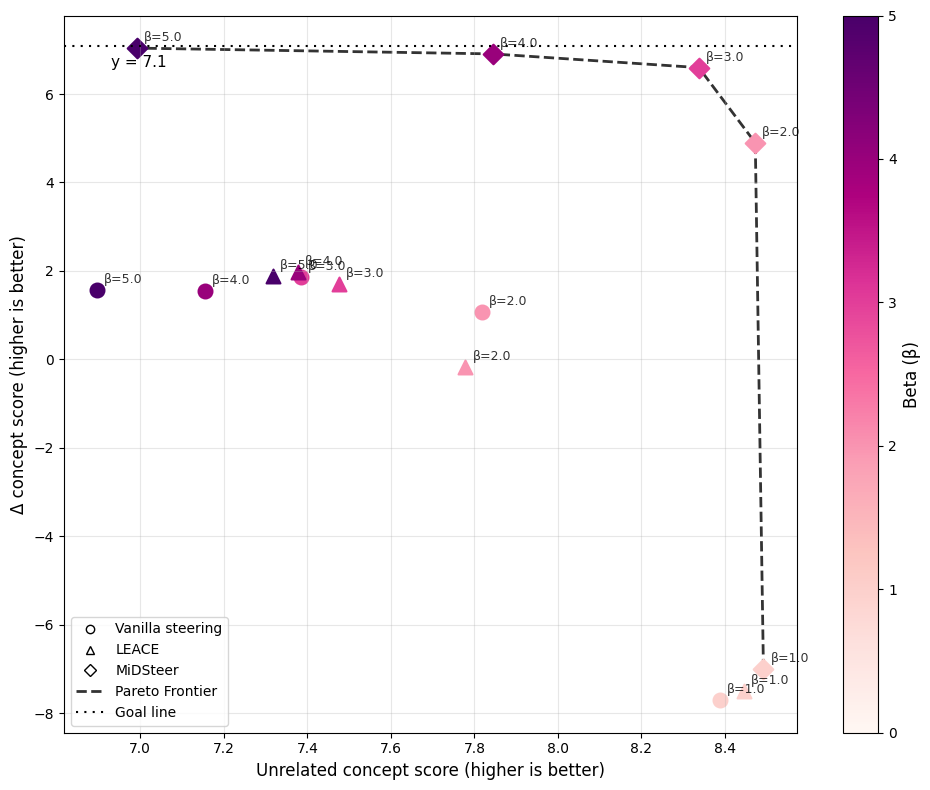

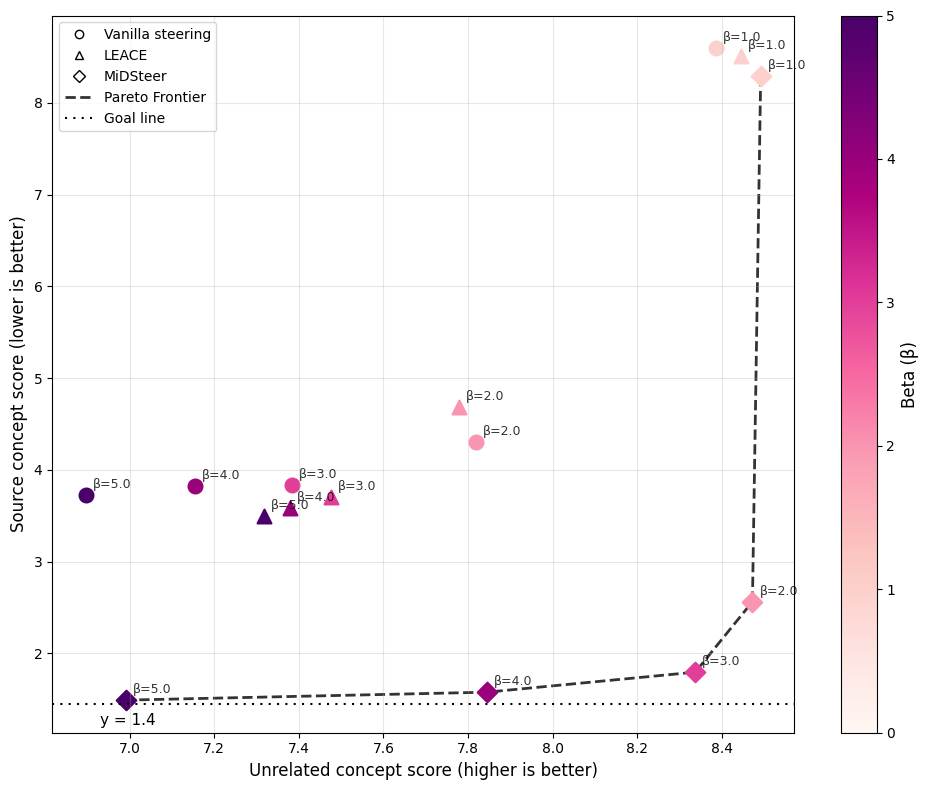

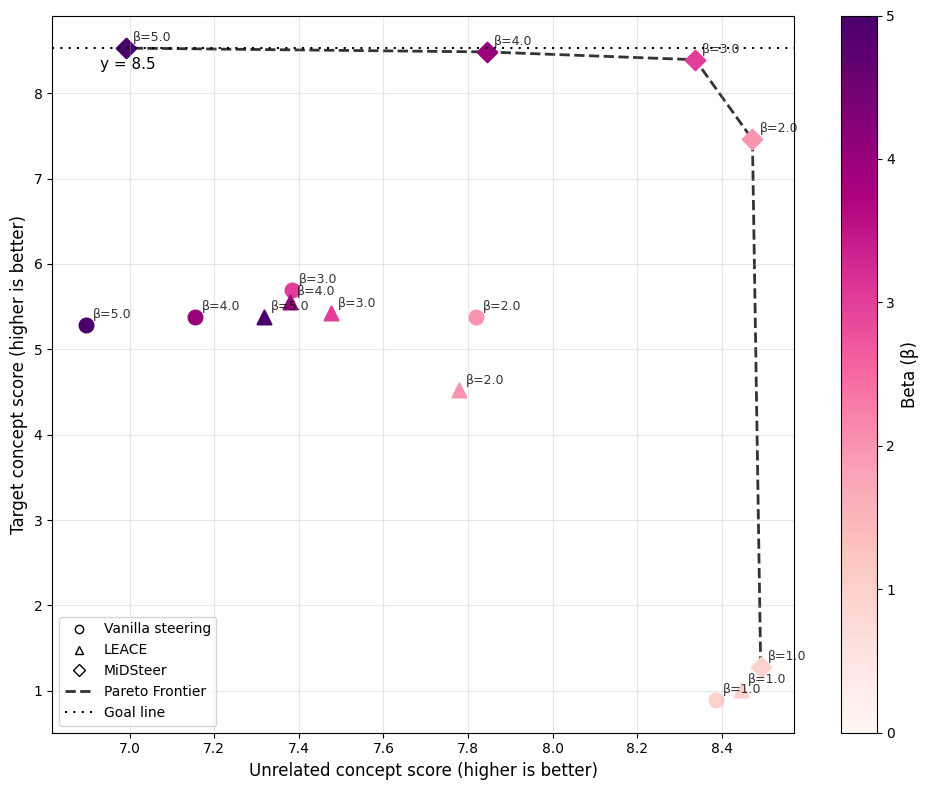

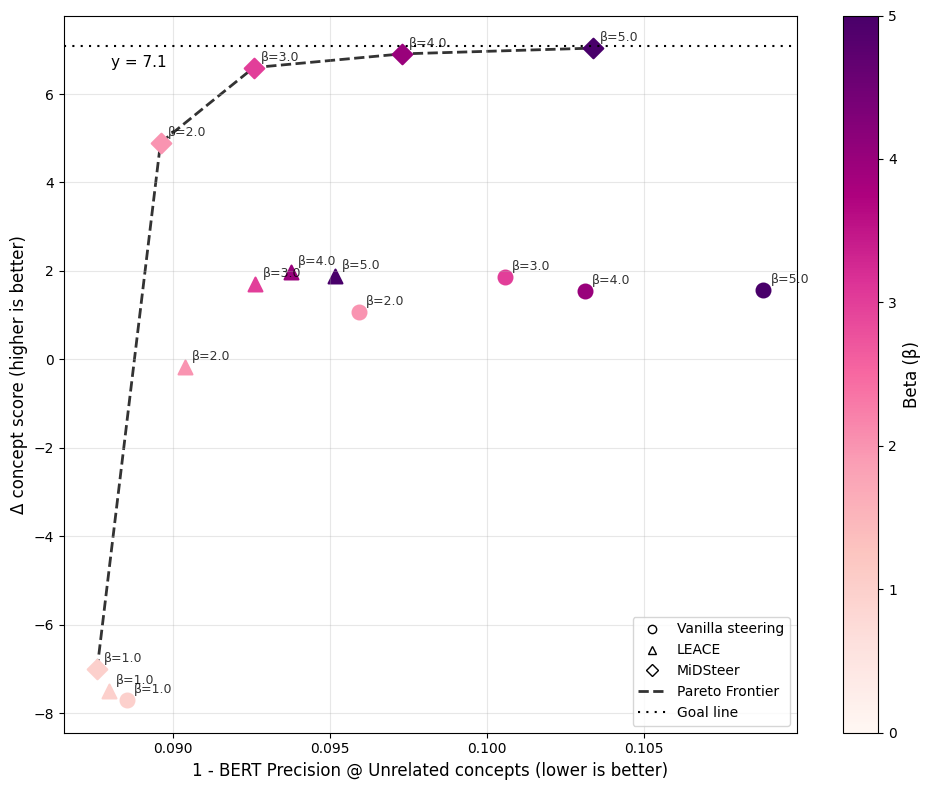

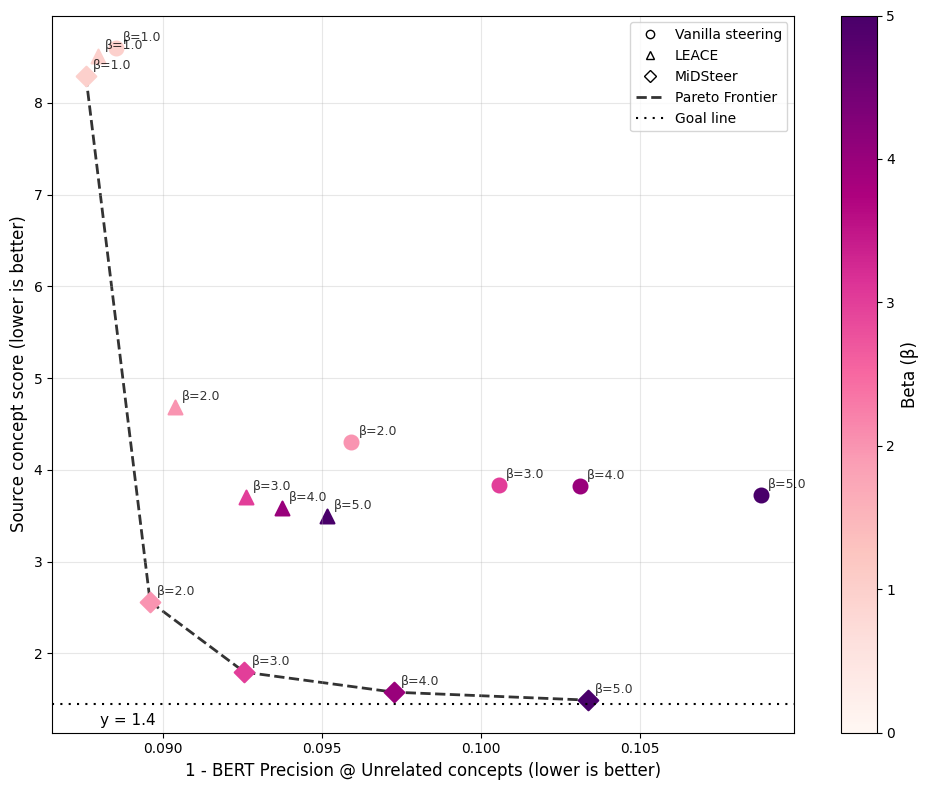

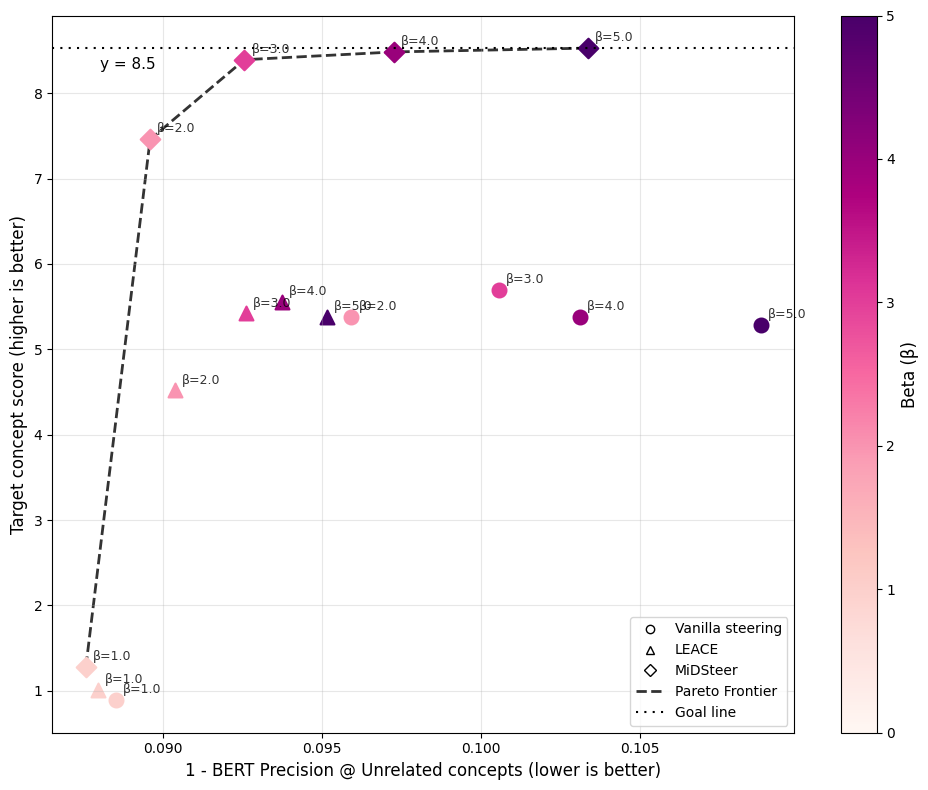

In [403]:
generate_flip_plots_with_different_axes(
    experiment_name='../exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_sa_fix_50k_last_no_renorm_no_clip_all_strengths/evaluation/',
    output_filename_template='../artefacts/pareto/llama2-7b-flip-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(10, 8),
)

##### Main paper

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

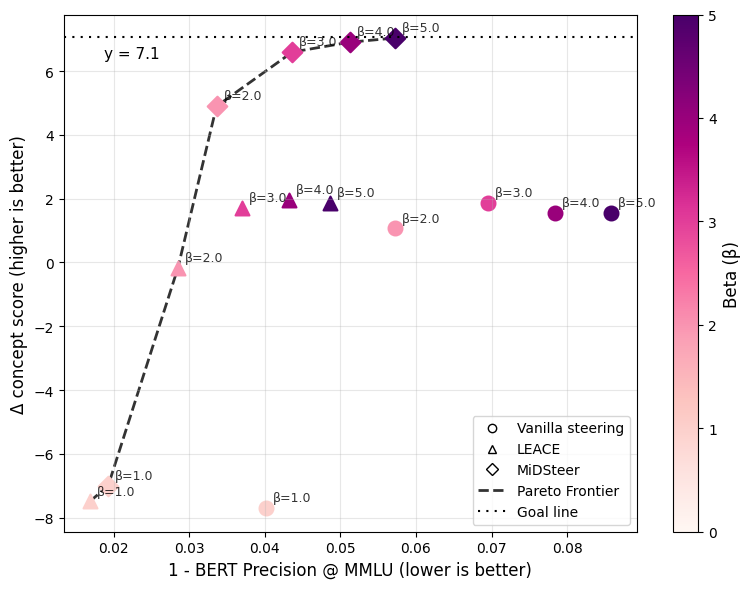

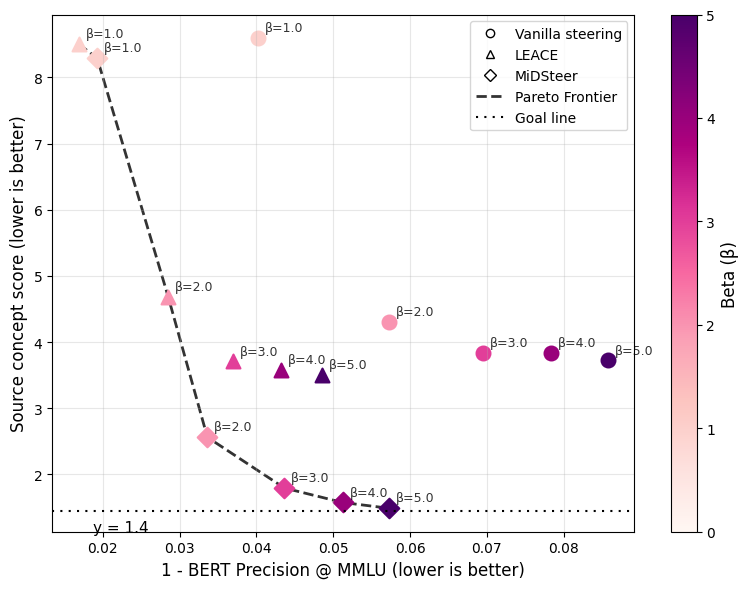

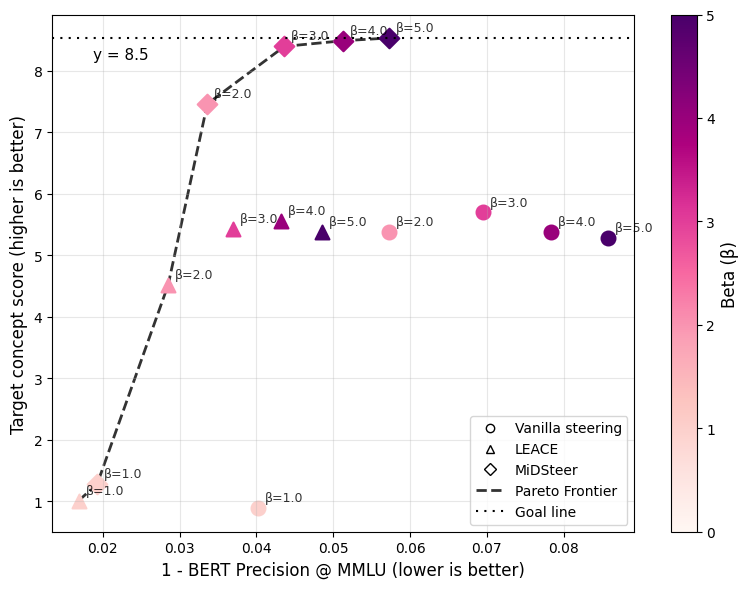

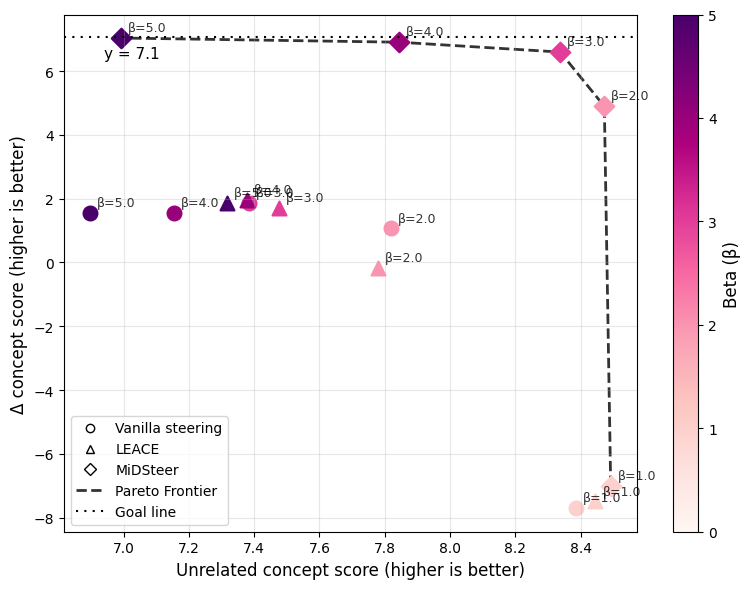

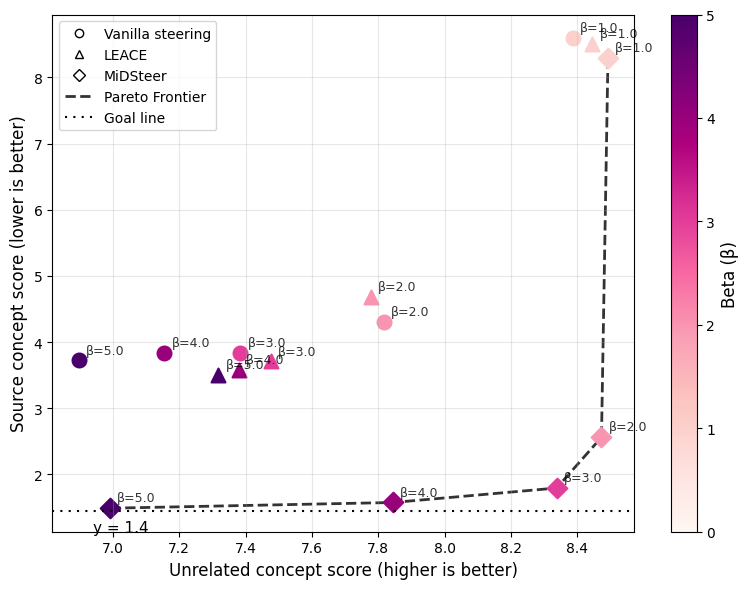

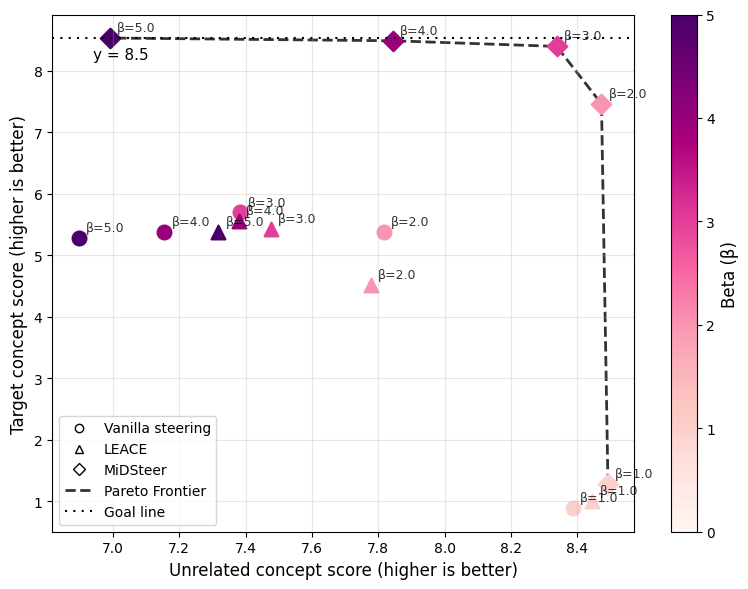

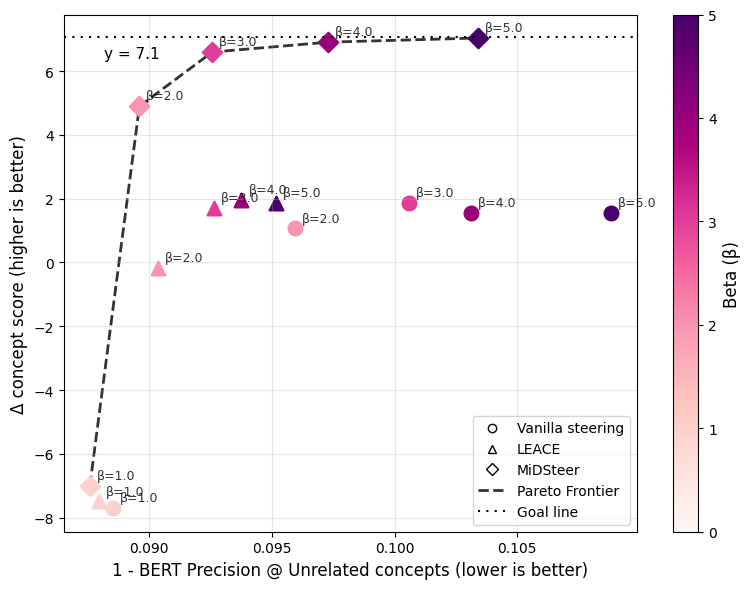

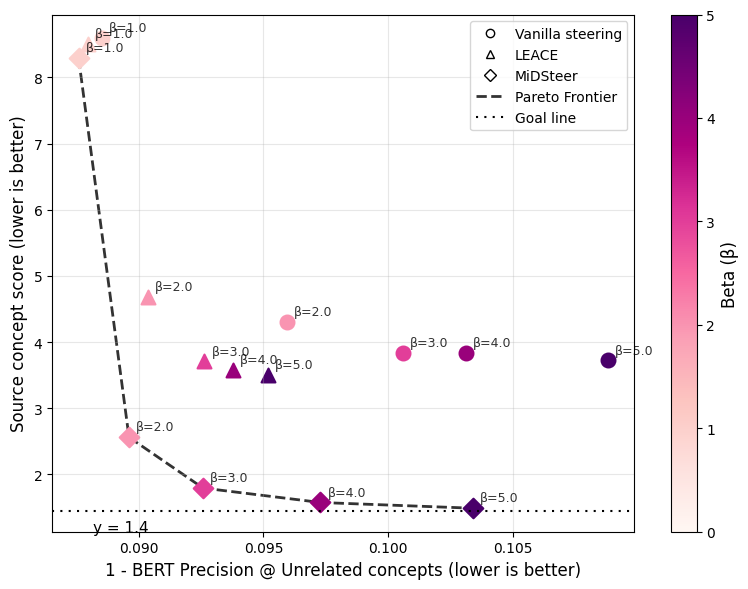

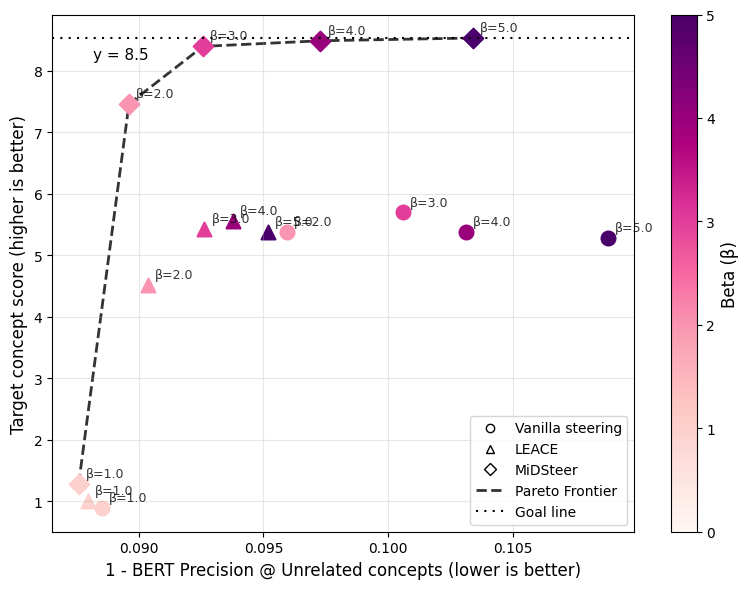

In [404]:
generate_flip_plots_with_different_axes(
    experiment_name='../exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_sa_fix_50k_last_no_renorm_no_clip_all_strengths/evaluation/',
    output_filename_template='../artefacts/main/llama2-7b-flip-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(8, 6),
)

#### Clip

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/2938810226.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

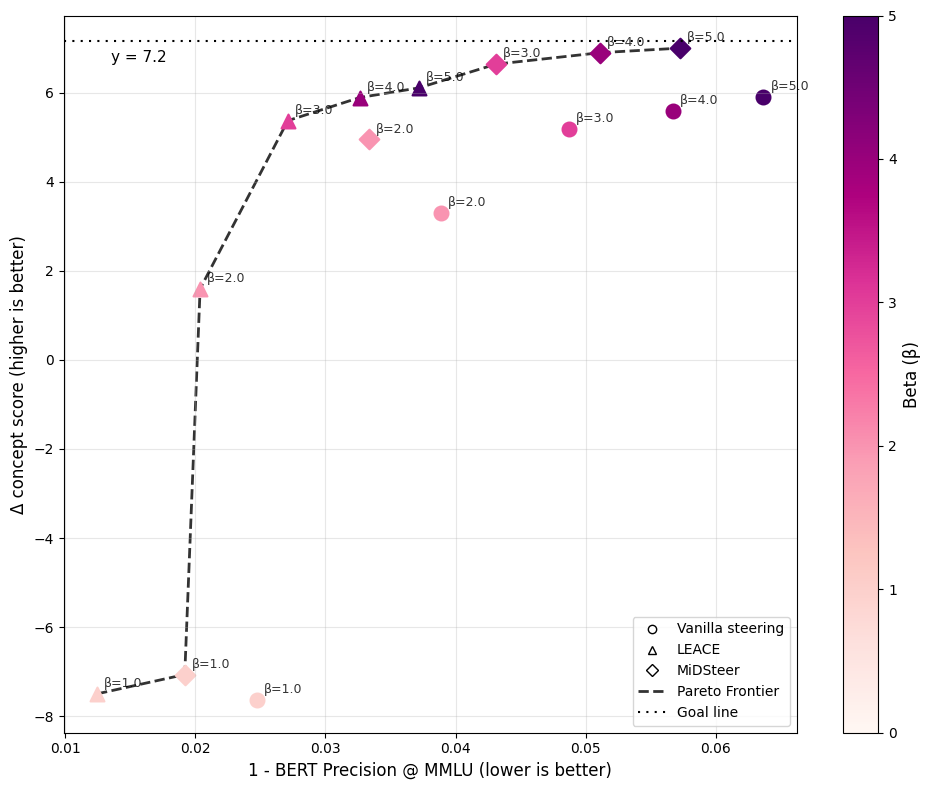

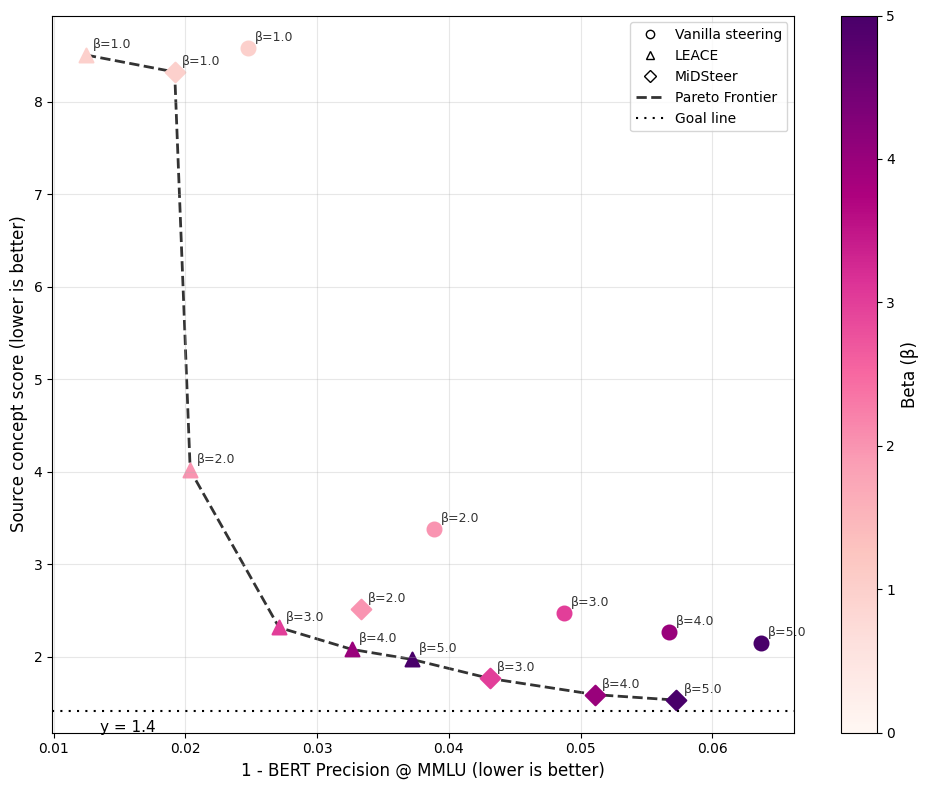

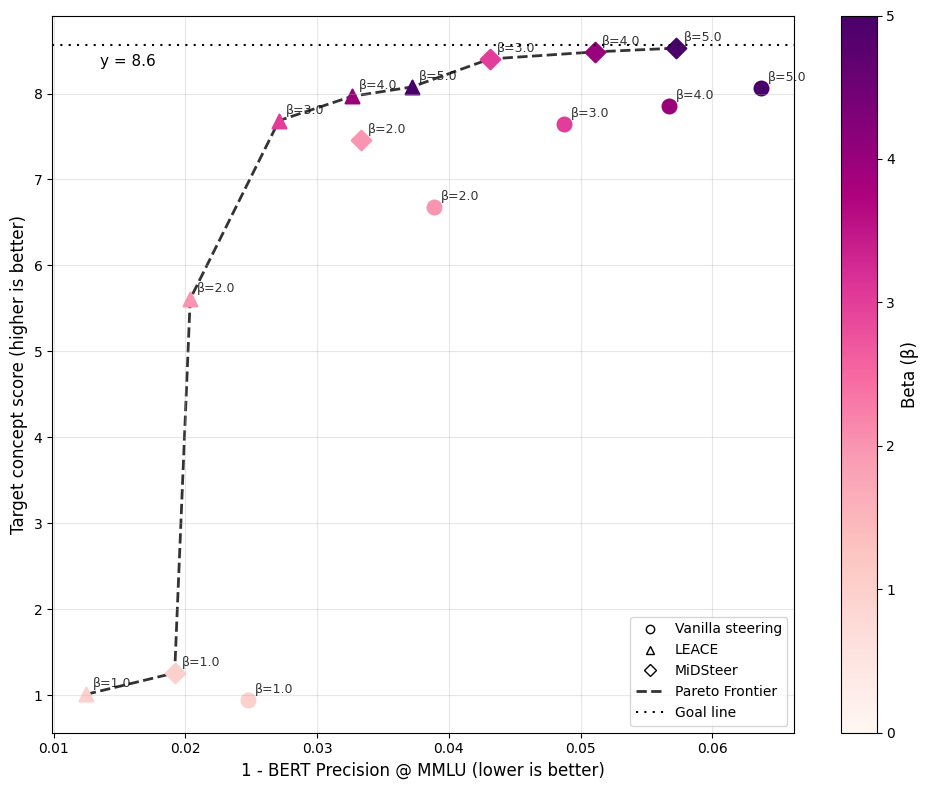

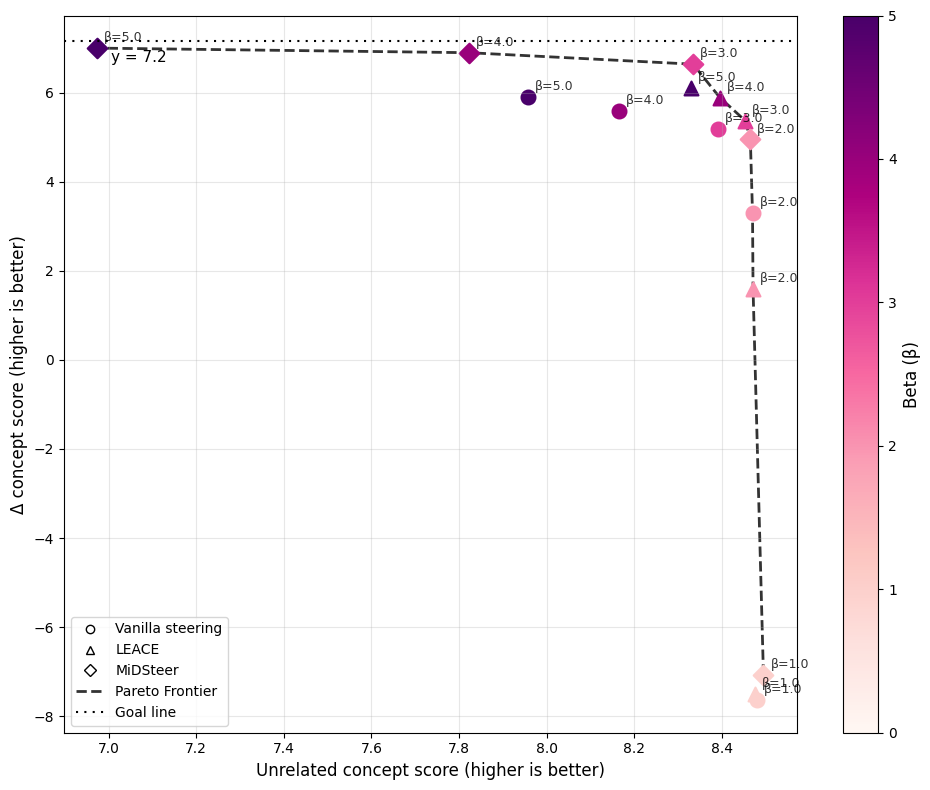

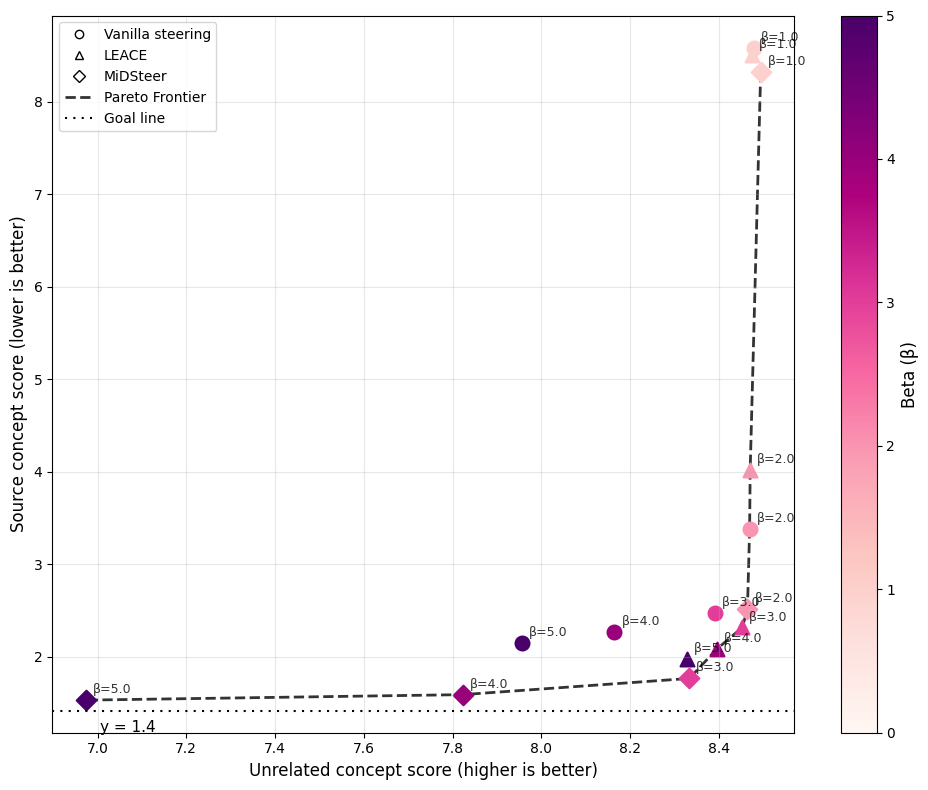

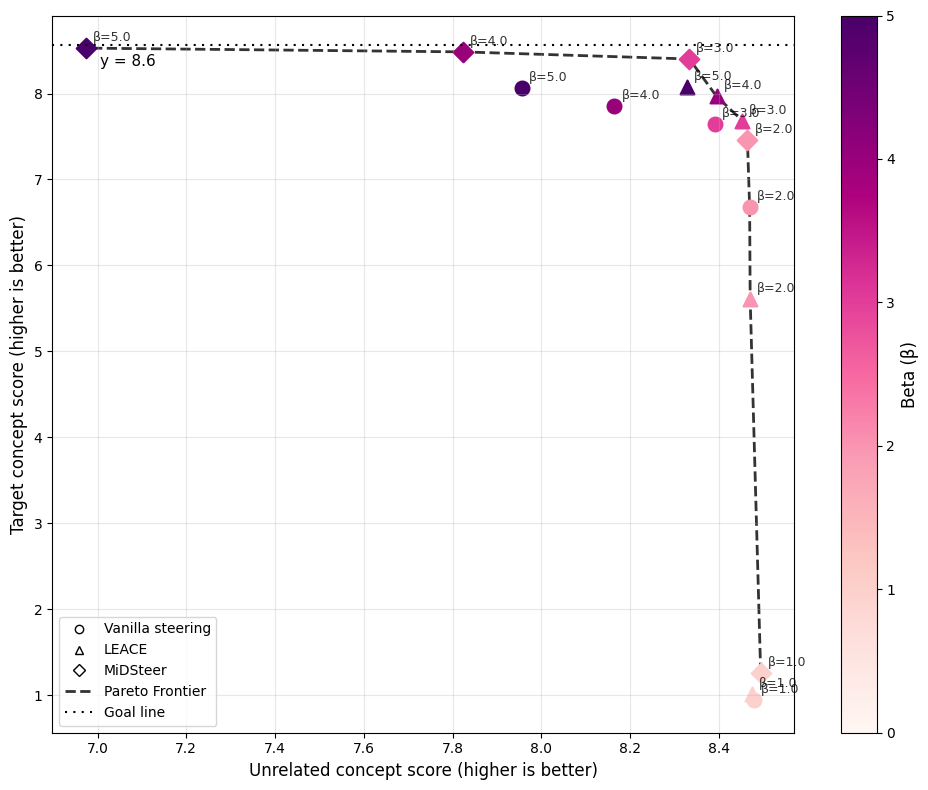

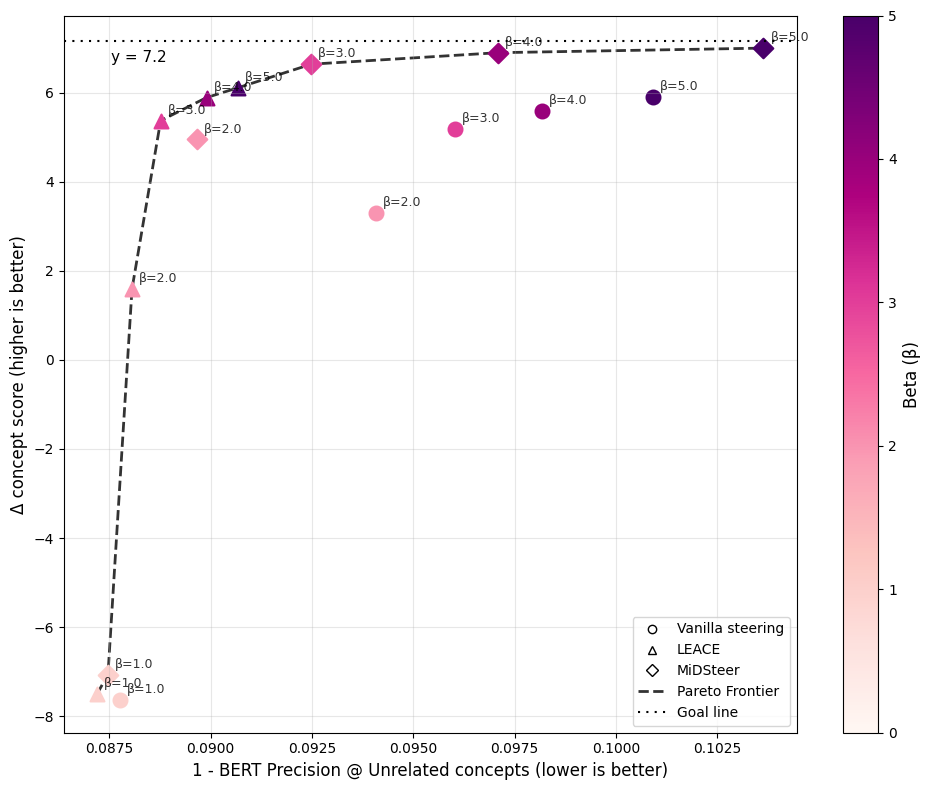

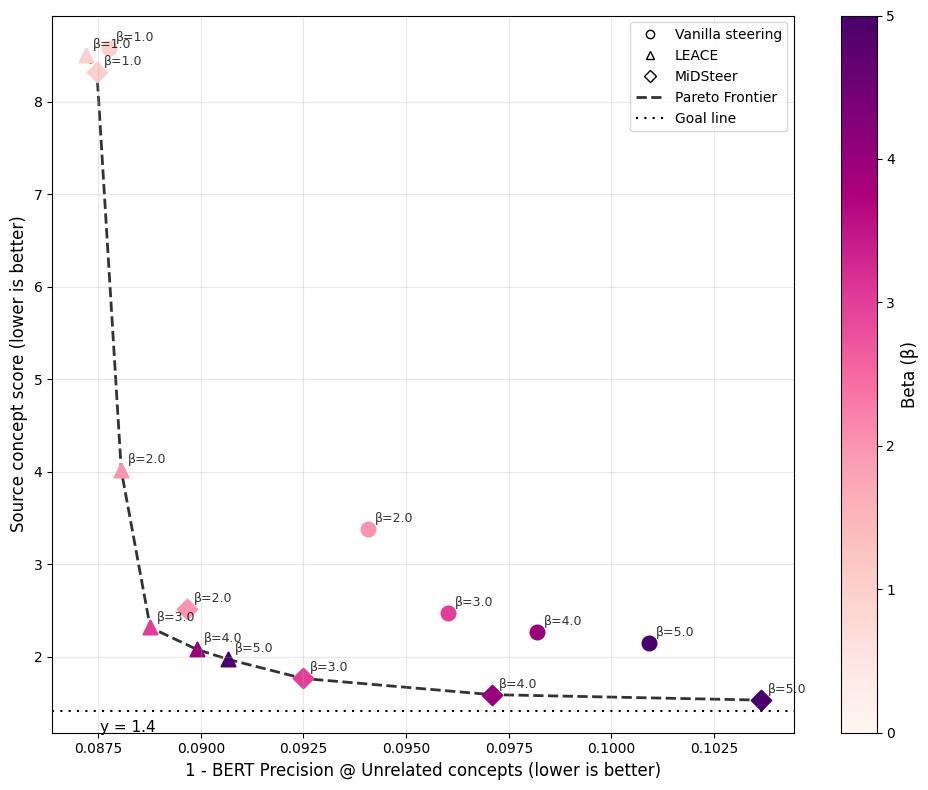

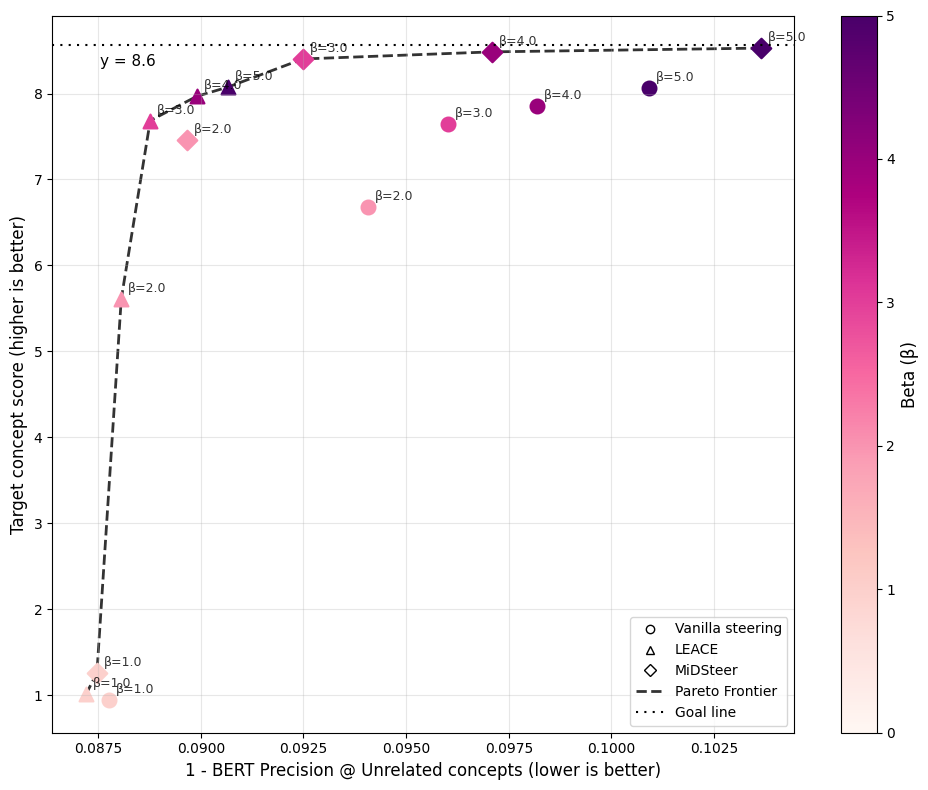

In [405]:
generate_flip_plots_with_different_axes(
    experiment_name='../exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_sa_fix_50k_last_no_renorm_clip_all_strengths/evaluation/',
    output_filename_template='../artefacts/pareto/llama2-7b-flip-clip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_LLM,
    figsize=(10, 8),
)

# Diffusion exps

In [320]:
def parse_diffusion_erase_experiment(path: str):
    fids = []
    clip_scores = []
    for subdir in os.listdir(path):
        if subdir == '.DS_Store':
            continue
        remove_concept, test_concept = subdir.split("_")
        fid = pd.read_csv(os.path.join(path, subdir, "fid.tsv"), sep="\t")
        clip_score = pd.read_csv(os.path.join(path, subdir, "clip_score.tsv"), sep="\t")
        clip_score['remove_concept'] = remove_concept.lower()
        clip_score['test_concept'] = test_concept.lower()
        clip_score['concept'] = clip_score['concept'].apply(str.lower)
        fid['remove_concept'] = remove_concept.lower()
        fid['test_concept'] = test_concept.lower()
        fids.append(fid)
        clip_scores.append(clip_score)
    fids = pd.concat(fids, axis=0)
    clip_scores = pd.concat(clip_scores, axis=0)

    fids['method_name'] = fids.apply(lambda x: x.method.split('-')[0], axis=1)
    fids['strength'] = fids.apply(lambda x: float(x.method.split('-')[1]), axis=1)
    fids = fids.drop(['method'], axis=1)

    
    clip_scores['method_name'] = clip_scores.apply(lambda x: x.method.split('-')[0], axis=1)
    clip_scores['strength'] = clip_scores.apply(lambda x: get_strength_or_none(x.method.split('-')), axis=1)
    clip_scores = clip_scores.drop(['method'], axis=1)

    return fids, clip_scores


def parse_diffusion_flip_experiment(path: str):
    fids = []
    clip_scores = []
    for subdir in os.listdir(path):
        if subdir in ('.DS_Store', '.ipynb_checkpoints'):
            continue
        other, test_concept = split_last(subdir, '__')
        source_concept, target_concept = split_first(other, '_to_')
        try:
            fid = pd.read_csv(os.path.join(path, subdir, "fid.tsv"), sep="\t")
        except pd.errors.EmptyDataError:
            print(f'Error reading file: {os.path.join(path, subdir, "fid.tsv")}')
            continue
        try:
            clip_score = pd.read_csv(os.path.join(path, subdir, "clip_score.tsv"), sep="\t")
        except pd.errors.EmptyDataError:
            print(f'Error reading file: {os.path.join(path, subdir, "clip_score.tsv")}')
            continue
        clip_score['source_concept'] = source_concept.lower()
        clip_score['target_concept'] = target_concept.lower()
        clip_score['test_concept'] = test_concept.lower()
        clip_score['concept'] = clip_score['concept'].apply(str.lower)
        fid['source_concept'] = source_concept.lower()
        fid['target_concept'] = target_concept.lower()
        fid['test_concept'] = test_concept.lower()
        fids.append(fid)
        clip_scores.append(clip_score)
    fids = pd.concat(fids, axis=0)
    clip_scores = pd.concat(clip_scores, axis=0)

    fids['method_name'] = fids.apply(lambda x: x.method.split('-')[0], axis=1)
    fids['strength'] = fids.apply(lambda x: float(x.method.split('-')[1]), axis=1)
    fids = fids.drop(['method'], axis=1)

    
    clip_scores['method_name'] = clip_scores.apply(lambda x: x.method.split('-')[0], axis=1)
    clip_scores['strength'] = clip_scores.apply(lambda x: get_strength_or_none(x.method.split('-')), axis=1)
    clip_scores = clip_scores.drop(['method'], axis=1)

    return fids, clip_scores



## Erasure

In [324]:
def produce_diffusion_erase_pareto_plot(
    experiment_name: str,
    x_axis: str,
    y_axis: str,
    output_filename: str | None = None,
    figsize=(12, 8),
):
    fid, clip_score = parse_diffusion_erase_experiment(
        experiment_name
    )
    
    data = (
        (
            fid
            .query("remove_concept != test_concept")
            .query("test_concept not in @IMPLICIT_CONCEPTS")
            .groupby(['method_name', 'strength'])
            .agg({'fid': 'mean'})
            .rename({'fid': 'unrelated_concept_fid'}, axis=1)
        ).join(
            clip_score
            .query("(concept == remove_concept) & (concept == test_concept)")
            .groupby(['method_name', 'strength'])
            .agg({'clip_score': 'mean'})
            .rename({'clip_score': 'erased_concept_clip_score'}, axis=1)
        ).join(
            clip_score
            .query("(test_concept != remove_concept) & (concept == test_concept)")
            .query("test_concept not in @IMPLICIT_CONCEPTS")
            .groupby(['method_name', 'strength'])
            .agg({'clip_score': 'mean'})
            .rename({'clip_score': 'unrelated_concept_clip_score'}, axis=1)
        )
        .reset_index()
        .query('strength <= 4')
    )
    
    plot_pareto_frontier(
        data=data,
        x_column=x_axis,
        y_column=y_axis,
    
        x_label=AXES[x_axis]['label'],
        y_label=AXES[y_axis]['label'],
        x_better=AXES[x_axis]['better'],
        y_better=AXES[y_axis]['better'],
        title='',
        output_fname=output_filename,
        erase_mode=True,
        figsize=figsize,
    )

In [325]:
X_AXES_MAPPING_DIFFUSION = {
    'unrelated_concept_clip_score': 'unrelated-cs',
    'unrelated_concept_fid': 'unrelated-fid',
}

def generate_erase_plots_with_different_axes_diffusion(
    experiment_name: str,
    output_filename_template: str,
    x_axes_mapping: dict[str, str],
    figsize=(12, 8),
):
    for x_axis, name in x_axes_mapping.items():
        produce_diffusion_erase_pareto_plot(
            experiment_name=experiment_name,
            y_axis='erased_concept_clip_score',
            x_axis=x_axis,
            output_filename=output_filename_template.format(name),
            figsize=figsize,
        )

### SDXL erasure

#### No clip

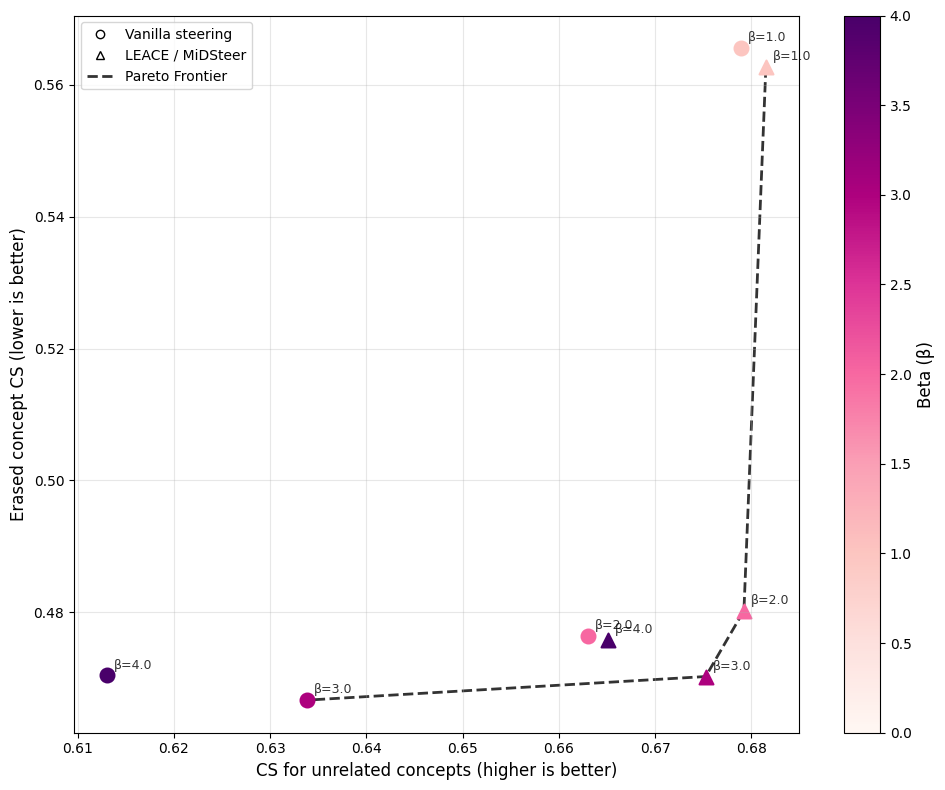

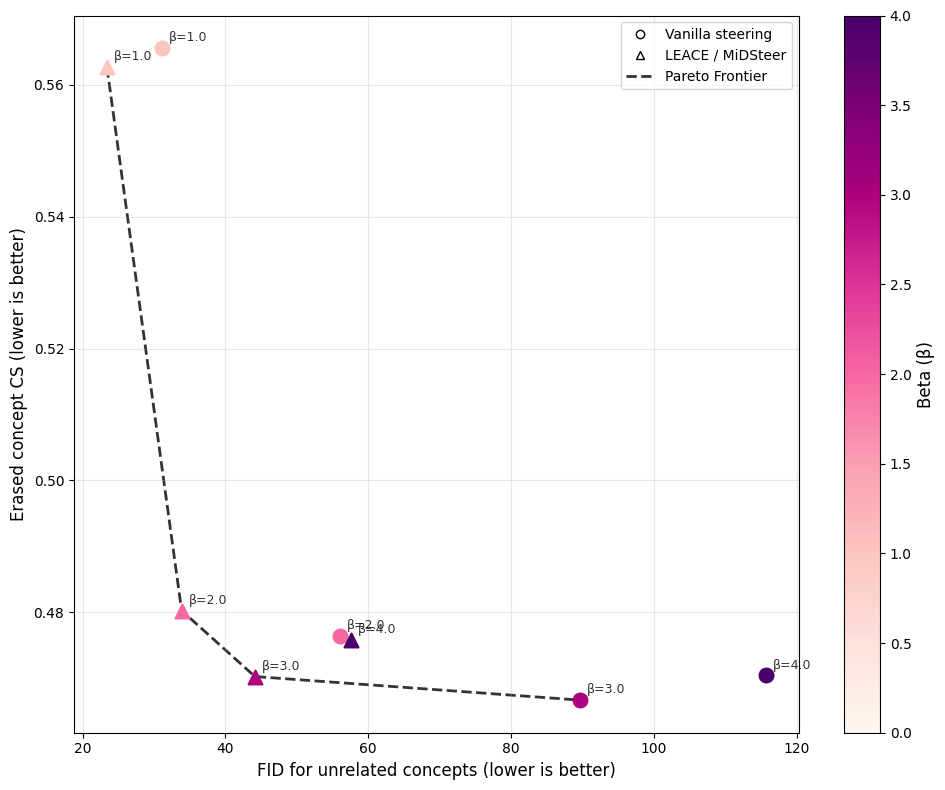

In [326]:
generate_erase_plots_with_different_axes_diffusion(
    experiment_name='../exp/results/sdxl/erasure_midsteer_diffusion_sdxl_50k/evaluation/concept_erasure/',
    output_filename_template='../artefacts/pareto/sdxl-erase-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_DIFFUSION,
    figsize=(10, 8),
)

##### Main paper

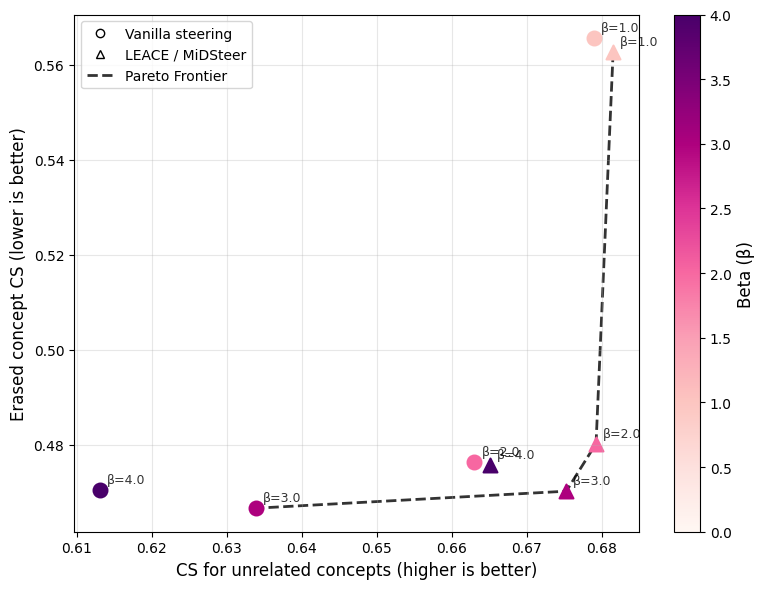

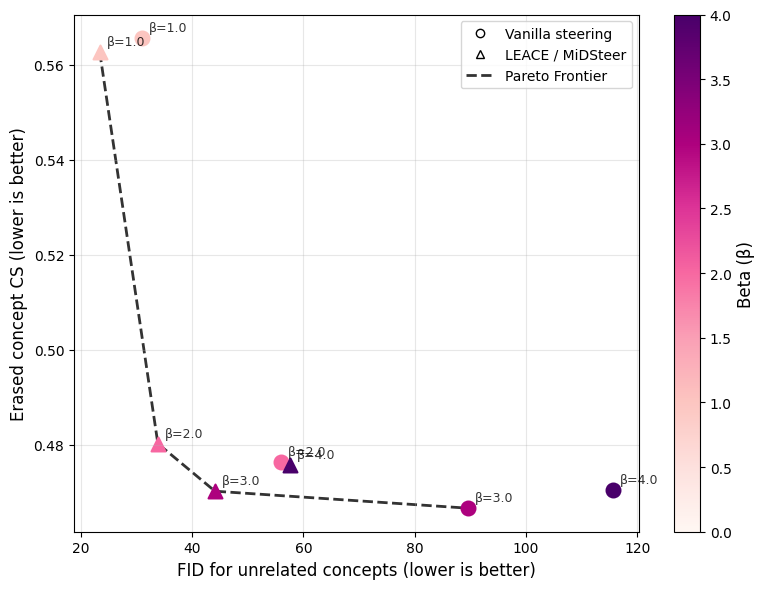

In [391]:
generate_erase_plots_with_different_axes_diffusion(
    experiment_name='../exp/results/sdxl/erasure_midsteer_diffusion_sdxl_50k/evaluation/concept_erasure/',
    output_filename_template='../artefacts/main/sdxl-erase-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_DIFFUSION,
    figsize=(8, 6),
)

#### Clip

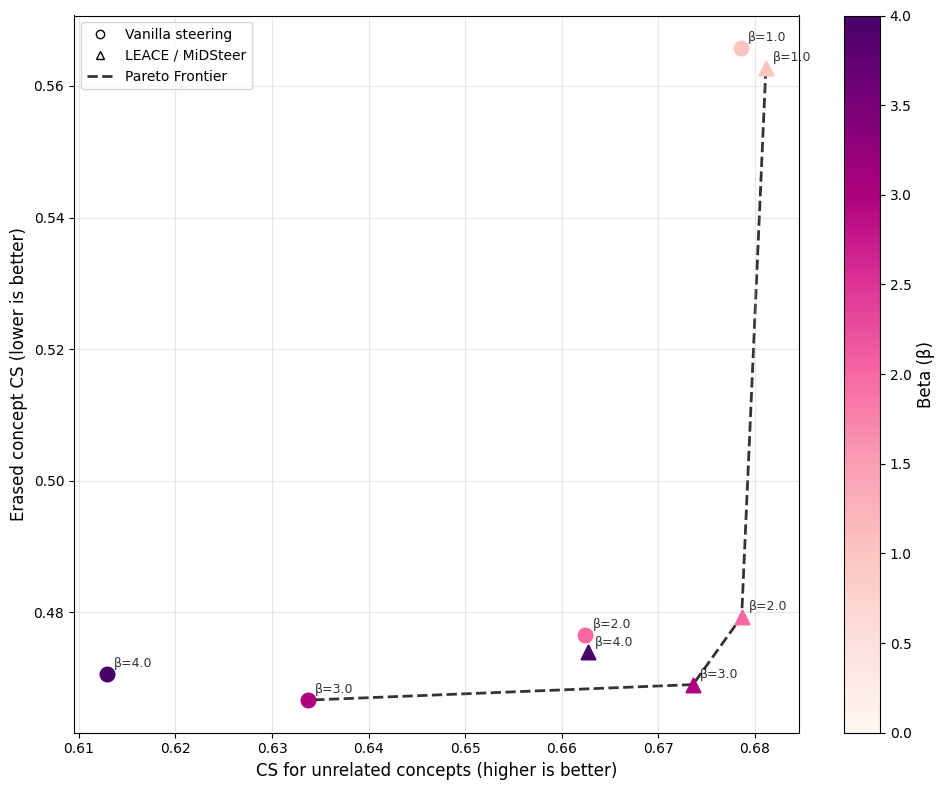

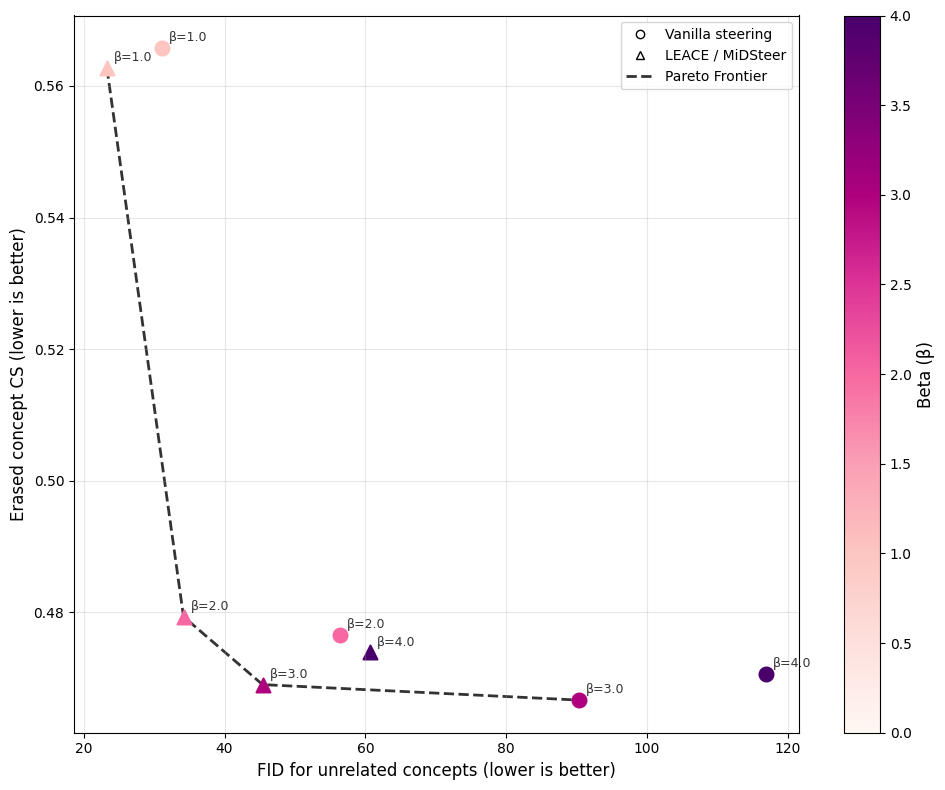

In [327]:
generate_erase_plots_with_different_axes_diffusion(
    experiment_name='../exp/results/sdxl/erasure_midsteer_diffusion_sdxl_50k_clip/evaluation/concept_erasure/',
    output_filename_template='../artefacts/pareto/sdxl-erase-clip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_DIFFUSION,
    figsize=(10, 8),
)

### Sana erasure

#### Clip

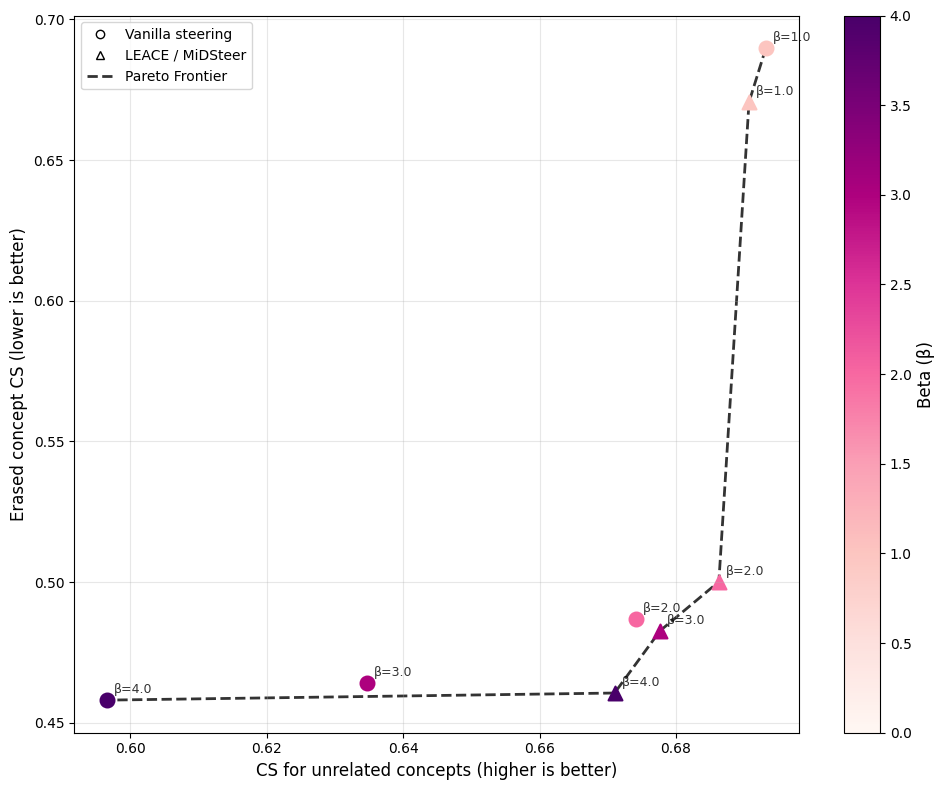

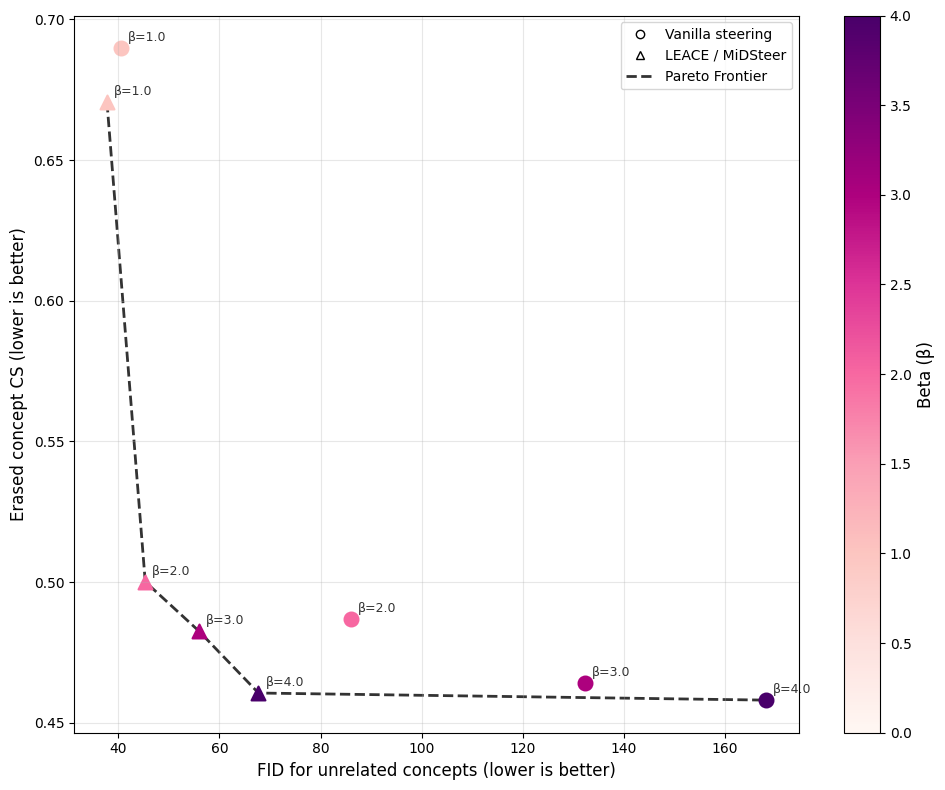

In [328]:
generate_erase_plots_with_different_axes_diffusion(
    experiment_name='../exp/results/sana/erasure_sana_50k_clip/evaluation/concept_erasure/',
    output_filename_template='../artefacts/pareto/sana-erase-clip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_DIFFUSION,
    figsize=(10, 8),
)

#### No clip

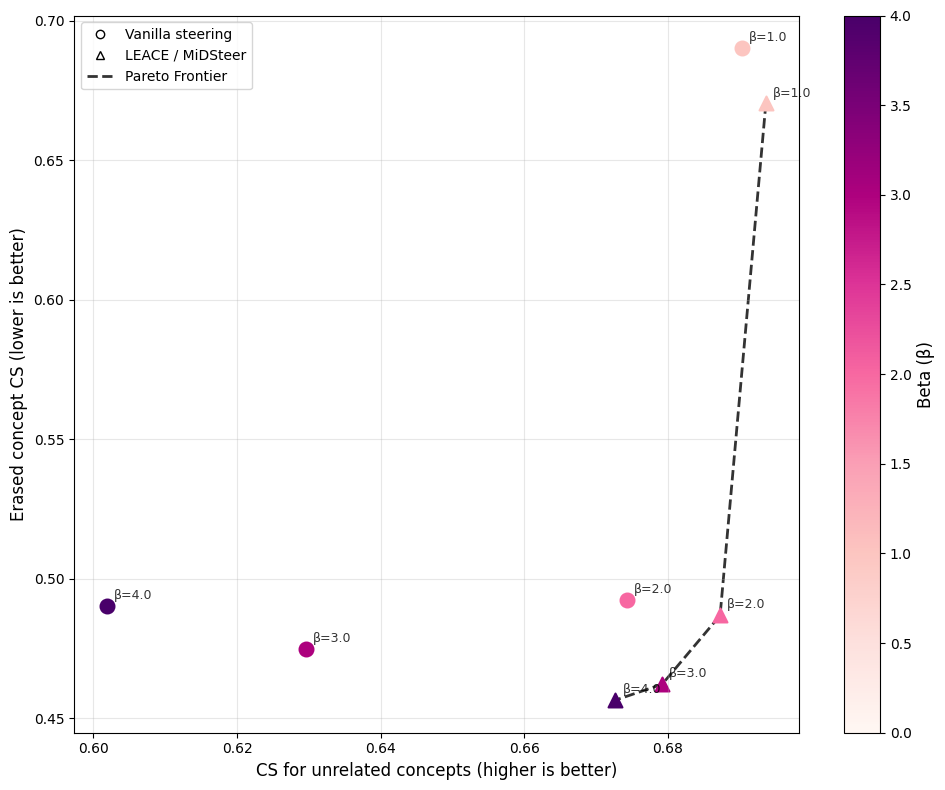

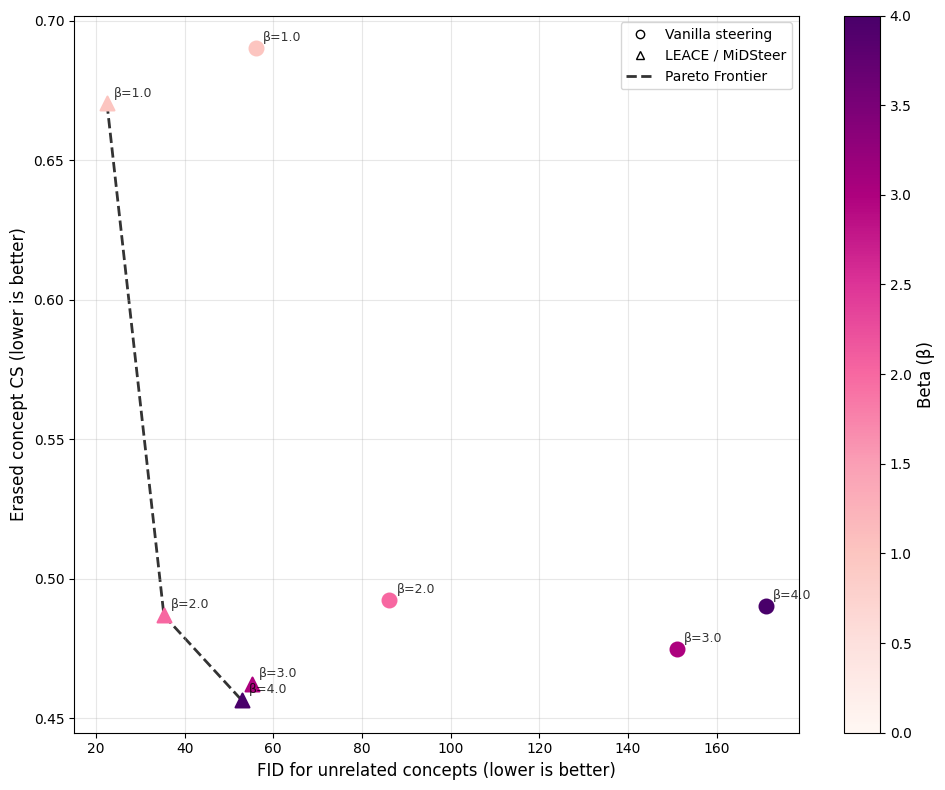

In [329]:
generate_erase_plots_with_different_axes_diffusion(
    experiment_name='../exp/results/sana/erasure_sana_50k/evaluation/concept_erasure/',
    output_filename_template='../artefacts/pareto/sana-erase-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_DIFFUSION,
    figsize=(10, 8),
)

### Flipping

In [406]:
def produce_diffusion_flip_pareto_plot(
    experiment_name: str,
    x_axis: str,
    y_axis: str,
    output_filename: str | None = None,
    figsize=(12, 8),
):
    
    fid, clip_score = parse_diffusion_flip_experiment(
        experiment_name
    )
    scs = (clip_score
            .query("method_name == 'orig'")
            .query("test_concept == target_concept & concept == source_concept")
            .agg({'clip_score': 'mean'}))
    tcs = (clip_score
            .query("method_name == 'orig'")
            .query("test_concept == target_concept & concept == target_concept")
            .agg({'clip_score': 'mean'}))

    if y_axis == 'delta_clip_score':
        goal = (tcs - scs)[0]
    elif y_axis == 'source_clip_score':
        goal = scs[0]
    elif y_axis == 'target_clip_score':
        goal = tcs[0]
    
    data = (
        (
            fid
            .query("source_concept != test_concept")
            .query("test_concept not in @IMPLICIT_CONCEPTS")
            .groupby(['method_name', 'strength'])
            .agg({'fid': 'mean'})
            .rename({'fid': 'unrelated_concept_fid'}, axis=1)
        ).join(
            clip_score
            .query("(concept == target_concept) & (source_concept == test_concept)")
            .groupby(['method_name', 'strength'])
            .agg({'clip_score': 'mean'})
            .rename({'clip_score': 'target_clip_score'}, axis=1)
        ).join(
            clip_score
            .query("(concept == source_concept) & (source_concept == test_concept)")
            .groupby(['method_name', 'strength'])
            .agg({'clip_score': 'mean'})
            .rename({'clip_score': 'source_clip_score'}, axis=1)
        ).join(
            clip_score
            .query("(concept == test_concept) & (source_concept != test_concept)")
            .query("test_concept not in @IMPLICIT_CONCEPTS")
            .groupby(['method_name', 'strength'])
            .agg({'clip_score': 'mean'})
            .rename({'clip_score': 'unrelated_concept_clip_score'}, axis=1)
        )
        .reset_index()
        .assign(delta_clip_score=lambda x: x.target_clip_score - x.source_clip_score)
    )
    
    
    plot_pareto_frontier(
        data=data,
        x_column=x_axis,
        y_column=y_axis,
    
        x_label=AXES[x_axis]['label'],
        y_label=AXES[y_axis]['label'],
        x_better=AXES[x_axis]['better'],
        y_better=AXES[y_axis]['better'],
        title='',
        y_goal=goal,
        output_fname=output_filename,
        figsize=figsize,
    )

In [407]:
def generate_flip_plots_with_different_axes_diffusion(
    experiment_name: str,
    output_filename_template: str,
    x_axes_mapping: dict[str, str],
    figsize=(12, 8),
):
    for x_axis, name in x_axes_mapping.items():
        produce_diffusion_flip_pareto_plot(
            experiment_name=experiment_name,
            y_axis='delta_clip_score',
            x_axis=x_axis,
            output_filename=output_filename_template.format(name),
            figsize=figsize,
        )
        produce_diffusion_flip_pareto_plot(
            experiment_name=experiment_name,
            y_axis='source_clip_score',
            x_axis=x_axis,
            output_filename=output_filename_template.format(name + "-scs"),
            figsize=figsize,
        )
        produce_diffusion_flip_pareto_plot(
            experiment_name=experiment_name,
            y_axis='target_clip_score',
            x_axis=x_axis,
            output_filename=output_filename_template.format(name + "-tcs"),
            figsize=figsize,
        )

### SDXL flip

#### No clip

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

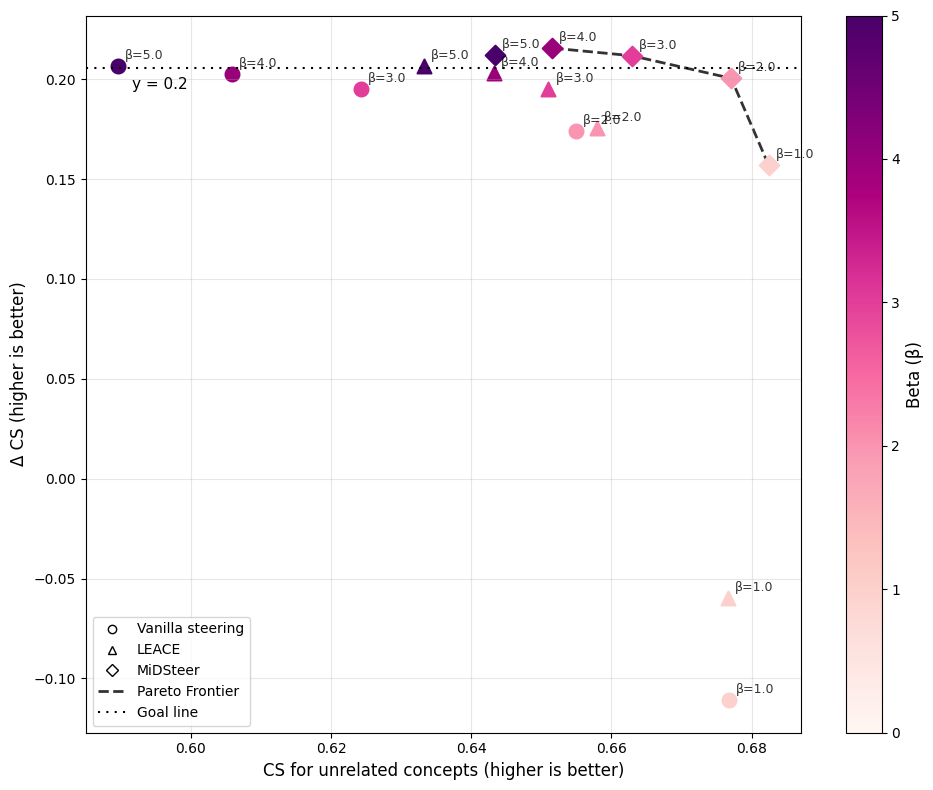

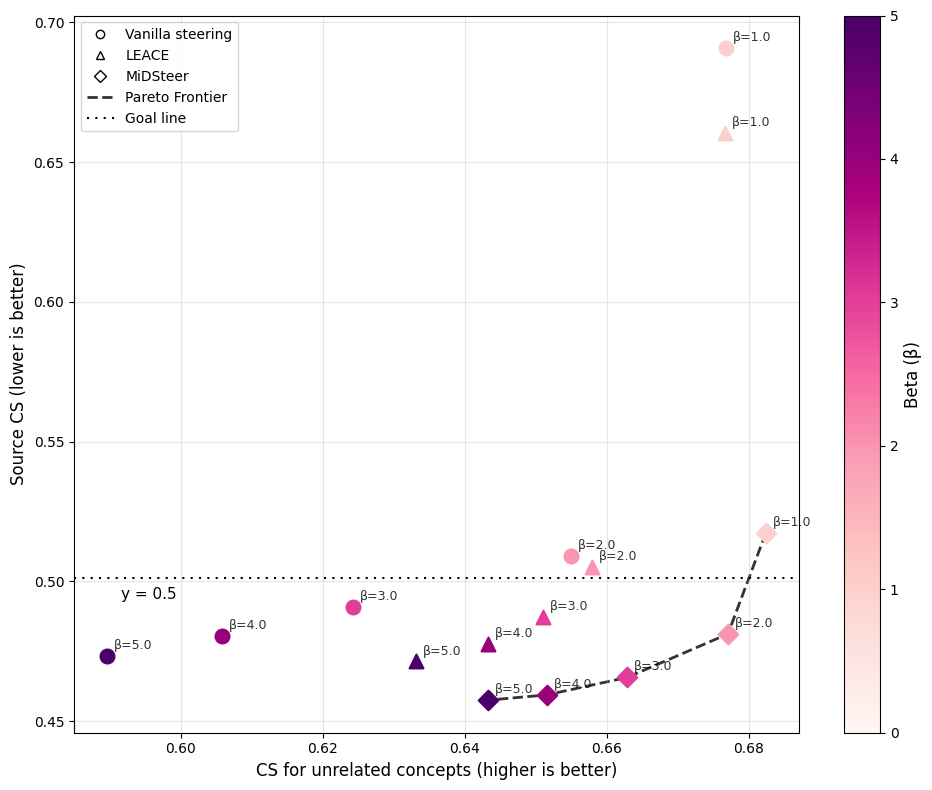

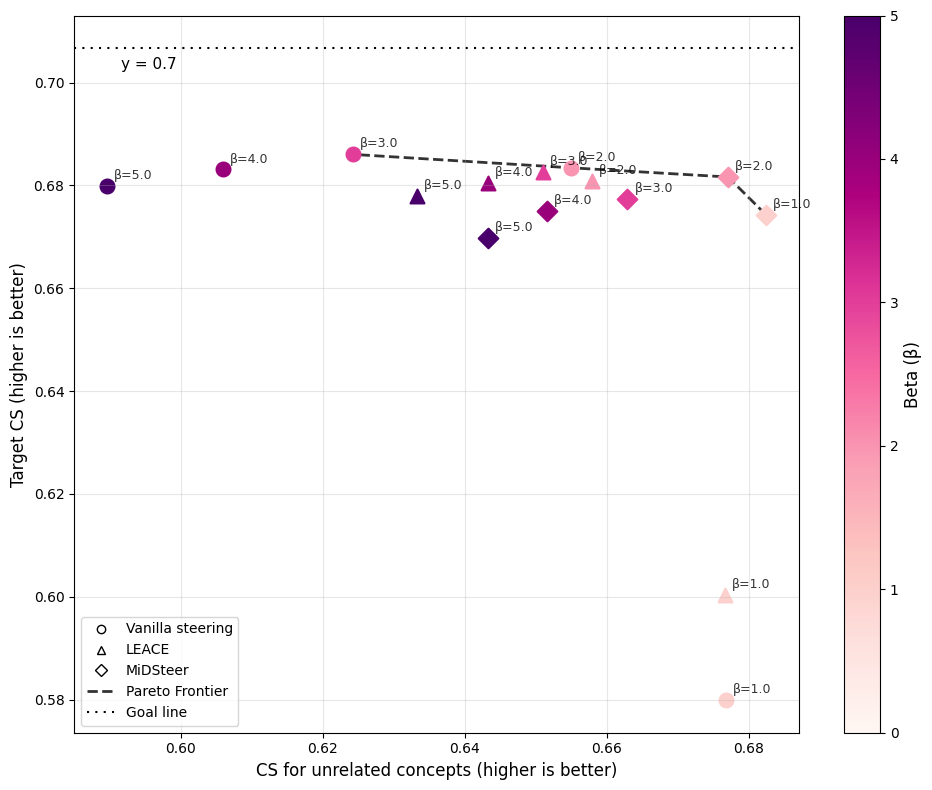

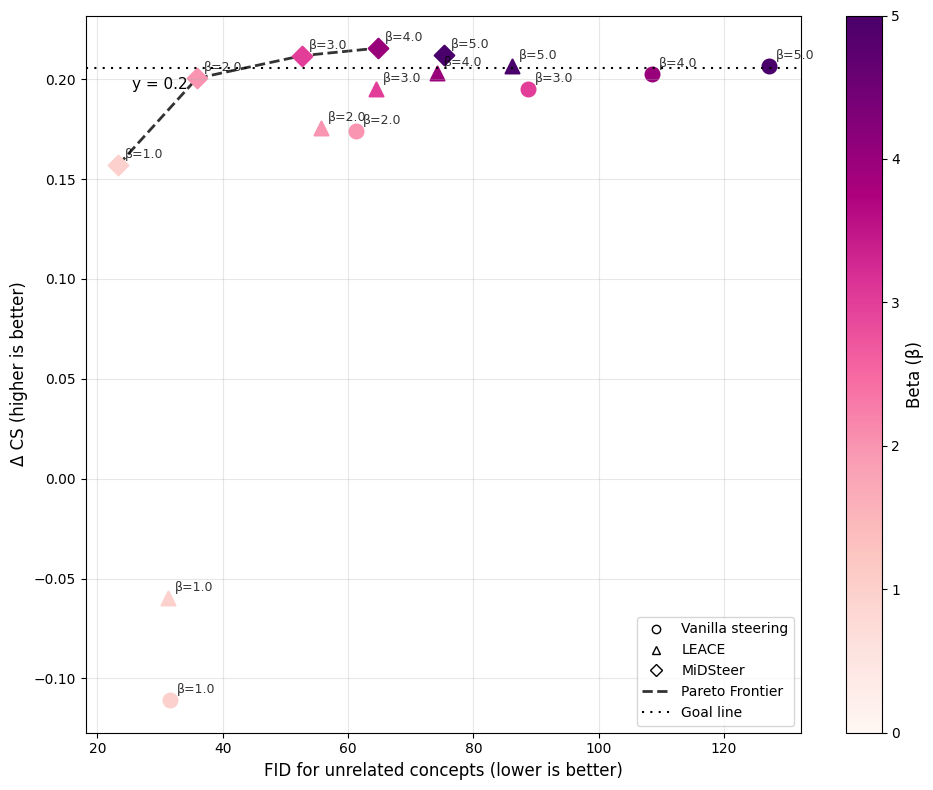

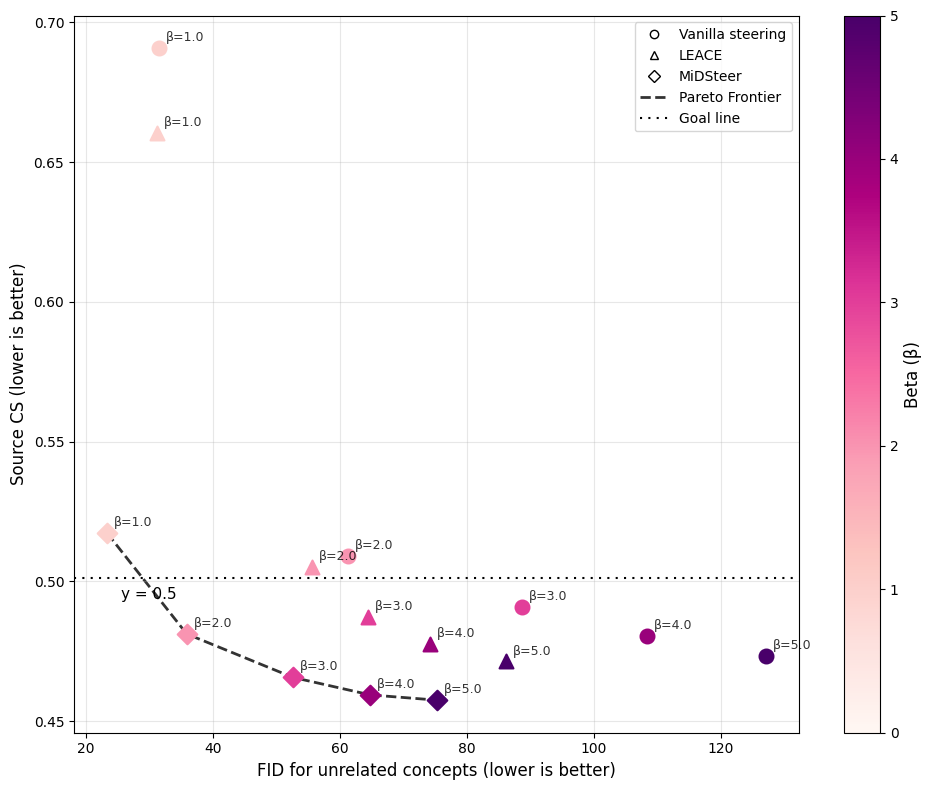

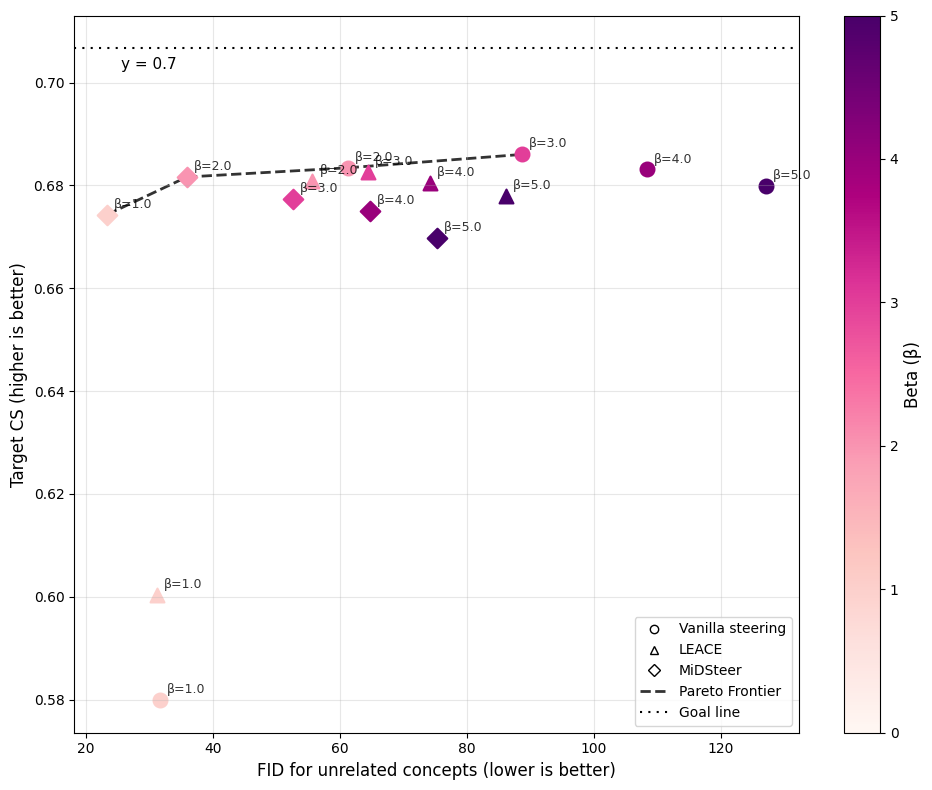

In [408]:
generate_flip_plots_with_different_axes_diffusion(
    experiment_name='../exp/results/sdxl/flipping_midsteer_diffusion_sdxl_50k/evaluation/concept_translation/',
    output_filename_template='../artefacts/pareto/sdxl-flip-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_DIFFUSION,
    figsize=(10, 8),
)

##### Main paper

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

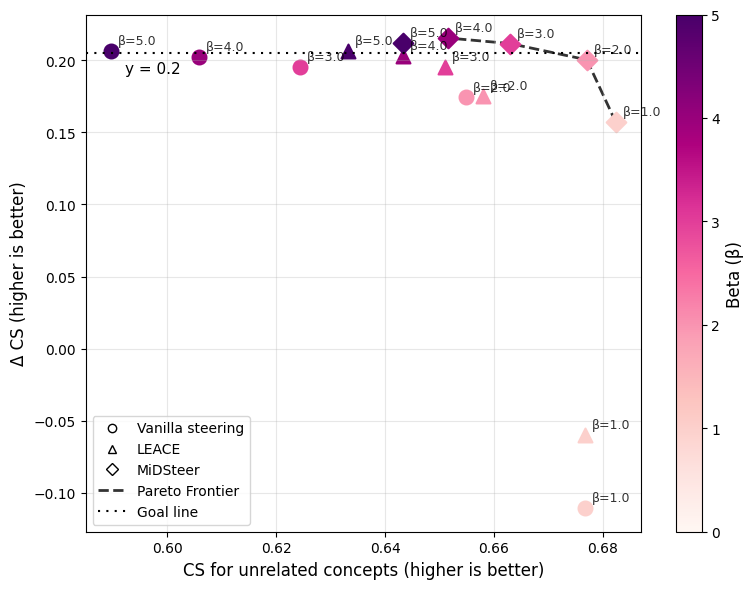

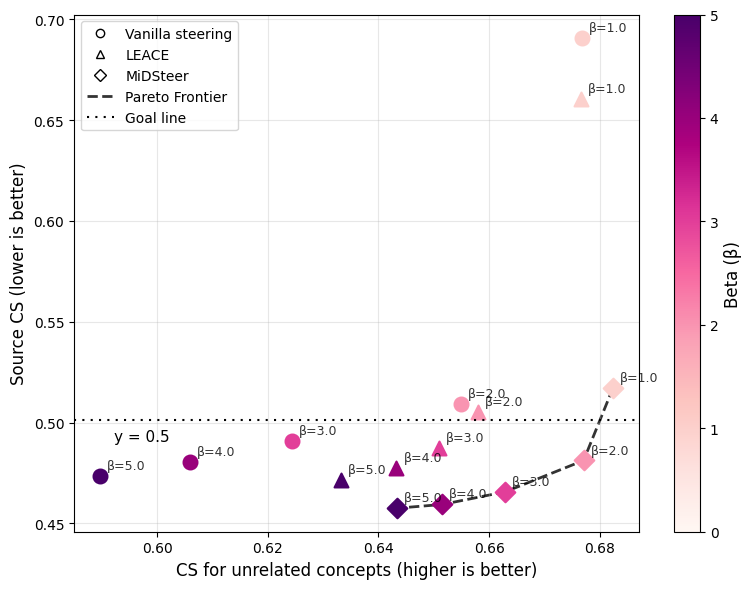

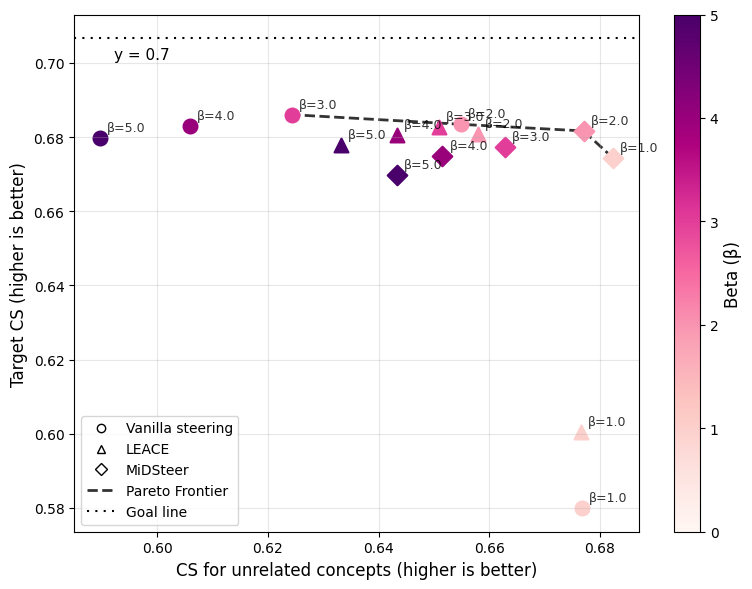

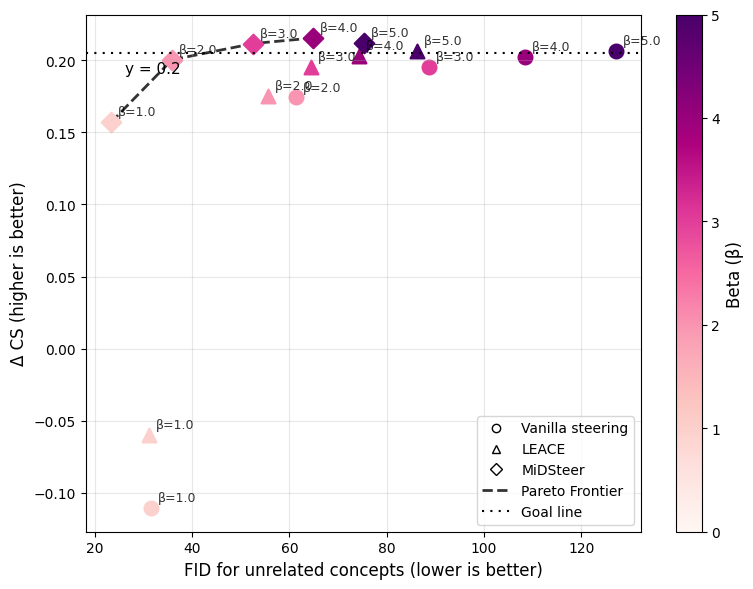

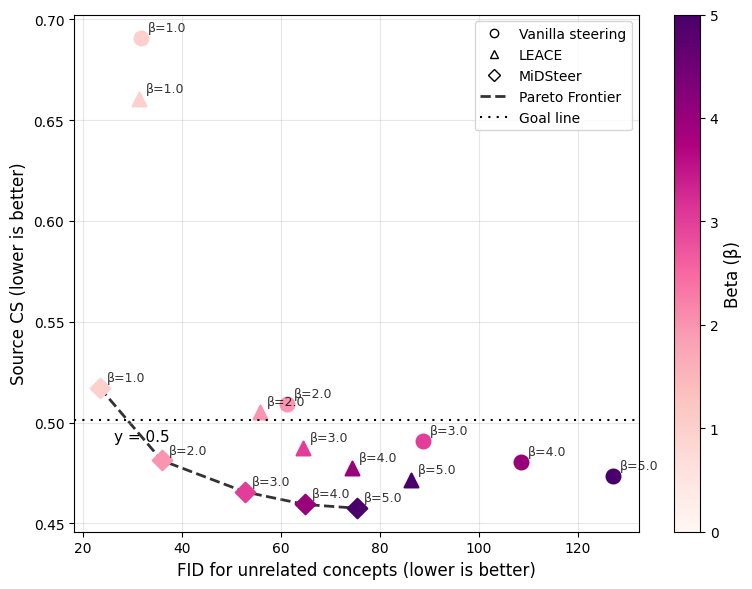

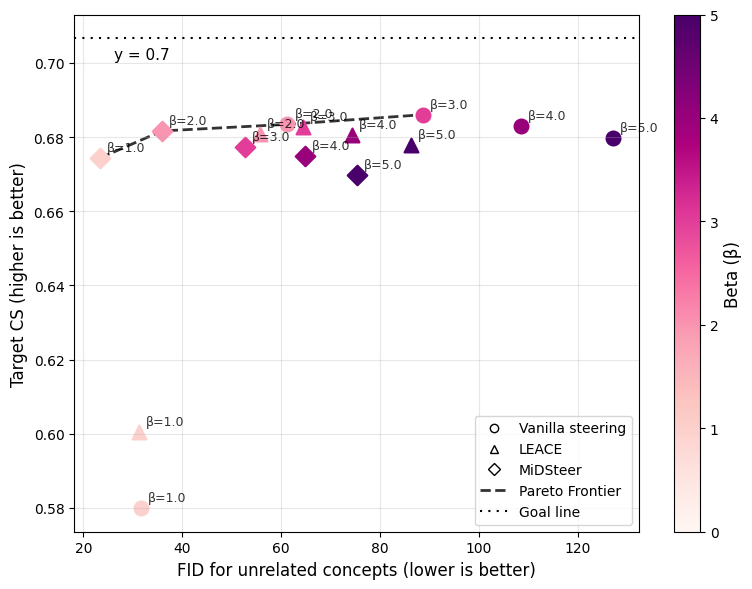

In [409]:
generate_flip_plots_with_different_axes_diffusion(
    experiment_name='../exp/results/sdxl/flipping_midsteer_diffusion_sdxl_50k/evaluation/concept_translation/',
    output_filename_template='../artefacts/main/sdxl-flip-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_DIFFUSION,
    figsize=(8, 6),
)

#### Clip

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

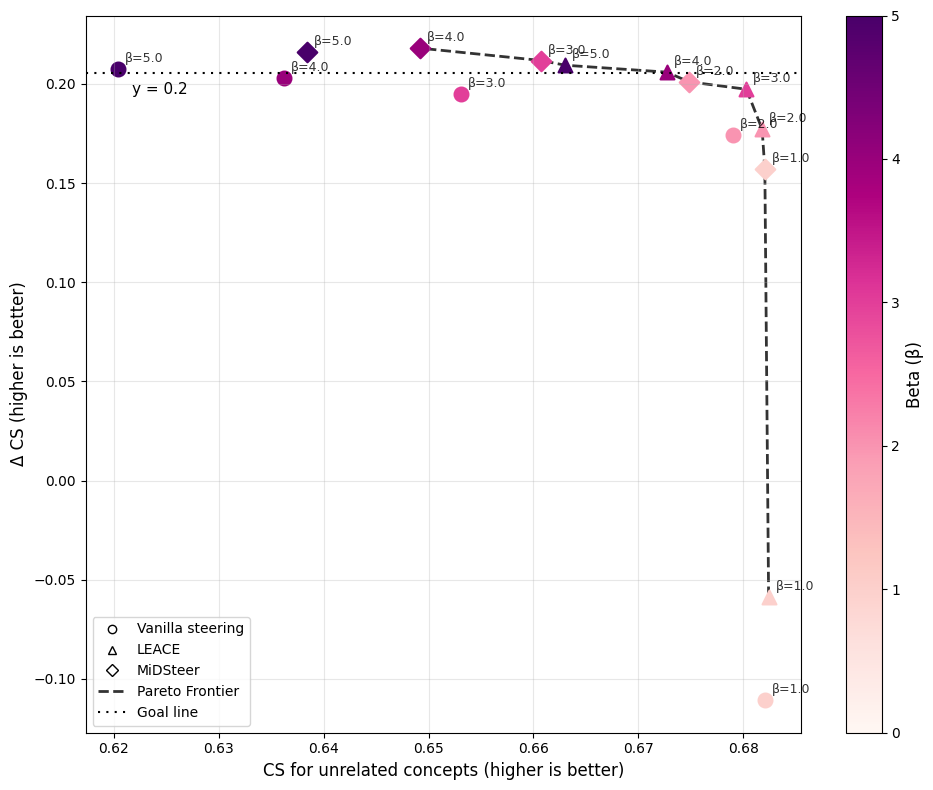

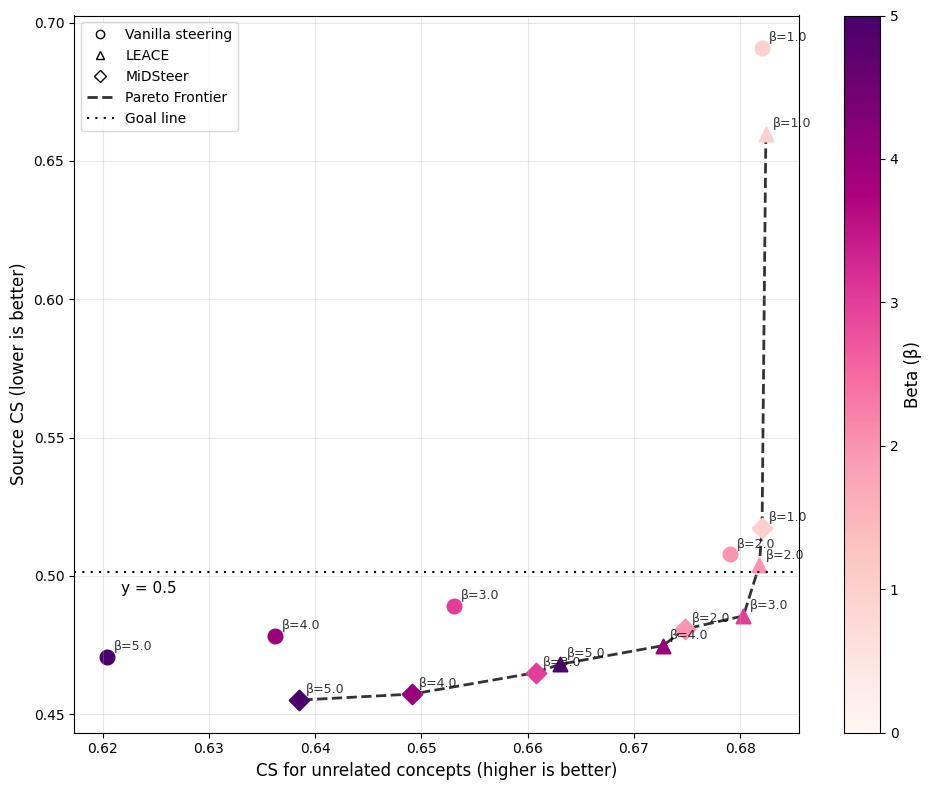

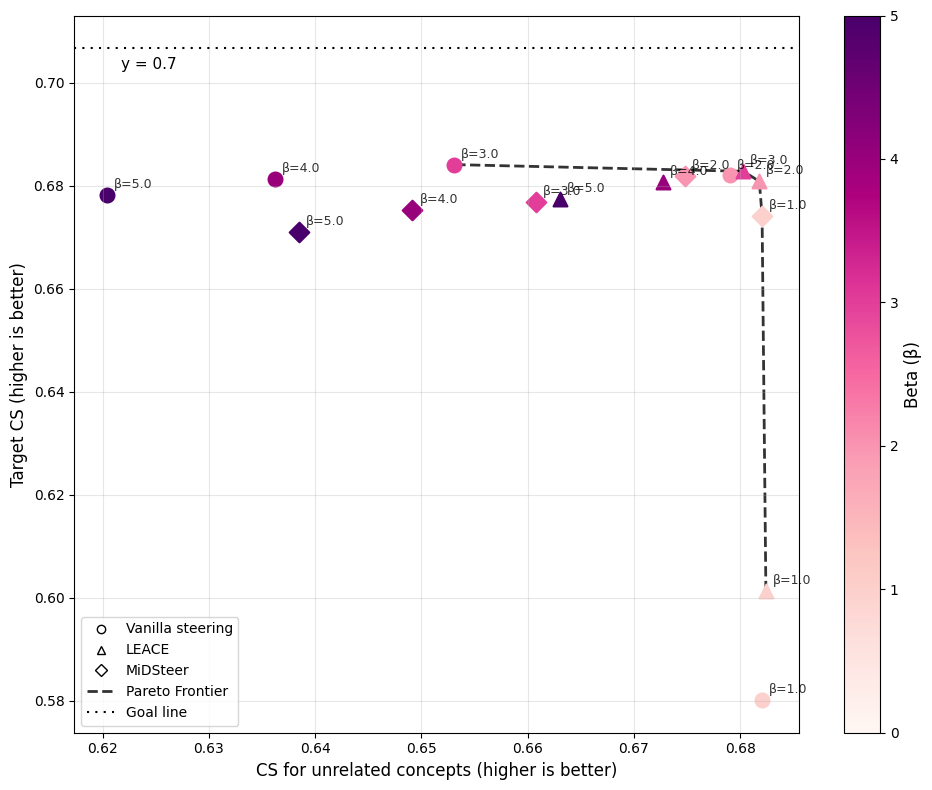

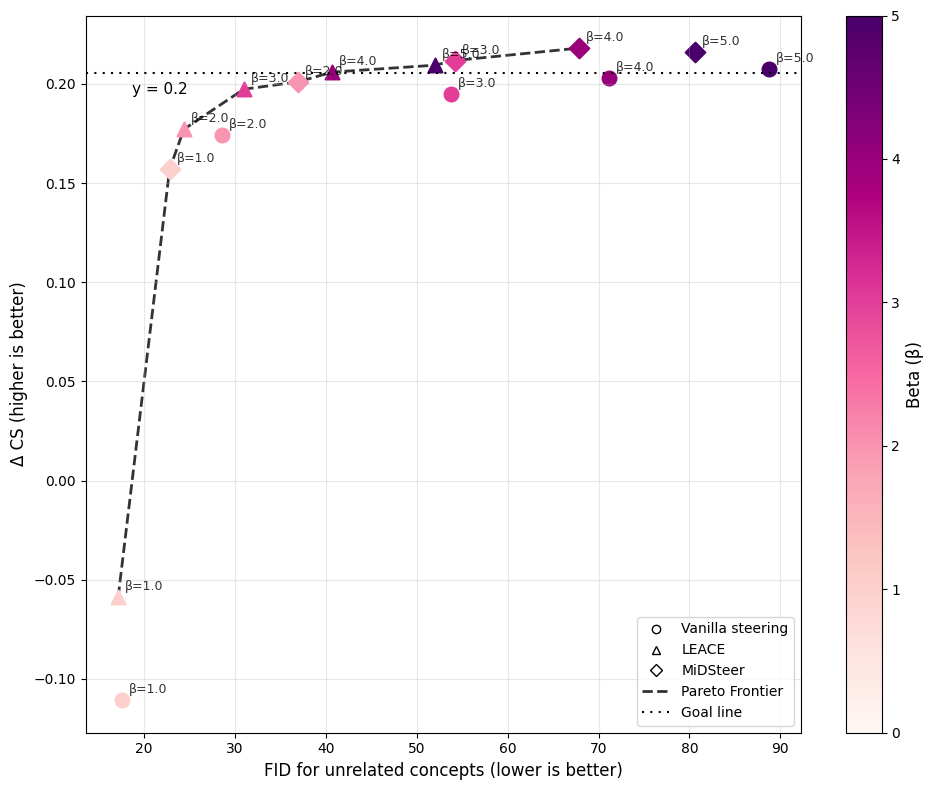

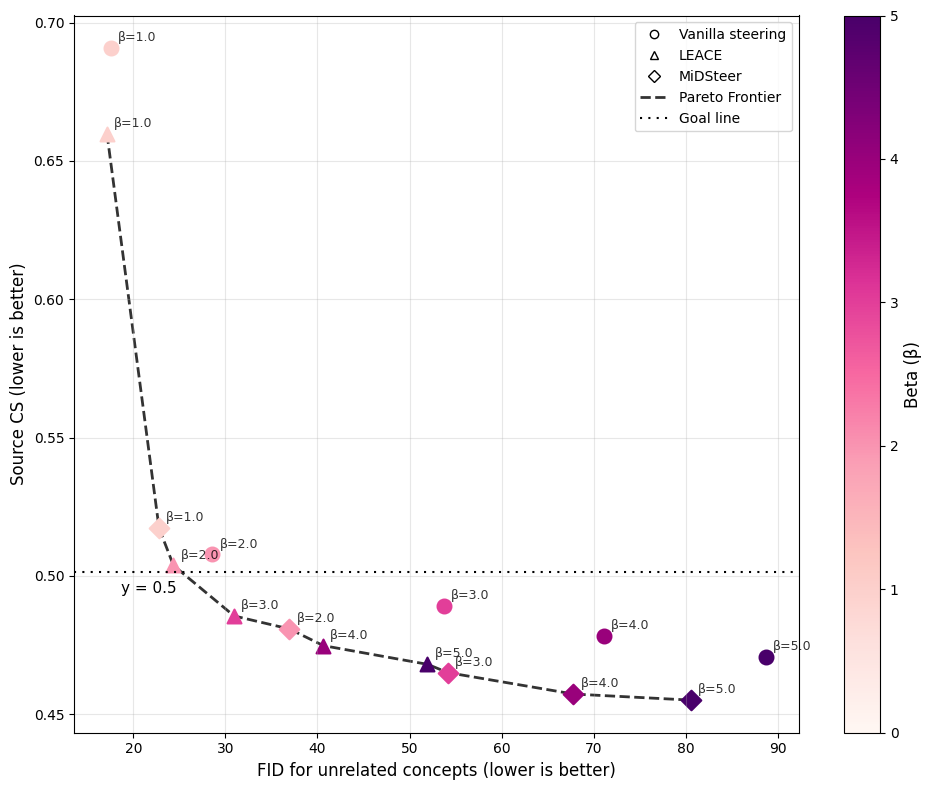

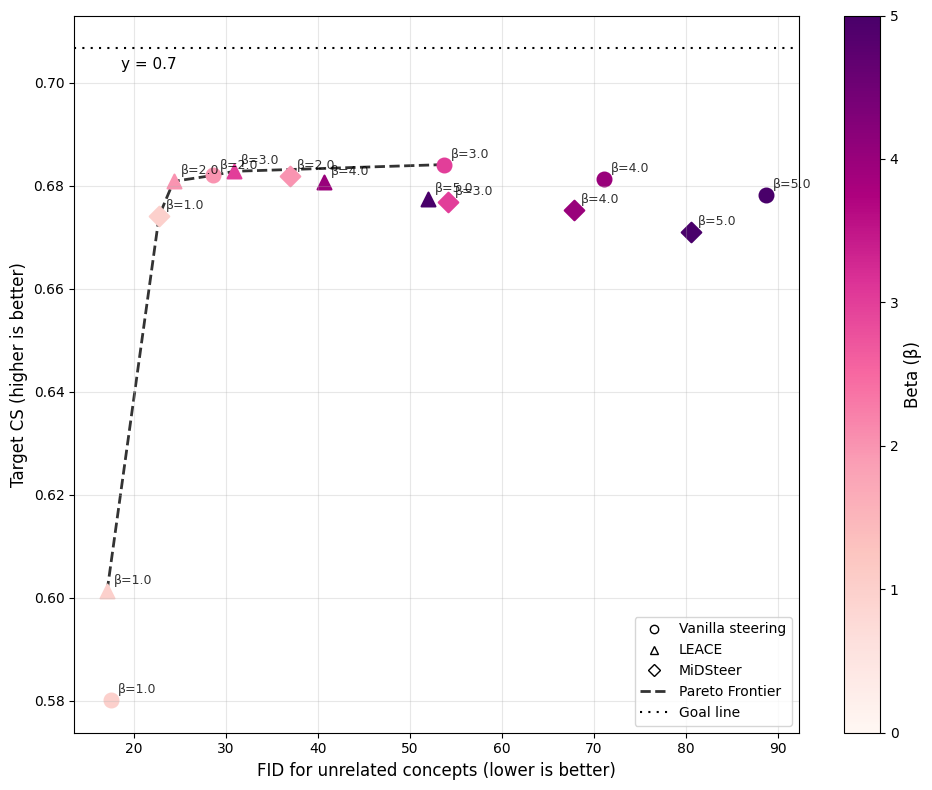

In [410]:
generate_flip_plots_with_different_axes_diffusion(
    experiment_name='../exp/results/sdxl/flipping_midsteer_diffusion_sdxl_50k_clip/evaluation/concept_translation/',
    output_filename_template='../artefacts/pareto/sdxl-flip-clip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_DIFFUSION,
    figsize=(10, 8),
)

### Sana flip

#### No clip

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

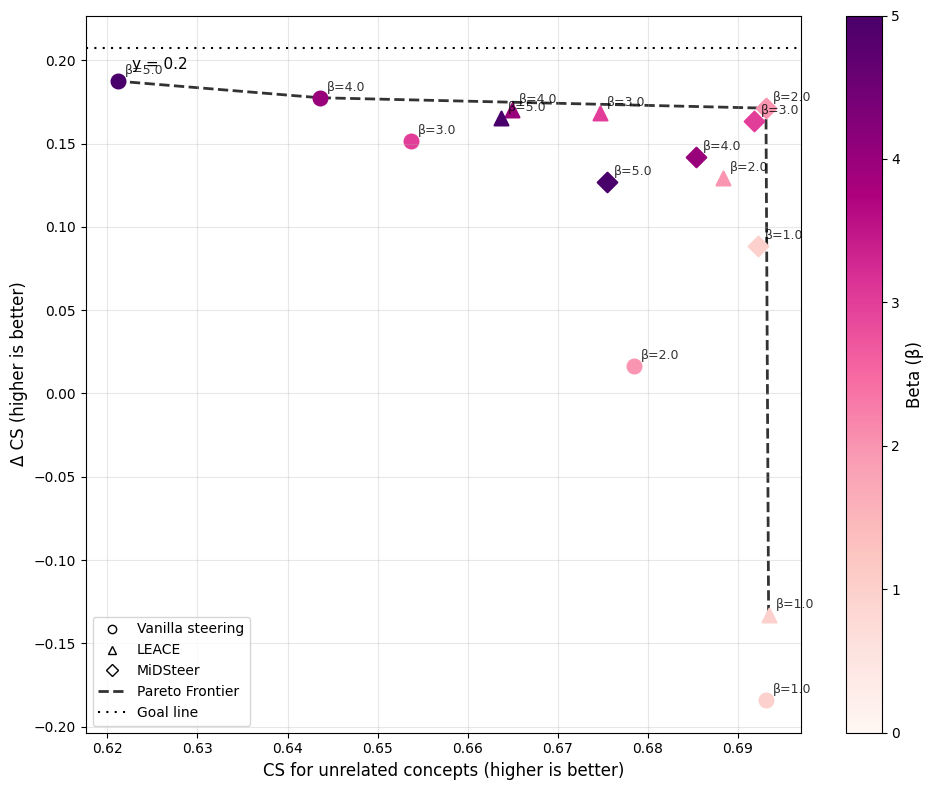

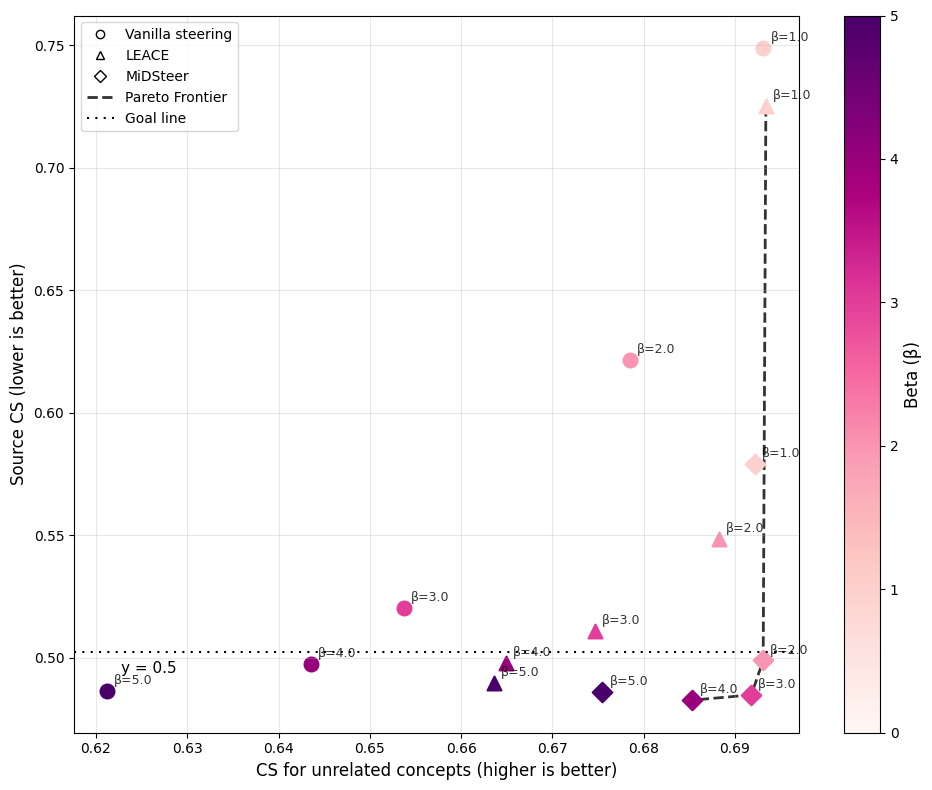

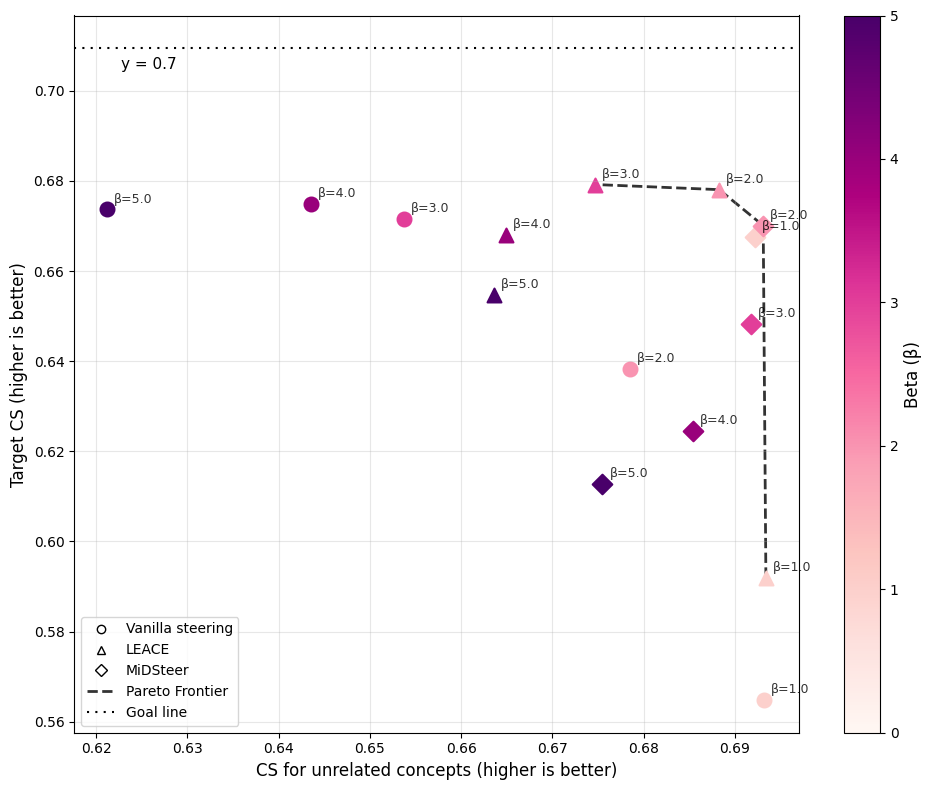

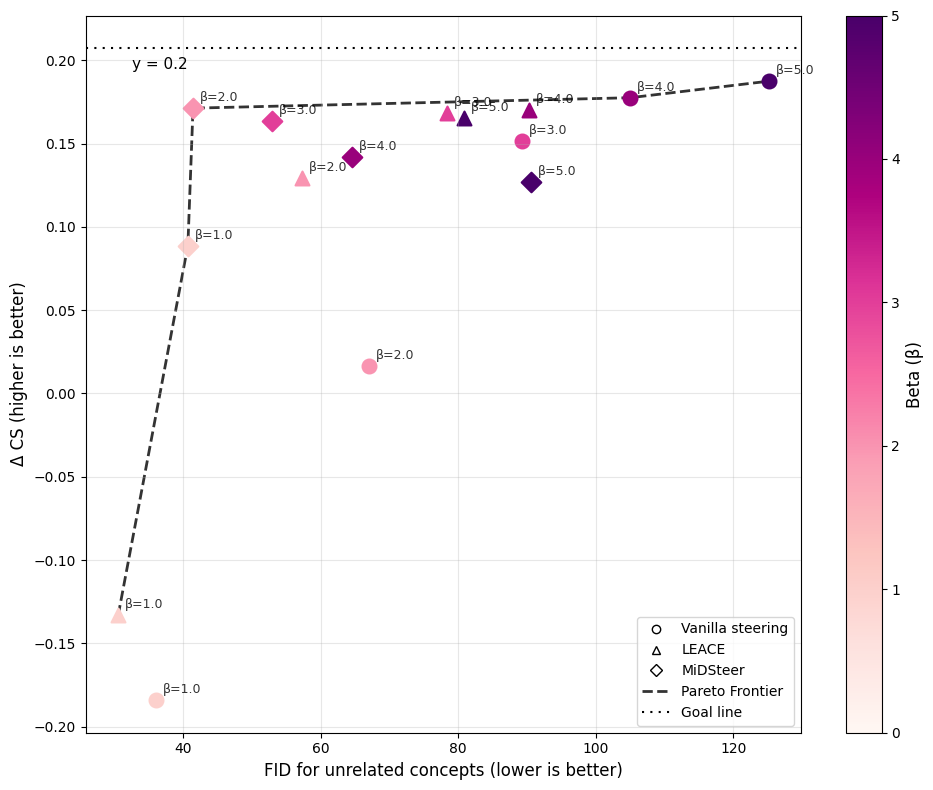

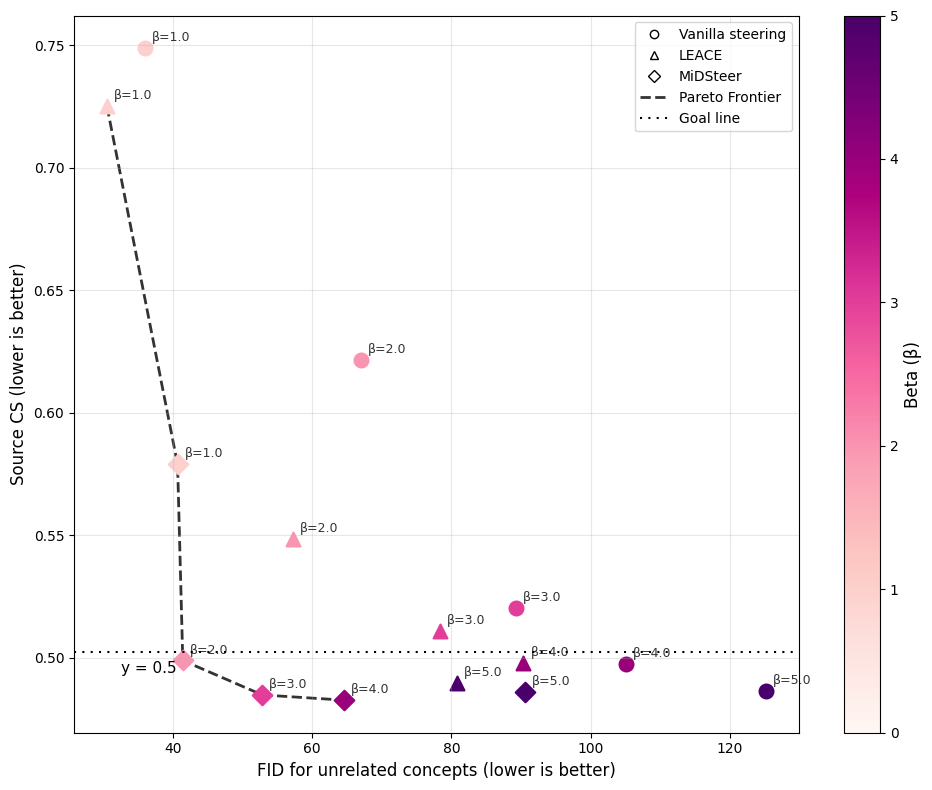

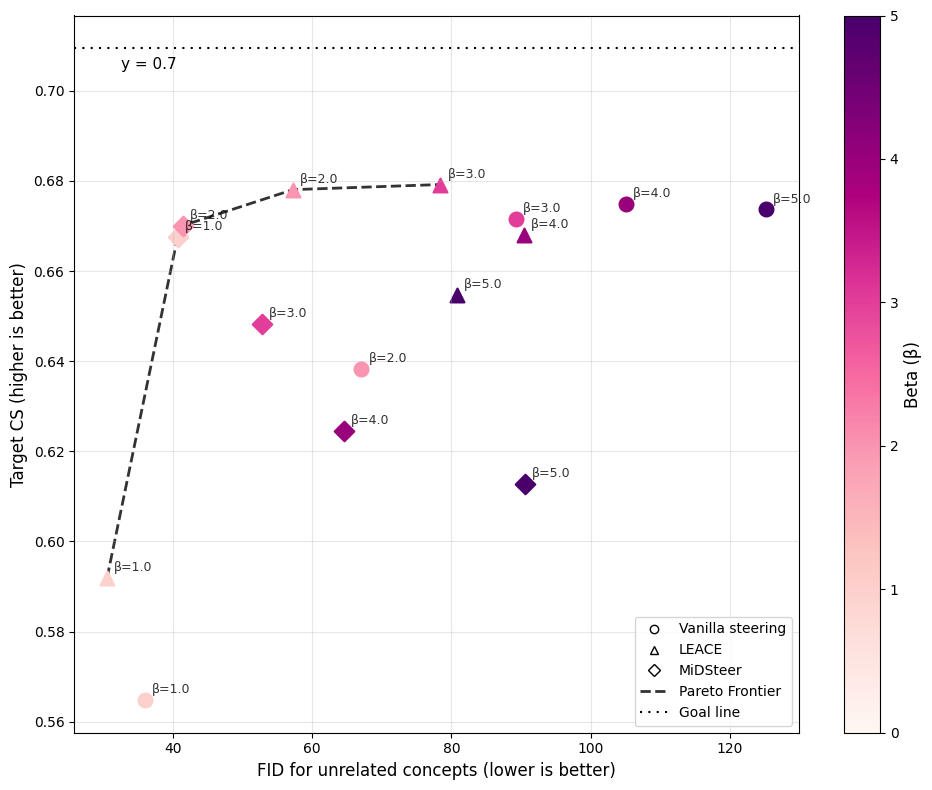

In [411]:
generate_flip_plots_with_different_axes_diffusion(
    experiment_name='../exp/results/sana/flipping_sana_50k/evaluation/concept_translation/',
    output_filename_template='../artefacts/pareto/sana-flip-noclip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_DIFFUSION,
    figsize=(10, 8),
)

#### Clip

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = (tcs - scs)[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = scs[0]
/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1363695433.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  goal = tcs[0]

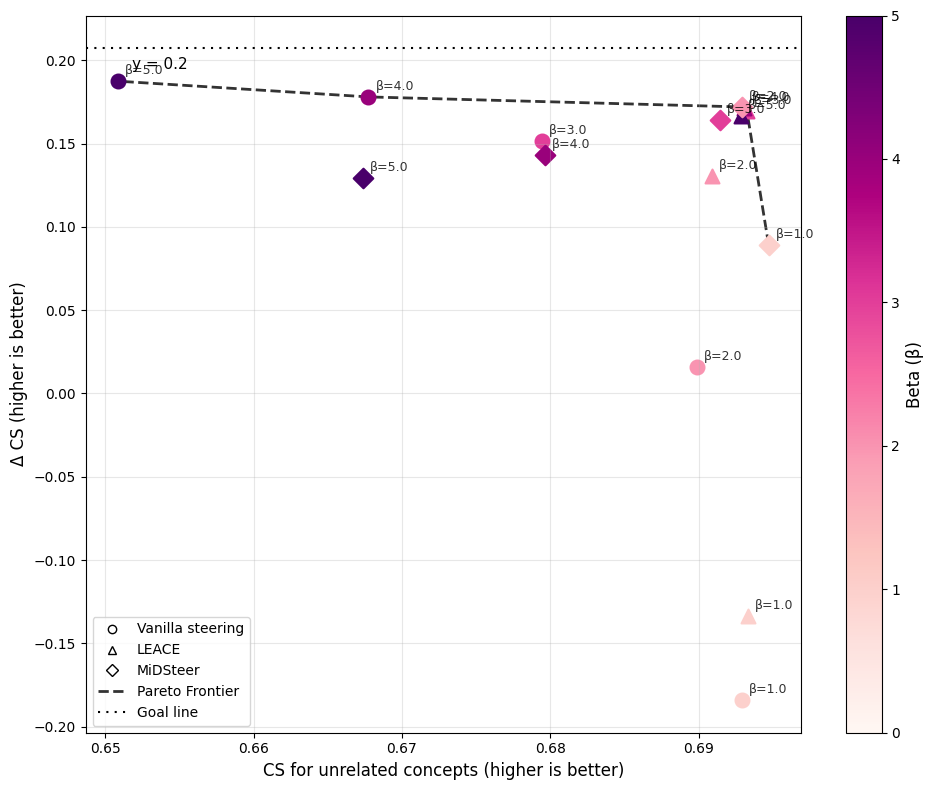

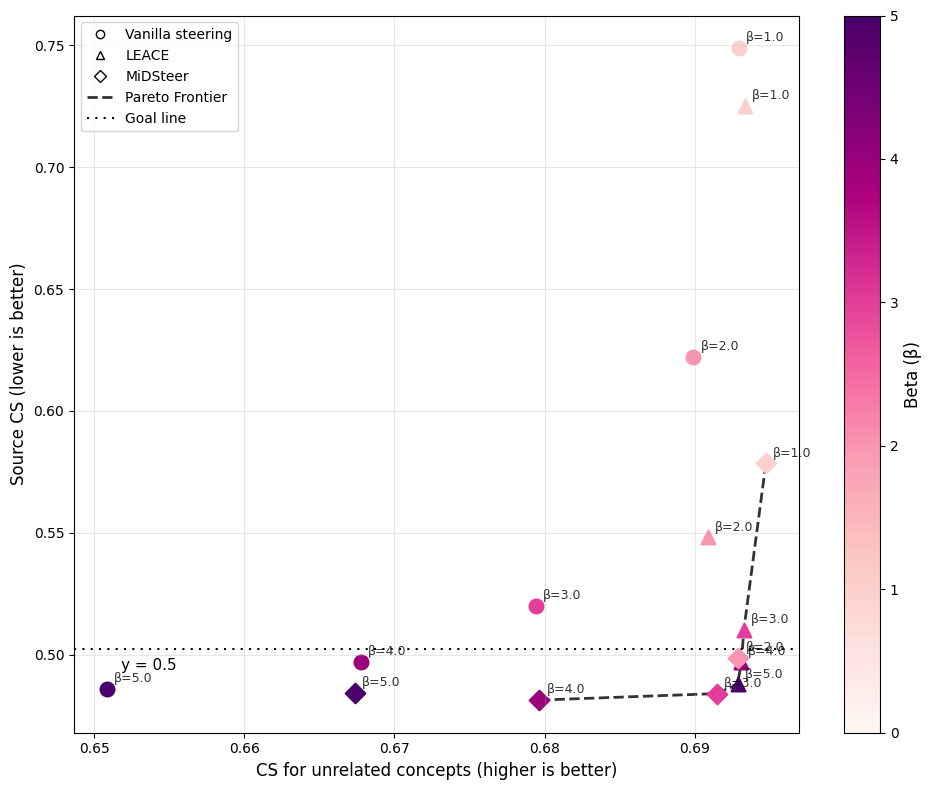

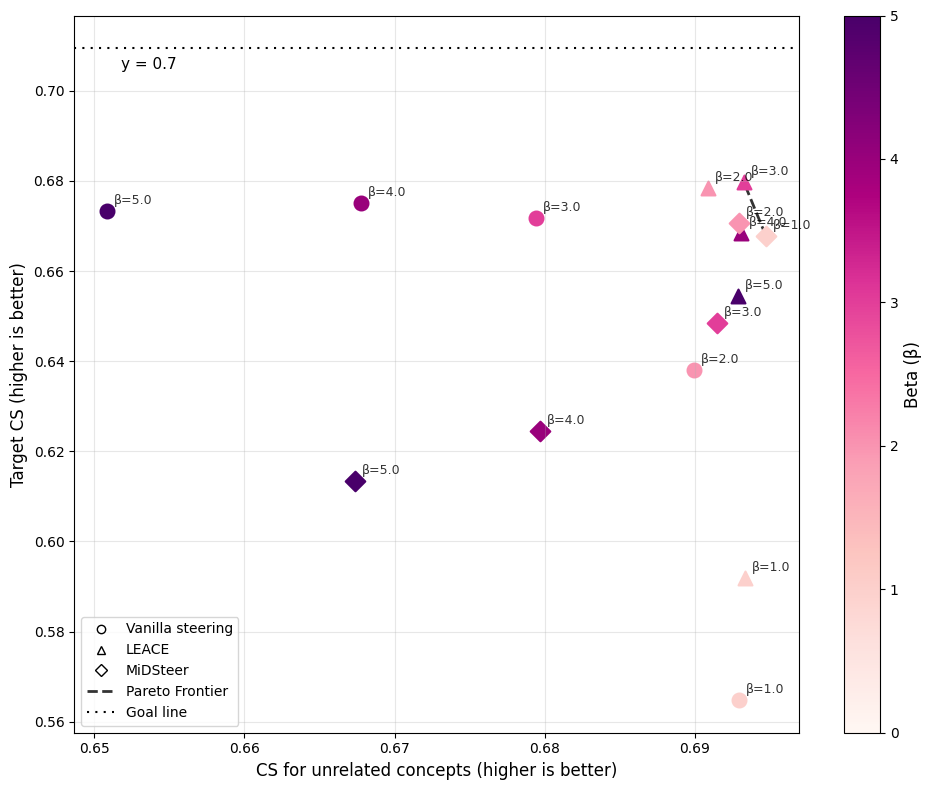

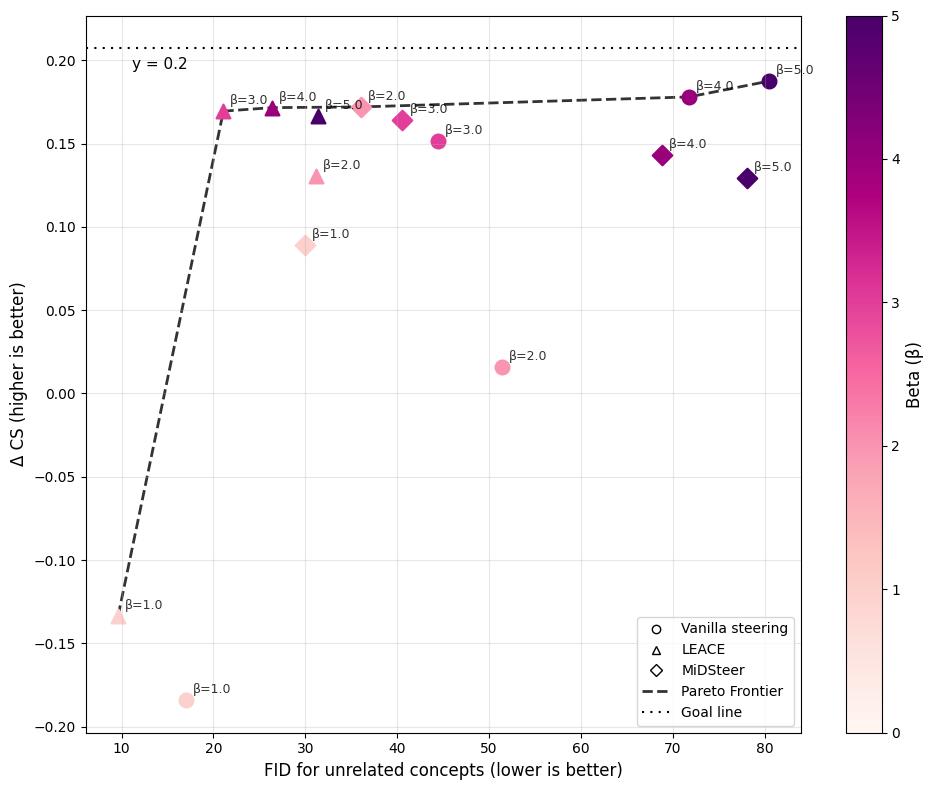

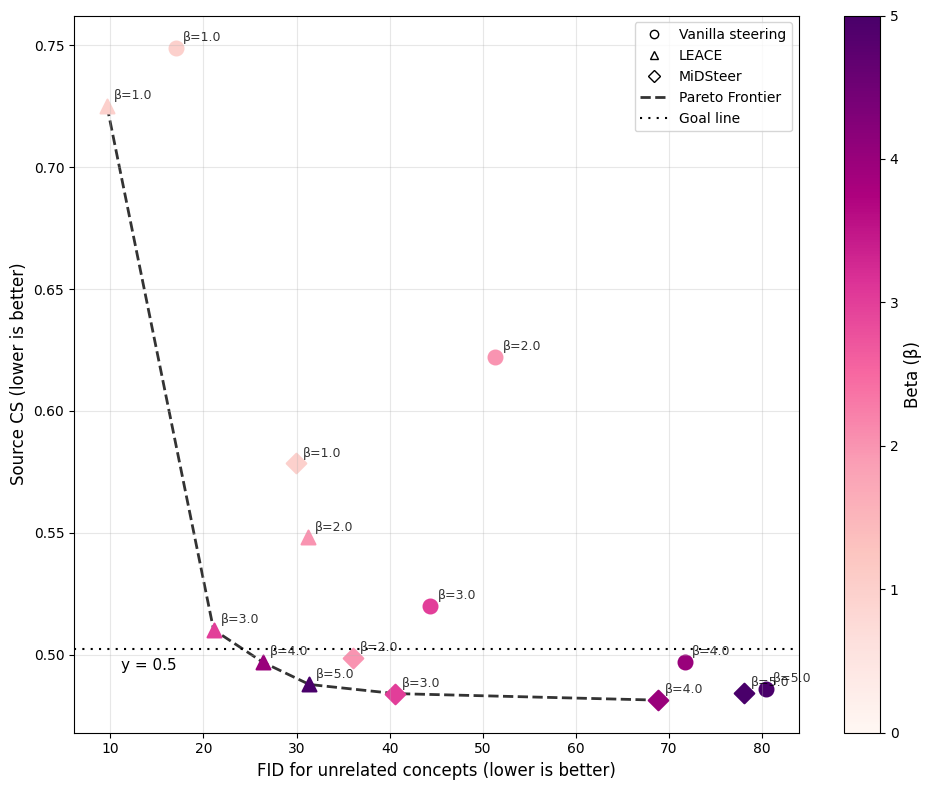

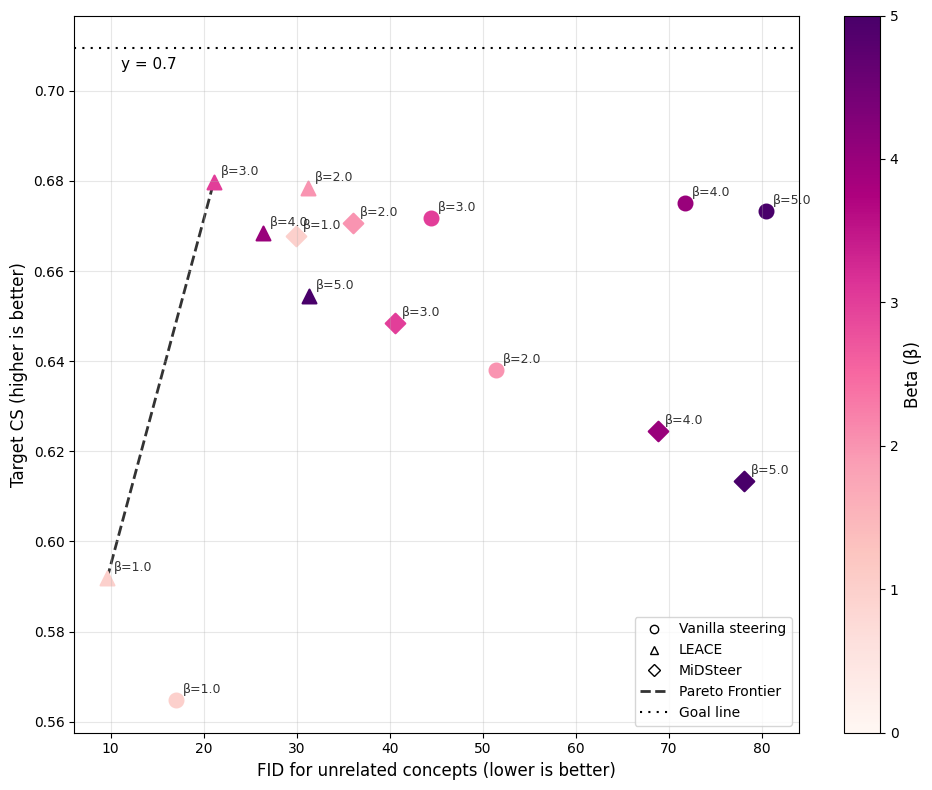

In [412]:
generate_flip_plots_with_different_axes_diffusion(
    experiment_name='../exp/results/sana/flipping_sana_50k_clip/evaluation/concept_translation/',
    output_filename_template='../artefacts/pareto/sana-flip-clip-{}.svg',
    x_axes_mapping=X_AXES_MAPPING_DIFFUSION,
    figsize=(10, 8),
)

# Num covariances ablation

In [388]:
NUM_COVARIANCES = [100, 500, 1000, 5000, 10000, 20000]

def format_num_covariances(num_covariances: int) -> str:
    if num_covariances % 1000 == 0:
        return f'{num_covariances // 1000}k'
    else:
        return f'{num_covariances}'

def load_llm_covariances_experiments(
    base_path: str,
    num_covariances_list: list[int],
):                                   
    consistency_scores = []
    concept_scores = []
    
    for num_covariances in num_covariances_list:
        consistency_score, concept_score = parse_llm_flip_experiment(
            base_path.format(format_num_covariances(num_covariances)),
        )
        consistency_score['num_covariances'] = num_covariances
        consistency_scores.append(consistency_score)
        concept_score['num_covariances'] = num_covariances
        concept_scores.append(concept_score)
    
    consistency_scores = pd.concat(consistency_scores, axis=0)
    concept_scores = pd.concat(concept_scores, axis=0)

    data = (
            (
                consistency_scores
                .query("dataset == 'mmlu'")
                .groupby(['method_name', 'strength', 'num_covariances'])
                .agg({'bert_precision': 'mean'})
                .assign(one_minus_mmlu_bert_p=lambda x: 1 - x.bert_precision)
            ).join(
                concept_scores
                .query("(concept == target_concept) & (source_concept == test_concept)")
                .groupby(['method_name', 'strength', 'num_covariances'])
                .agg({'avg_score': 'mean'})
                .rename({'avg_score': 'target_concept_score'}, axis=1)
            ).join(
                concept_scores
                .query("(concept == source_concept) & (source_concept == test_concept)")
                .groupby(['method_name', 'strength', 'num_covariances'])
                .agg({'avg_score': 'mean'})
                .rename({'avg_score': 'source_concept_score'}, axis=1)
            )
            .reset_index()
            .assign(delta_concept_score=lambda x: x.target_concept_score - x.source_concept_score)
        )
    return data


def load_diffusion_covariances_experiments(
    base_path: str,
    num_covariances_list: list[int],
):
    fids = []
    clip_scores = []

    for num_covariances in num_covariances_list:
        fid, clip_score = parse_diffusion_flip_experiment(
            base_path.format(format_num_covariances(num_covariances)),
        )
        fid['num_covariances'] = num_covariances
        fids.append(fid)
        clip_score['num_covariances'] = num_covariances
        clip_scores.append(clip_score)
    
    fids = pd.concat(fids, axis=0)
    clip_scores = pd.concat(clip_scores, axis=0)

    data = (
        (
            fids
            .query("source_concept != test_concept")
            .query("test_concept not in @IMPLICIT_CONCEPTS")
            .groupby(['method_name', 'strength', 'num_covariances'])
            .agg({'fid': 'mean'})
            .rename({'fid': 'unrelated_concept_fid'}, axis=1)
        ).join(
            clip_scores
            .query("(concept == target_concept) & (source_concept == test_concept)")
            .groupby(['method_name', 'strength', 'num_covariances'])
            .agg({'clip_score': 'mean'})
            .rename({'clip_score': 'target_clip_score'}, axis=1)
        ).join(
            clip_scores
            .query("(concept == source_concept) & (source_concept == test_concept)")
            .groupby(['method_name', 'strength', 'num_covariances'])
            .agg({'clip_score': 'mean'})
            .rename({'clip_score': 'source_clip_score'}, axis=1)
        )
        .reset_index()
        .assign(delta_clip_score=lambda x: x.target_clip_score - x.source_clip_score)
    )
    return data

def plot_phase_chart_for_num_covariances(
    data: pd.DataFrame,
    x_column: str,
    y_column: str,
    output_fname: str | None,
):
    subset = (
        data
            .query('(strength in [2.0, 2.5, 3.0]) & (method_name == "mean_matching")')
            .assign(log10_num_cov=lambda x: np.log10(x.num_covariances))
    )
    
    plt.figure(figsize=(10, 8))

    
    BASE_OFFSET = 15
    
    OFFSETS = {
        0: (-BASE_OFFSET, -BASE_OFFSET),
        1: (-BASE_OFFSET, BASE_OFFSET),
        2: (BASE_OFFSET, BASE_OFFSET),
        3: (BASE_OFFSET, -BASE_OFFSET),
    }
    
    MARKERS = {
        2.0: 'o',
        2.5: '^',
        3.0: 'D',
    }

    cmap = plt.cm.RdPu
    cnorm = matplotlib.colors.LogNorm(vmin=25, vmax=subset.num_covariances.max())
    sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=cnorm)
    sm.set_array([])
    legend_handles = {}
    
    last_x = last_y = last_strength = None
    x_min = y_min = float('inf')
    x_max = y_max = float('-inf')
    for i, row in subset.iterrows():
        marker = MARKERS[row.strength]
        color = sm.to_rgba(row.num_covariances)
        x = row[x_column]
        y = row[y_column]

        x_min = min(x, x_min)
        x_max = max(x, x_max)
        y_min = min(y, y_min)
        y_max = max(y, y_max)
    
        plt.scatter(y=y, x=x, c=color, marker=marker, label=f'β={row.strength}', s=50)
    
                    
        # Add beta value annotations
        plt.annotate(
            f'n={row.num_covariances:.0f}',
            (x, y),
            xytext=OFFSETS[i % 4],
            textcoords='offset points',
            fontsize=8,
            alpha=0.8
        )
    
        if row.strength not in legend_handles:
                legend_handles[row.strength] = mlines.Line2D(
                    xdata=[], ydata=[],
                    marker=marker,
                    linestyle='None',                    
                    markerfacecolor='white',
                    markeredgecolor='black',
                    label=f'MidSteer (β={row.strength})'
                )
    
        if last_x is not None and row.strength == last_strength:
            plt.annotate("", xytext=(last_x, last_y), xy=(x, y),
                        arrowprops=dict(arrowstyle=matplotlib.patches.ArrowStyle("->", head_length=1.0, head_width=0.5),
                                        linestyle=(0, (1, 3))))
        last_x = x
        last_y = y
        last_strength = row.strength
    
    if y_min > 0:
        plt.ylim(bottom=0, top=y_max * 1.1)
    
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('Log10 Number Covariances', fontsize=12)

    
    plt.xlabel(AXES[x_column]['label'], fontsize=12)
    plt.ylabel(AXES[y_column]['label'], fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.legend(handles=list(legend_handles.values()))
    
    plt.tight_layout()

    
    if output_fname is not None:
        os.makedirs(os.path.dirname(output_fname), exist_ok=True)
        plt.savefig(fname=output_fname)


/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1263267728.py:149: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(y=y, x=x, c=color, marker=marker, label=f'β={row.strength}', s=50)


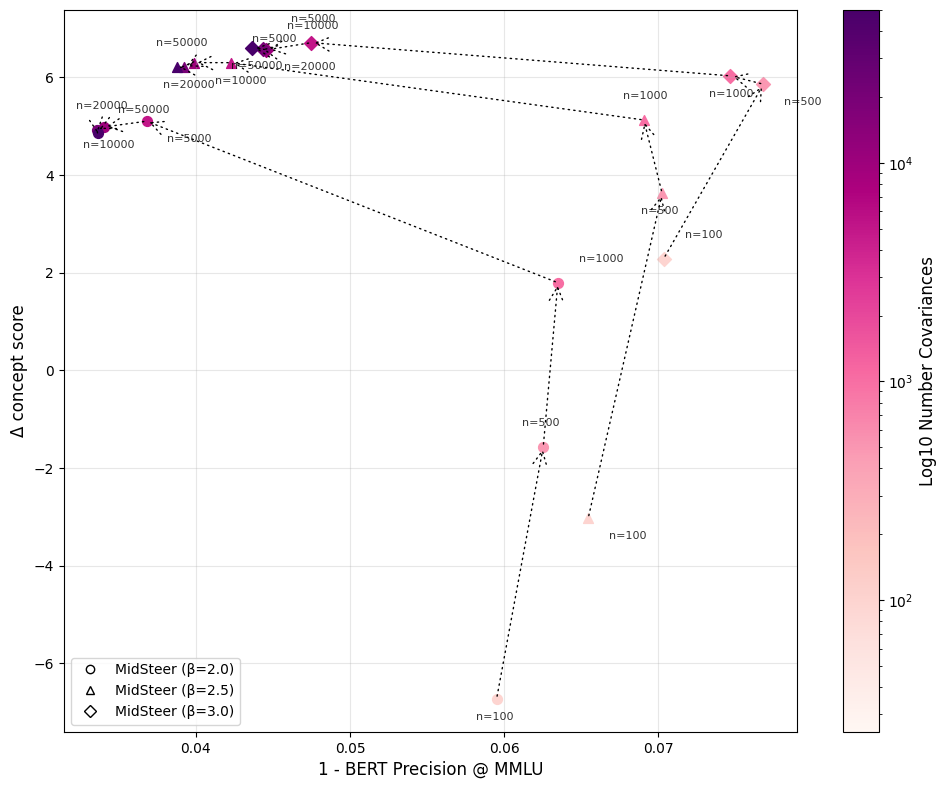

In [389]:
data = load_llm_covariances_experiments(
    base_path='../exp/results/llama-2-7b-chat-hf/midsteer_sa_fix_{}_last_no_renorm_no_clip/evaluation/',
    num_covariances_list=NUM_COVARIANCES + [50_000]
)
plot_phase_chart_for_num_covariances(
    data=data,
    x_column='one_minus_mmlu_bert_p',
    y_column='delta_concept_score',
    output_fname='../artefacts/phase/llama2_noclip.svg',
)

/var/folders/jr/3b6cqq4j0vz0bcjkrc474mn80000gn/T/ipykernel_46274/1263267728.py:149: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(y=y, x=x, c=color, marker=marker, label=f'β={row.strength}', s=50)


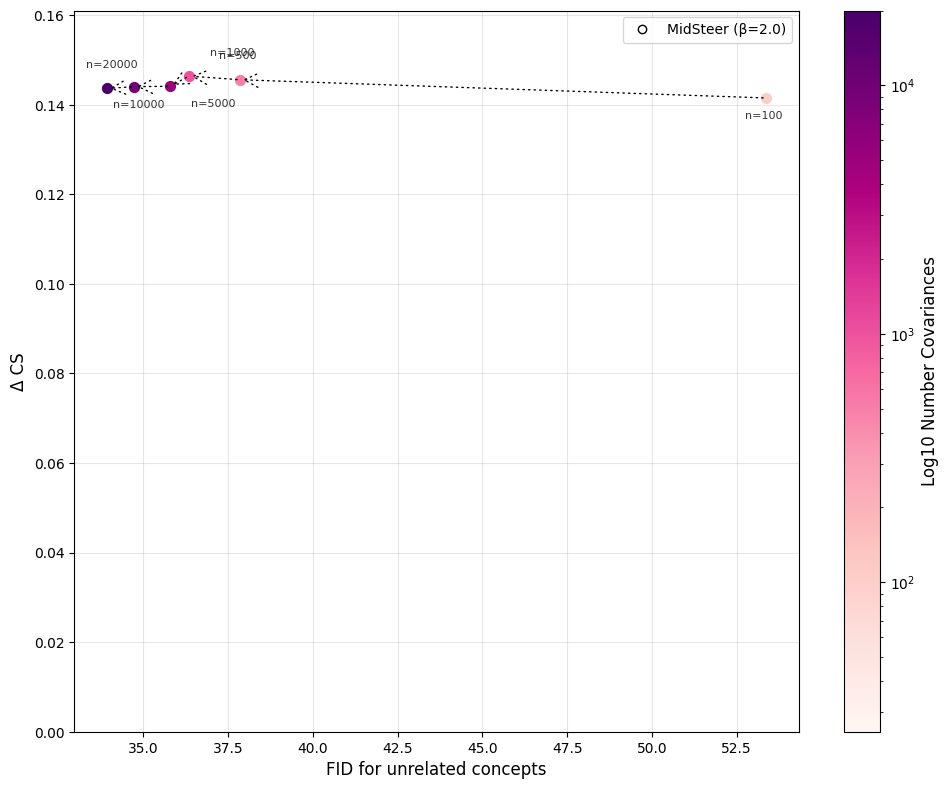

In [390]:
data = load_diffusion_covariances_experiments(
    base_path='../exp/results/sana-06/num_covs_flip_sana-600m_{}/evaluation/concept_translation',
    num_covariances_list=NUM_COVARIANCES,
)
plot_phase_chart_for_num_covariances(
    data=data,
    x_column='unrelated_concept_fid',
    y_column='delta_clip_score',
    output_fname='../artefacts/phase/sana_noclip.svg',
)

## COCO (does not work)

In [962]:
def parse_diffusion_erase_experiment_coco(path: str):
    fids = []
    clip_scores = []
    for subdir in os.listdir(path):
        if subdir == '.DS_Store':
            continue
        remove_concept, test_concept = subdir.split("_")
        if test_concept != 'coco':
            clip_score = pd.read_csv(os.path.join(path, subdir, "clip_score.tsv"), sep="\t")
            clip_score['remove_concept'] = remove_concept
            clip_score['test_concept'] = test_concept
            clip_scores.append(clip_score)
        else:
            fid = pd.read_csv(os.path.join(path, subdir, "fid.tsv"), sep="\t")
            fid['remove_concept'] = remove_concept
            fid['dataset'] = 'coco'
            fids.append(fid)
    fids = pd.concat(fids, axis=0)
    clip_scores = pd.concat(clip_scores, axis=0)

    fids['method_name'] = fids.apply(lambda x: x.method.split('-')[0], axis=1)
    fids['strength'] = fids.apply(lambda x: float(x.method.split('-')[1]), axis=1)
    fids = fids.drop(['method'], axis=1)

    
    clip_scores['method_name'] = clip_scores.apply(lambda x: x.method.split('-')[0], axis=1)
    clip_scores['strength'] = clip_scores.apply(lambda x: get_strength_or_none(x.method.split('-')), axis=1)
    clip_scores = clip_scores.drop(['method'], axis=1)

    return fids, clip_scores


In [963]:
def produce_diffusion_erase_pareto_plot_coco(
    experiment_name: str,
    output_filename: str | None = None
):
    fid, cs = parse_diffusion_erase_experiment_coco(
        experiment_name
    )
    
    data = (
        (
            fid
            .query("dataset == 'coco'")
            .groupby(['method_name', 'strength'])
            .agg({'fid': 'mean'})
            .rename({'fid': 'coco_fid'}, axis=1)
        ).join(
            cs
            .query("(concept == remove_concept) & (concept == test_concept)")
            .groupby(['method_name', 'strength'])
            .agg({'clip_score': 'mean'})
            .rename({'clip_score': 'erased_clip_score'}, axis=1)
        ).reset_index()
    )
    
    plot_pareto_frontier(
        data=data,
        x_column='coco_fid',
        y_column='erased_clip_score',
    
        x_better='lower',
        y_better='lower',
        title='',
        output_fname=output_filename,
    )

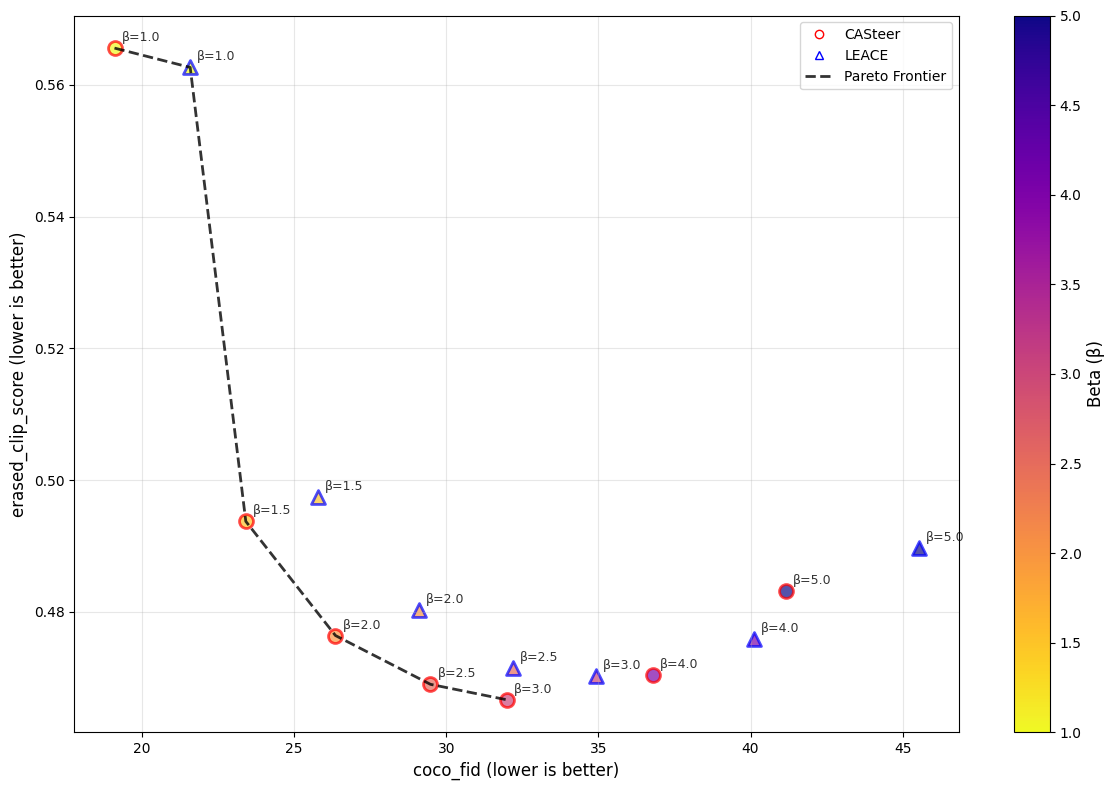

In [966]:
produce_diffusion_erase_pareto_plot_coco(
    './exp/results/sdxl/coco_erasure_sdxl_50k/evaluation/concept_erasure/'
)

# Tables

## Diffusion concept tables

In [1881]:
import typing

In [1882]:
def make_formatters_diffusion(columns):
    formatters = []
    for col in columns:
        if col[1].endswith('cs'):
            formatters.append(lambda x: "{:0.1f}".format(x * 100))
        elif col[1].endswith('fid'):
            formatters.append("{:0.1f}".format)
        else:
            raise ValueError(f'Unknown column {col}')
    return formatters

In [1883]:
def make_latex_table_erase_diffusion(
    df_cs: pd.DataFrame,
    df_fid: pd.DataFrame,
    column_order: list[str],
    output_file: typing.TextIO,
    table_caption: str | None = None,
    table_label: str | None = None,
):
    df = (
        df_cs
            .rename({'method_name': 'method'}, axis=1)
            .query("test_concept == concept")
            .pivot(index=['method', 'strength'],
                   columns='concept',
                   values='clip_score')
            .join(
                df_fid
                    .rename({'method_name': 'method'}, axis=1)
                    .pivot(index=['method', 'strength'],
                           columns='test_concept',
                           values='fid'),
                how='left',
                lsuffix='_cs',
                rsuffix='_fid',
            )
        .sort_index(axis=0, key=lambda x: x.map({'orig': 0, 'casteer': 1, 'leace': 2, 'midsteer': 3}))
        [column_order]
    )
    df.columns = pd.MultiIndex.from_tuples(list(map(lambda x: x.split('_'), column_order)))
    result = (
        df.to_latex(
            column_format="ll|c|cc|cc|cc|cc|cc",
            formatters=make_formatters_diffusion(df.columns),
            na_rep="-",
            escape=True,
            multicolumn_format='l',
            caption=table_caption,
            label=table_label,
        )
        .replace("00000", "")
        .replace(r'\begin{tabular}', r"""\centering
\setlength{\tabcolsep}{3.0pt}
\resizebox{\linewidth}{!}{
\begin{tabular}""")
        .replace(r'\end{tabular}', r'\end{tabular}}')
        .replace("orig", "No Steering")
        .replace("casteer", "CASteer")
        .replace("leace", "LEACE")
        .replace("midsteer", "MidSteer")
    )
    output_file.write(result)

In [1884]:
COLUMN_ORDERS_FOR_DIFFUSION_REMOVAL = {
    'chihuahua': ['chihuahua_cs', 'muffin_cs', 'muffin_fid',
                  'dog_cs', 'dog_fid', 'wolf_cs', 'wolf_fid',
                  'cat_cs', 'cat_fid', 'legislator_cs', 'legislator_fid'
    ],
    'snoopy': ['snoopy_cs', 'mickey_cs', 'mickey_fid',
               'pikachu_cs', 'pikachu_fid', 'spongebob_cs', 'spongebob_fid',
               'dog_cs', 'dog_fid', 'legislator_cs', 'legislator_fid'
            
    ],
    'horse': ['horse_cs', 'motorcycle_cs', 'motorcycle_fid',
              'cow_cs', 'cow_fid', 'pig_cs', 'pig_fid',
              'dog_cs', 'dog_fid', 'legislator_cs', 'legislator_fid'
    ],
}

In [1885]:
DIFFUSION_EXPERIMENTS_ERASURE_GRID = [
    ('sdxl', 'noclip', './exp/results/sdxl/erasure_midsteer_diffusion_sdxl_50k/evaluation/concept_erasure/'),
    ('sdxl', 'clip', './exp/results/sdxl/erasure_midsteer_diffusion_sdxl_50k_clip/evaluation/concept_erasure/'),
    ('sana', 'noclip', './exp/results/sana/erasure_sana_50k/evaluation/concept_erasure/'),
    ('sana', 'clip', './exp/results/sana/erasure_sana_50k_clip/evaluation/concept_erasure/'),
]

In [1886]:
with (
        open('./artefacts/tables/diffusion_erase_tables_noclip.tex', 'w') as fout_noclip,
        open('./artefacts/tables/diffusion_erase_tables_clip.tex', 'w') as fout_clip
    ):
    for model_name, clip, experiment_name in DIFFUSION_EXPERIMENTS_ERASURE_GRID:
        fid, cs = parse_diffusion_erase_experiment(
            experiment_name
        )
    
        for remove_concept in cs.remove_concept.unique():
            if remove_concept == 'mickey': # This was only used to test implicit concepts
                continue
            df_cs = cs[cs.remove_concept == remove_concept]
            df_fid = fid[fid.remove_concept == remove_concept]
    
            make_latex_table_erase_diffusion(
                df_cs,
                df_fid,
                column_order=COLUMN_ORDERS_FOR_DIFFUSION_REMOVAL[remove_concept],
                table_caption=f'Model {model_name} ({clip}), removal of {remove_concept}',
                table_label=f'tab:erase_{model_name}_{clip}_{remove_concept}',
                output_file=fout_clip if clip == 'clip' else fout_noclip
            )

In [1887]:
def make_latex_table_flip_diffusion(
    df_cs: pd.DataFrame,
    df_fid: pd.DataFrame,
    column_order: list[str],
    output_file: typing.TextIO,
    table_caption: str | None = None,
    table_label: str | None = None,
):
    df = (
        df_cs
        .rename({'method_name': 'method'}, axis=1)
        .query("concept == source_concept")
        .pivot(index=['method', 'strength'],
               columns='test_concept',
               values='clip_score')
        .join(
            df_cs
                .rename({'method_name': 'method'}, axis=1)
                .query("concept == target_concept")
                .pivot(index=['method', 'strength'],
                       columns='test_concept',
                       values='clip_score'),
            lsuffix='_src-cs',
            rsuffix='_tgt-cs',
        )
        .join(
            df_cs
                .rename({'method_name': 'method'}, axis=1)
                .query("concept == test_concept")
                .pivot(index=['method', 'strength'],
                       columns='test_concept',
                       values='clip_score'),
        )
        .join(
            df_fid
                .rename({'method_name': 'method'}, axis=1)
                .pivot(index=['method', 'strength'],
                       columns='test_concept',
                       values='fid'),
            how='left',
            lsuffix='_cs',
            rsuffix='_fid',
        )
        .sort_index(axis=0, key=lambda x: x.map({'orig': 0, 'casteer': 1, 'leace': 2, 'midsteer': 3}))
        [column_order]
        .replace({
            'orig': 'No Steering',
            'casteer': 'CASteer',
            'leace': 'LEACE',
            'midsteer': 'MidSteer',
        })
    )
    
    df.columns = pd.MultiIndex.from_tuples(list(map(lambda x: x.split('_'), column_order)))
    
    result = (
            df.to_latex(
                column_format="ll|cc|ccc|cccc|cccc|cccc|cccc",
                formatters=make_formatters_diffusion(df.columns),
                na_rep="-",
                escape=True,
                multicolumn_format='l',
                caption=table_caption,
                label=table_label,
            )
            .replace("00000", "")
            .replace(r'\begin{tabular}', r"""\centering
    \setlength{\tabcolsep}{3.0pt}
    \resizebox{\linewidth}{!}{
    \begin{tabular}""")
            .replace(r'\end{tabular}', r'\end{tabular}}')
            .replace("orig", "No Steering")
            .replace("casteer", "CASteer")
            .replace("leace", "LEACE")
            .replace("midsteer", "MidSteer")
        )
    output_file.write(result)

In [1888]:
DIFFUSION_EXPERIMENTS_FLIPPING_GRID = [
    ('sdxl', 'noclip', './exp/results/sdxl/flipping_midsteer_diffusion_sdxl_50k/evaluation/concept_translation/'),
    ('sdxl', 'clip', './exp/results/sdxl/flipping_midsteer_diffusion_sdxl_50k_clip/evaluation/concept_translation/'),
    ('sana', 'noclip', './exp/results/sana/flipping_sana_50k/evaluation/concept_translation/'),
    ('sana', 'clip', './exp/results/sana/flipping_sana_50k_clip/evaluation/concept_translation/'),
]

In [1889]:
COLUMN_ORDERS_FOR_DIFFUSION_FLIP = {
    'horse': [
        'horse_src-cs', 'horse_tgt-cs',
        'motorcycle_src-cs', 'motorcycle_tgt-cs', 'motorcycle_fid',
        'cow_cs', 'cow_src-cs', 'cow_tgt-cs', 'cow_fid',
        'pig_cs', 'pig_src-cs', 'pig_tgt-cs', 'pig_fid',
        'dog_cs', 'dog_src-cs', 'dog_tgt-cs', 'dog_fid',
        'legislator_cs', 'legislator_src-cs', 'legislator_tgt-cs', 'legislator_fid',
    ],
    'chihuahua': [
        'chihuahua_src-cs', 'chihuahua_tgt-cs',
        'muffin_src-cs', 'muffin_tgt-cs', 'muffin_fid',
        'dog_cs', 'dog_src-cs', 'dog_tgt-cs', 'dog_fid',
        'wolf_cs', 'wolf_src-cs', 'wolf_tgt-cs', 'wolf_fid',
        'cat_cs', 'cat_src-cs', 'cat_tgt-cs', 'cat_fid',
        'legislator_cs', 'legislator_src-cs', 'legislator_tgt-cs', 'legislator_fid',
    ],
    'snoopy': [
        'snoopy_src-cs', 'snoopy_tgt-cs',
        'mickey_src-cs', 'mickey_tgt-cs', 'mickey_fid',
        'pikachu_cs', 'pikachu_src-cs', 'pikachu_tgt-cs', 'pikachu_fid',
        'spongebob_cs', 'spongebob_src-cs', 'spongebob_tgt-cs', 'spongebob_fid',
        'dog_cs', 'dog_src-cs', 'dog_tgt-cs', 'dog_fid',
        'legislator_cs', 'legislator_src-cs', 'legislator_tgt-cs', 'legislator_fid'
    ],

}

In [1890]:
with (
        open('./artefacts/tables/diffusion_flip_tables_clip.tex', 'w') as fout_clip,
        open('./artefacts/tables/diffusion_flip_tables_noclip.tex', 'w') as fout_noclip,
):
    for model_name, clip, experiment_name in DIFFUSION_EXPERIMENTS_FLIPPING_GRID:
        fid, cs = parse_diffusion_flip_experiment(experiment_name)
        for source_concept, target_concept in cs[['source_concept', 'target_concept']].drop_duplicates().values:
            if source_concept == "mickey":  # This was only used to test implicit concepts
                continue
            df_cs = cs[(cs.source_concept == source_concept) & (cs.target_concept == target_concept)]
            df_fid = fid[(fid.source_concept == source_concept) & (fid.target_concept == target_concept)]
        
            make_latex_table_flip_diffusion(
                df_cs,
                df_fid,
                column_order=COLUMN_ORDERS_FOR_DIFFUSION_FLIP[source_concept],
                output_file=fout_clip if clip == 'clip' else fout_noclip,
                table_caption=f'Model {model_name} ({clip}), flipping from {source_concept} to {target_concept}',
                table_label=f'tab:flip_{model_name}_{clip}_{source_concept}_to_{target_concept}',
            )

## LLM concept tables

In [1891]:
def make_formatters_llm(columns):
    formatters = []
    for col in columns:
        if col[1].endswith('cs'):
            formatters.append("{:0.1f}".format)
        elif col[1].endswith('bertp'):
            formatters.append("{:0.2f}".format)
        else:
            raise ValueError(f'Unknown column {col}')
    return formatters

In [1892]:
def make_latex_table_erase_llm(
    df_cs: pd.DataFrame,
    df_consistency: pd.DataFrame,
    column_order: list[str],
    output_file: typing.TextIO,
    table_caption: str | None = None,
    table_label: str | None = None,
):
    df = (
        df_cs
            .rename({'method_name': 'method'}, axis=1)
            .query("test_concept == concept")
            .pivot(index=['method', 'strength'],
                   columns='test_concept',
                   values='avg_score')
            .join(
                df_consistency
                    .rename({'method_name': 'method'}, axis=1)
                    .pivot(index=['method', 'strength'],
                           columns='test_concept',
                           values='bert_precision'),
                how='left',
                lsuffix='_cs',
                rsuffix='_bertp',
            )
        .sort_index(axis=0, key=lambda x: x.map({'orig': 0, 'casteer': 1, 'leace': 2, 'midsteer': 3}))
        [column_order]
        .query("method != 'midsteer'")
        .replace({
            'orig': 'No Steering',
            'casteer': 'CASteer',
            'leace': 'LEACE',
            'midsteer': 'MidSteer',
        })
    )
    df.columns = pd.MultiIndex.from_tuples(list(map(lambda x: x.split('_'), column_order)))
    result = (
        df.to_latex(
            column_format="ll|c|cc|cc|cc|cc|cc",
            formatters=make_formatters_llm(df.columns),
            na_rep="-",
            escape=True,
            multicolumn_format='l',
            caption=table_caption,
            label=table_label,
        )
        .replace("00000", "")
        .replace(r'\begin{tabular}', r"""\centering
\setlength{\tabcolsep}{3.0pt}
\resizebox{\linewidth}{!}{
\begin{tabular}""")
        .replace(r'\end{tabular}', r'\end{tabular}}')
        .replace("orig", "No Steering")
        .replace("casteer", "CASteer")
        .replace("leace", "LEACE")
        .replace("midsteer", "MidSteer")
    )
    output_file.write(result)

In [1893]:
LLM_EXPERIMENTS_ERASURE_GRID = [
    ('llama2-7b', 'noclip', './exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_erasure_llama2/evaluation/'),
    ('llama2-7b', 'clip', './exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_erasure_llama2_clip/evaluation/'),
    ('qwen2.5-7b', 'noclip', './exp/results/Qwen-Qwen2.5-7B-Instruct/erasure_qwen_7b_50k/evaluation/'),
    ('qwen2.5-7b', 'clip', './exp/results/Qwen-Qwen2.5-7B-Instruct/erasure_qwen_7b_50k_clip/evaluation/'),
    ('qwen2.5-14b', 'noclip', './exp/results/Qwen-Qwen2.5-14B-Instruct/erasure_qwen_14b_50k/evaluation/'),
]

In [1894]:
COLUMN_ORDERS_FOR_LLM_REMOVAL = {
    'dogs': ['dogs_cs', 'cats_cs', 'cats_bertp',
             'wolves_cs', 'wolves_bertp', 'cows_cs', 'cows_bertp',
             'pigs_cs', 'pigs_bertp', 'legislators_cs', 'legislators_bertp'
    ],
    'horses': ['horses_cs', 'motorcycles_cs', 'motorcycles_bertp',
               'cows_cs', 'cows_bertp', 'pigs_cs', 'pigs_bertp',
               'dogs_cs', 'dogs_bertp', 'legislators_cs', 'legislators_bertp'
    ],
}

In [1895]:
with (
    open('./artefacts/tables/llm_erase_tables_clip.tex', 'w') as fout_clip,
    open('./artefacts/tables/llm_erase_tables_noclip.tex', 'w') as fout_noclip,

):
    for model_name, clip, experiment_name in LLM_EXPERIMENTS_ERASURE_GRID:
        consistency_score, cs = parse_llm_erase_experiment(
            experiment_name
        )
        print(model_name, clip, experiment_name)
        for remove_concept in cs.remove_concept.unique():
            df_cs = cs[cs.remove_concept == remove_concept]
            df_consistency_score = consistency_score[consistency_score.remove_concept == remove_concept].query("dataset == 'eval'")

            print(remove_concept)
            make_latex_table_erase_llm(
                df_cs,
                df_consistency_score,
                column_order=COLUMN_ORDERS_FOR_LLM_REMOVAL[remove_concept],
                table_caption=f'Model {model_name} ({clip}), removal of {remove_concept}',
                table_label=f'tab:erase_{model_name}_{clip}_{remove_concept}',
                output_file=fout_clip if clip == 'clip' else fout_noclip,
            )

llama2-7b noclip ./exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_erasure_llama2/evaluation/
horses
dogs
llama2-7b clip ./exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_erasure_llama2_clip/evaluation/
horses
dogs
qwen2.5-7b noclip ./exp/results/Qwen-Qwen2.5-7B-Instruct/erasure_qwen_7b_50k/evaluation/
horses
dogs
qwen2.5-7b clip ./exp/results/Qwen-Qwen2.5-7B-Instruct/erasure_qwen_7b_50k_clip/evaluation/
horses
dogs
qwen2.5-14b noclip ./exp/results/Qwen-Qwen2.5-14B-Instruct/erasure_qwen_14b_50k/evaluation/
horses
dogs


In [1896]:
def make_latex_table_flip_llm(
    df_cs: pd.DataFrame,
    df_consistency_score: pd.DataFrame,
    column_order: list[str],
    output_file: typing.TextIO,
    table_caption: str | None = None,
    table_label: str | None = None,
):
    df = (
        df_cs
        .rename({'method_name': 'method'}, axis=1)
        .query("concept == source_concept")
        .pivot(index=['method', 'strength'],
               columns='test_concept',
               values='avg_score')
        .join(
            df_cs
                .rename({'method_name': 'method'}, axis=1)
                .query("concept == target_concept")
                .pivot(index=['method', 'strength'],
                       columns='test_concept',
                       values='avg_score'),
            lsuffix='_src-cs',
            rsuffix='_tgt-cs',
        )
        .join(
            df_cs
                .rename({'method_name': 'method'}, axis=1)
                .query("concept == test_concept")
                .pivot(index=['method', 'strength'],
                       columns='test_concept',
                       values='avg_score'),
        )
        .join(
            df_consistency_score
                .rename({'method_name': 'method'}, axis=1)
                .pivot(index=['method', 'strength'],
                       columns='test_concept',
                       values='bert_precision'),
            how='left',
            lsuffix='_cs',
            rsuffix='_bertp',
        )
        .sort_index(axis=0, key=lambda x: x.map({'orig': 0, 'casteer': 1, 'leace': 2, 'midsteer': 3}))
        [column_order]
        .replace({
            'orig': 'No Steering',
            'casteer': 'CASteer',
            'leace': 'LEACE',
            'midsteer': 'MidSteer',
        })
    )
    
    df.columns = pd.MultiIndex.from_tuples(list(map(lambda x: x.split('_'), column_order)))
    
    result = (
            df.to_latex(
                column_format="ll|cc|ccc|cccc|cccc|cccc|cccc",
                formatters=make_formatters_llm(df.columns),
                na_rep="-",
                escape=True,
                multicolumn_format='l',
                caption=table_caption,
                label=table_label,
            )
            .replace("00000", "")
            .replace(r'\begin{tabular}', r"""\centering
    \setlength{\tabcolsep}{3.0pt}
    \resizebox{\linewidth}{!}{
    \begin{tabular}""")
            .replace(r'\end{tabular}', r'\end{tabular}}')
            .replace("orig", "No Steering")
            .replace("casteer", "CASteer")
            .replace("leace", "LEACE")
            .replace("midsteer", "MidSteer")
        )
    output_file.write(result)

In [1897]:
LLM_EXPERIMENTS_FLIP_GRID = [
    ('llama2-7b', 'noclip', './exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_sa_fix_50k_last_no_renorm_no_clip_all_strengths/evaluation/'),
    ('llama2-7b', 'clip', './exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_sa_fix_50k_last_no_renorm_clip_all_strengths/evaluation/'),
    ('qwen2.5-7b', 'noclip', './exp/results/Qwen-Qwen2.5-7B-Instruct/llm_flipping_midsteer_qwen_50k/evaluation/'),
    ('qwen2.5-7b', 'clip', './exp/results/Qwen-Qwen2.5-7B-Instruct/llm_flipping_midsteer_qwen_50k_clip/evaluation/'),
    ('qwen2.5-14b', 'noclip', './exp/results/Qwen-Qwen2.5-14B-Instruct/llm_flipping_midsteer_qwen_14b_50k/evaluation/'),
]

In [1898]:
COLUMN_ORDERS_FOR_LLM_FLIP = {
    'horses': [
        'horses_src-cs', 'horses_tgt-cs',
        'motorcycles_src-cs', 'motorcycles_tgt-cs', 'motorcycles_bertp',
        'cows_cs', 'cows_src-cs', 'cows_tgt-cs', 'cows_bertp',
        'pigs_cs', 'pigs_src-cs', 'pigs_tgt-cs', 'pigs_bertp',
        'dogs_cs', 'dogs_src-cs', 'dogs_tgt-cs', 'dogs_bertp',
        'legislators_cs', 'legislators_src-cs', 'legislators_tgt-cs', 'legislators_bertp',
    ],
    'dogs': [
        'dogs_src-cs', 'dogs_tgt-cs',
        'cats_src-cs', 'cats_tgt-cs', 'cats_bertp',
        'wolves_cs', 'wolves_src-cs', 'wolves_tgt-cs', 'wolves_bertp',
        'pigs_cs', 'pigs_src-cs', 'pigs_tgt-cs', 'pigs_bertp',
        'cows_cs', 'cows_src-cs', 'cows_tgt-cs', 'cows_bertp',
        'legislators_cs', 'legislators_src-cs', 'legislators_tgt-cs', 'legislators_bertp',
    ],

}

In [1899]:
with (
        open('./artefacts/tables/llm_flip_tables_clip.tex', 'w') as fout_clip,
        open('./artefacts/tables/llm_flip_tables_noclip.tex', 'w') as fout_noclip,
):
    for model_name, clip, experiment_name in LLM_EXPERIMENTS_FLIP_GRID:
        consistency_score, cs = parse_llm_flip_experiment(
            experiment_name
        )
        cs = (
            cs
            .groupby(by=['source_concept', 'target_concept', 'test_concept', 'concept', 'method_name', 'strength'])
            .agg({'avg_score': 'mean'})
            .reset_index()
        )
        print(model_name, clip, experiment_name)
        for source_concept, target_concept in cs[['source_concept', 'target_concept']].drop_duplicates().values:
            df_cs = cs[(cs.source_concept == source_concept) & (cs.target_concept == target_concept)]
            df_consistency_score = consistency_score[(consistency_score.source_concept == source_concept) & (consistency_score.target_concept == target_concept)].query("dataset == 'eval'")
        
            make_latex_table_flip_llm(
                df_cs,
                df_consistency_score,
                column_order=COLUMN_ORDERS_FOR_LLM_FLIP[source_concept],
                output_file=fout_clip if clip == 'clip' else fout_noclip,
                table_caption=f'Model {model_name} ({clip}), flipping from {source_concept} to {target_concept}',
                table_label=f'tab:flip_{model_name}_{clip}_{source_concept}_to_{target_concept}',
            )

llama2-7b noclip ./exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_sa_fix_50k_last_no_renorm_no_clip_all_strengths/evaluation/
llama2-7b clip ./exp/results/meta-llama-Llama-2-7b-chat-hf/midsteer_sa_fix_50k_last_no_renorm_clip_all_strengths/evaluation/
qwen2.5-7b noclip ./exp/results/Qwen-Qwen2.5-7B-Instruct/llm_flipping_midsteer_qwen_50k/evaluation/
qwen2.5-7b clip ./exp/results/Qwen-Qwen2.5-7B-Instruct/llm_flipping_midsteer_qwen_50k_clip/evaluation/
qwen2.5-14b noclip ./exp/results/Qwen-Qwen2.5-14B-Instruct/llm_flipping_midsteer_qwen_14b_50k/evaluation/


# LaTeX to include charts

In [1843]:
import collections
import io

In [1844]:
model_type = {
    'llama2-7b': 'llm',
    'qwen-14b': 'llm',
    'qwen-7b': 'llm',
    'sana': 'diffusion',
    'sdxl': 'diffusion',
}

In [1845]:
contents = collections.defaultdict(lambda: io.StringIO())
for file in sorted(os.listdir("artefacts/pareto/")):
    if file == ".ipynb_checkpoints":
        continue

    parts = collections.deque(file[:-4].split("-"))
    if parts[0] in ('llama2', 'qwen'):
        model_name = '-'.join([parts[0], parts[1]])
        parts.popleft()
        parts.popleft()
    else:
        model_name = parts[0]
        parts.popleft()

    setting = parts[0]
    parts.popleft()

    if parts[0] in ('clip', 'noclip'):
        clip = parts[0]
        parts.popleft()
    else:
        clip = 'noclip'
    
    metric_name = "-".join(list(parts))
    print(model_name, setting, clip)

    contents[(model_type[model_name], setting, clip)].write(f"""
\\begin{{figure}}[htbp]
\\centering
\\includesvg[width=\\linewidth]{{artefacts/pareto/{file}}}
\\caption{{Pareto plot for concept {setting} on model {model_name} ({clip})}}
\\label{{fig:{file}}}
\\vspace{{-0.5cm}}
\\end{{figure}}

""")
    

llama2-7b erasure clip
llama2-7b erasure clip
llama2-7b erasure clip
llama2-7b erasure noclip
llama2-7b erasure noclip
llama2-7b erasure noclip
llama2-7b flip clip
llama2-7b flip clip
llama2-7b flip clip
llama2-7b flip noclip
llama2-7b flip noclip
llama2-7b flip noclip
qwen-14b erasure noclip
qwen-14b erasure noclip
qwen-14b erasure noclip
qwen-14b flip noclip
qwen-14b flip noclip
qwen-14b flip noclip
qwen-7b erasure clip
qwen-7b erasure clip
qwen-7b erasure clip
qwen-7b erasure noclip
qwen-7b erasure noclip
qwen-7b erasure noclip
qwen-7b flip clip
qwen-7b flip clip
qwen-7b flip clip
qwen-7b flip noclip
qwen-7b flip noclip
qwen-7b flip noclip
sana erase clip
sana erase clip
sana erase noclip
sana erase noclip
sana flip clip
sana flip clip
sana flip noclip
sana flip noclip
sdxl erase clip
sdxl erase clip
sdxl erase noclip
sdxl erase noclip
sdxl flip clip
sdxl flip clip
sdxl flip noclip
sdxl flip noclip


In [1846]:
for (model_type, setting, clip), string_io in contents.items():
    with open(f"artefacts/pareto_includes/{model_type}_{setting}_{clip}.tex", "w") as fout:
        fout.write(string_io.getvalue())